# Region-Decoupled Distillation of a Transformer Teacher for CPU-Deployable Multiple Sclerosis Lesion Segmentation

Reference implementation. This notebook is generated from `src/msdistill` by
`scripts/build_notebook.py` — edit the package, not the notebook.

## What this runs

A four-class segmentation problem on MS3SEG (background, ventricles, incidental
"normal" white-matter hyperintensity, pathological "abnormal" WMH), and a
controlled study of what a small convolutional network can inherit from a
transformer teacher.

| Stage | What happens |
|---|---|
| 0 | Fine-tune one teacher **per cross-validation fold** on that fold's training patients |
| 1 | Co-train every student ablation variant against its fold-matched frozen teacher |
| 2 | Evaluate all models on the held-out patients under one identical ensemble protocol |
| 3 | Paired significance tests, efficiency profiling, LaTeX tables and figures |

## Three corrections that changed the conclusions

Earlier runs of this study produced results that contradicted its own premise.
The causes were mechanical, and each is fixed here.

**The teacher was the weaker model.** Stock SegFormer emits logits at stride 4 and
upsamples ×4 to reach input resolution. At 256×256 an MS lesion is often 2–6
pixels across, so that prediction cannot represent one. Measured: SegFormer-B0
reached 0.36 Dice on normal WMH where the 487K-parameter student reached 0.57.
Distilling from it was distilling downward. The teacher here uses a **MiT-B2
encoder with a full-resolution refinement decoder**, which restores stride-1
output and makes the compression ratio (≈56× parameters) meaningful.

**The reported metric awarded free points.** Dice was accumulated per mini-batch
and averaged. With `smooth=1e-5`, a batch containing none of a class scores
`(0+ε)/(0+ε) = 1.0` — a perfect score for predicting nothing. Since abnormal WMH
is absent from most slices, the rare-class numbers were inflated and the ranking
of methods was wrong. Metrics here are computed **once per patient over the whole
volume**, with absent classes recorded as undefined rather than perfect.

**The feature loss had a trivial optimum.** `MSE(W_s·f_s, W_t·f_t)` with *both*
projections learnable is minimized by `W_s = W_t = 0`. The loss went to zero, the
student's bottleneck collapsed, and two folds diverged. Only the student side is
projected here, features keep their spatial layout, and they are L2-normalized so
the objective constrains direction rather than magnitude.

A fourth issue was procedural: cached fold results from a previous configuration
were silently reused, which is why two different objectives once reported
byte-identical validation scores. Every results file now carries a configuration
fingerprint and a mismatch triggers retraining.

## The ablation ladder

| Variant | Objective | Question it answers |
|---|---|---|
| `scratch` | hard labels only | What can this architecture do alone? |
| `kd_vanilla` | + uniform per-pixel KL | Does textbook distillation help here? |
| `kd_fitnets` | + pooled-feature MSE | Does matching globally averaged features help? |
| `kd_cwd` | + channel-wise distillation | Does prior dense-prediction KD help? |
| `kd_region` | + lesion-region-weighted KL | Does decoupling foreground from background help? |
| `kd_region_cwd` | + channel-wise | Is the channel-wise term additive? |
| `kd_full` | + spatial feature alignment | Full proposed objective |

Every row trains the **same architecture from the same initialization on the same
batches in the same order**; only the objective differs. Differences between rows
therefore cannot be attributed to data ordering or initialization, and the
per-patient scores are properly paired for significance testing.


## 1. Environment

`transformers` supplies the pretrained Mix Transformer encoder; `nibabel` reads
NIfTI volumes; `scipy` provides the connected-component and distance-transform
routines behind the lesion-wise and boundary metrics.


In [1]:
import importlib, subprocess, sys

def ensure(package: str, import_name: str = None) -> None:
    """Install only what is missing, so a warm environment starts instantly."""
    try:
        importlib.import_module(import_name or package.split("==")[0].replace("-", "_"))
    except ImportError:
        print(f"installing {package} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

for pkg, mod in [("nibabel", "nibabel"), ("transformers", "transformers"),
                 ("scipy", "scipy"), ("tqdm", "tqdm"), ("scikit-learn", "sklearn")]:
    ensure(pkg, mod)

import os, json, math, time, copy, random, hashlib, warnings, re, platform, statistics
from collections import defaultdict
from dataclasses import dataclass, asdict, field
from typing import Callable, Dict, List, Optional, Sequence, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
import matplotlib
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)
print("torch", torch.__version__, "| CUDA", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch 2.10.0+cu128 | CUDA True
GPU: Tesla T4


---

# Part I — Library

The cells below are the contents of `src/msdistill`, inlined in dependency order.
They define everything; nothing is executed against data until Part II.


### `config.py` — Configuration and the ablation grid

In [2]:
"""Experiment configuration for the MS lesion segmentation distillation study.

Every hyperparameter the paper reports lives here so that a single object fully
determines a run. `Config.fingerprint()` hashes the fields that affect training,
and the training loop refuses to reuse cached fold results whose fingerprint does
not match -- this is what prevents the stale-resume contamination that silently
mixed results across experiment variants in the previous pipeline.
"""

from __future__ import annotations

import hashlib
import json
import os
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Tuple


# Fields deliberately excluded from the fingerprint: they change where output goes
# or how fast it runs, but not what is computed.
_NON_SEMANTIC_FIELDS = frozenset({
    "data_root", "output_dir", "num_workers", "use_amp", "max_hours_per_fold",
    "progress", "benchmark_trials", "benchmark_warmup", "pin_memory",
    "resume_every_epochs", "parallel_folds",
})


@dataclass
class Config:
    # ------------------------------------------------------------------ paths
    data_root: str = "/kaggle/input/ms3seg-mri-tri-mask-lesion-segmentation"
    output_dir: str = "/kaggle/working/msdistill_out"

    # ----------------------------------------------------------- label scheme
    class_names: Tuple[str, ...] = ("background", "ventricles", "normal_wmh", "abnormal_wmh")
    num_classes: int = 4
    # Classes that carry clinical meaning; background is excluded from summary metrics.
    foreground_classes: Tuple[int, ...] = (1, 2, 3)
    # The class whose segmentation the paper treats as the primary endpoint.
    primary_class: int = 3  # abnormal (pathological) WMH
    # Classes for which lesion-wise detection metrics are computed.
    lesion_classes: Tuple[int, ...] = (2, 3)

    modalities: Tuple[str, ...] = ("T1", "T2", "FLAIR")

    # --------------------------------------------------------- preprocessing
    target_size: Tuple[int, int] = (256, 256)
    clip_percentiles: Tuple[float, float] = (0.5, 99.5)
    # Slices whose foreground (non-air) fraction falls below this are dropped from
    # training only. Evaluation always uses every slice of every test volume.
    min_brain_fraction: float = 0.01
    # Training slices containing any lesion voxel are sampled this many times more
    # often than lesion-free slices. 1.0 disables oversampling.
    lesion_oversample_factor: float = 3.0

    # ------------------------------------------------------------- partitions
    test_fraction: float = 0.20
    n_folds: int = 3
    seed: int = 42
    # Extra seeds for the seed-variance study. The student is cheap enough that
    # repeating it is affordable; the teacher is trained once per fold only.
    student_seeds: Tuple[int, ...] = (42, 1337, 2024)

    # --------------------------------------------------------------- training
    batch_size: int = 8
    num_epochs: int = 60
    early_stop_patience: int = 12
    num_workers: int = 2
    pin_memory: bool = True
    use_amp: bool = True
    grad_clip_norm: float = 5.0
    # Wall-clock guard per fold, independent of the epoch budget. On a Kaggle T4
    # a teacher fold runs roughly 1.5-2.5 h and a co-trained student fold roughly
    # 2-3 h, so 3.0 lets a healthy fold finish while still capping a stuck one.
    # Hitting the guard saves a snapshot and marks the fold incomplete, so
    # rerunning resumes rather than silently reporting a truncated run.
    max_hours_per_fold: float = 3.0
    progress: bool = True
    # Snapshot the whole co-trained student stage every N epochs so a killed
    # session loses at most N epochs rather than a whole fold. The snapshot holds
    # every variant's weights, optimizer moments and best-so-far state, so it is
    # large; writing it every epoch costs more in I/O than it saves.
    # 0 disables mid-fold snapshots.
    resume_every_epochs: int = 5

    # Run this many cross-validation folds concurrently, one per GPU. Folds are
    # completely independent -- no parameter or gradient crosses them -- so this
    # is near-linear scaling with zero inter-GPU communication.
    #
    # This is deliberately NOT nn.DataParallel, which re-broadcasts the entire
    # model to every device on every step. For a 27.5M teacher on PCIe-connected
    # T4s with no NVLink that is ~110 MB of traffic per step against ~120 ms of
    # compute, and it measured *slower* than a single GPU in an earlier version
    # of this pipeline.
    #
    # 1 disables it. "auto" is not offered on purpose: silently changing how a
    # long run executes based on what hardware happened to be allocated makes
    # results hard to reproduce. Excluded from the fingerprint -- it changes
    # scheduling, not arithmetic, so cached folds stay valid either way.
    parallel_folds: int = 1

    # Student optimizer (trained from random initialization).
    student_lr: float = 3e-3
    student_weight_decay: float = 1e-4
    student_warmup_epochs: int = 3

    # Teacher optimizer (fine-tuning pretrained weights).
    teacher_lr: float = 6e-5
    teacher_head_lr: float = 6e-4
    teacher_weight_decay: float = 1e-2
    teacher_warmup_epochs: int = 2
    teacher_epochs: int = 45
    teacher_early_stop_patience: int = 12

    # ------------------------------------------------------------ hard labels
    ce_weight: float = 0.5
    dice_weight: float = 0.5
    # Inverse-square-root-frequency weights, normalized so ventricles sit at 1.0.
    # The cohort's voxel shares are background 99.55%, ventricles 0.30%,
    # abnormal WMH 0.10%, normal WMH 0.05%, giving 1/sqrt(f) ratios of
    # 0.06 : 1.00 : 2.44 : 1.73 in (background, ventricles, normal, abnormal)
    # order. Plain inverse frequency would put a weight of ~2000 on normal WMH
    # and make training diverge; the square root is the usual compromise.
    class_ce_weights: Tuple[float, ...] = (0.05, 1.0, 2.4, 1.7)

    # ---------------------------------------------------------- architectures
    # Teacher encoder: "b0" | "b1" | "b2". b2 is the reported configuration;
    # b0/b1 exist as documented fallbacks for tighter GPU budgets.
    teacher_variant: str = "b2"
    # Adds the full-resolution refinement decoder that lifts SegFormer's native
    # stride-4 output back to stride 1. Without it the teacher cannot resolve
    # thin periventricular lesions and is *worse* than the tiny student.
    teacher_hr_decoder: bool = True
    teacher_hr_channels: int = 64

    student_base_channels: int = 8

    # ----------------------------------------------------- distillation terms
    kd_temperature: float = 3.0
    # Weight on the hard-label term; distillation terms are added on top with
    # their own weights rather than sharing (1 - alpha), so each ablation row
    # changes exactly one thing.
    kd_alpha_hard: float = 1.0
    kd_logit_weight: float = 3.0
    kd_cwd_weight: float = 3.0
    kd_cwd_temperature: float = 4.0
    kd_feature_weight: float = 1.0
    # Region-decoupled logit distillation: how much the foreground region (any
    # non-background voxel in the ground truth, dilated by `kd_region_dilation`)
    # is upweighted relative to background in the per-pixel KL.
    kd_fg_weight: float = 5.0
    kd_bg_weight: float = 1.0
    kd_region_dilation: int = 2
    # Linear ramp of every distillation term from 0 to full weight over this many
    # epochs, so an under-trained student is not dragged around by teacher noise
    # before it has learned anything.
    kd_warmup_epochs: int = 5

    # ------------------------------------------------------------- evaluation
    # Which held-out-test aggregation the tables report as headline numbers.
    # "volume" = Dice recomputed per patient over the whole 3-D volume, then
    # averaged across patients (the protocol Metrics Reloaded recommends).
    report_aggregation: str = "volume"
    # Overlap needed for a predicted connected component to count as detecting a
    # reference lesion, for lesion-wise F1.
    lesion_match_iou: float = 0.10
    # Connected components smaller than this many voxels are ignored in the
    # lesion-wise analysis (annotation noise floor).
    min_lesion_voxels: int = 3
    bootstrap_samples: int = 10000
    alpha_level: float = 0.05

    # ---------------------------------------------------------- benchmarking
    benchmark_warmup: int = 10
    benchmark_trials: int = 50
    benchmark_batch_sizes: Tuple[int, ...] = (1, 8)
    benchmark_cpu: bool = True

    # ------------------------------------------------------------------------
    def __post_init__(self) -> None:
        if self.teacher_variant not in {"b0", "b1", "b2"}:
            raise ValueError(f"teacher_variant must be b0/b1/b2, got {self.teacher_variant!r}")
        if len(self.class_ce_weights) != self.num_classes:
            raise ValueError("class_ce_weights must have one entry per class")
        if self.report_aggregation not in {"volume", "global"}:
            raise ValueError("report_aggregation must be 'volume' or 'global'")

    # ------------------------------------------------------------- directories
    @property
    def checkpoint_dir(self) -> str:
        return os.path.join(self.output_dir, "checkpoints")

    @property
    def results_dir(self) -> str:
        return os.path.join(self.output_dir, "results")

    @property
    def figures_dir(self) -> str:
        return os.path.join(self.output_dir, "figures")

    @property
    def tables_dir(self) -> str:
        return os.path.join(self.output_dir, "tables")

    def make_dirs(self) -> "Config":
        for d in (self.checkpoint_dir, self.results_dir, self.figures_dir, self.tables_dir):
            os.makedirs(d, exist_ok=True)
        return self

    # ------------------------------------------------------------ fingerprint
    def semantic_dict(self) -> Dict:
        return {k: v for k, v in asdict(self).items() if k not in _NON_SEMANTIC_FIELDS}

    def fingerprint(self) -> str:
        blob = json.dumps(self.semantic_dict(), sort_keys=True, default=str)
        return hashlib.sha256(blob.encode("utf-8")).hexdigest()[:12]

    def to_json(self, path: str) -> None:
        with open(path, "w", encoding="utf-8") as f:
            json.dump({"config": asdict(self), "fingerprint": self.fingerprint()},
                      f, indent=2, default=str)

    def describe(self) -> str:
        return json.dumps(asdict(self), indent=2, default=str)


# ---------------------------------------------------------------------------
# The ablation grid.
#
# Every row trains the *same* student architecture from the *same* random
# initialization on the *same* batches; only `terms` differs. That is what makes
# the ladder an ablation rather than a collection of unrelated runs.
# ---------------------------------------------------------------------------

@dataclass(frozen=True)
class Variant:
    key: str
    label: str
    # Subset of {"logit", "region", "cwd", "feat", "fitnets"}. "logit" is the
    # plain Hinton per-pixel KL; "region" replaces it with the region-decoupled
    # version; they are mutually exclusive.
    terms: Tuple[str, ...]
    needs_teacher: bool
    # Short description used in the generated LaTeX table and the README.
    note: str = ""
    # Compact objective description printed in the results table.
    objective: str = ""
    # Citation key for rows that reproduce a published distillation objective.
    # Printing these in the table is what distinguishes "we compared against
    # three published methods" from "we ablated our own loss".
    citation: str = ""
    # Overrides Config.student_base_channels. Used only by the capacity baseline.
    base_channels: Optional[int] = None

    def __post_init__(self) -> None:
        if "logit" in self.terms and "region" in self.terms:
            raise ValueError(f"{self.key}: 'logit' and 'region' are mutually exclusive")


ABLATION_VARIANTS: Tuple[Variant, ...] = (
    Variant("unet32", "U-Net (base 32)", (), False,
            "Conventionally sized U-Net trained under the identical protocol. "
            "Supplies a same-protocol convolutional reference point, which a "
            "published number obtained under a different protocol cannot.",
            objective="hard labels", base_channels=32),
    Variant("scratch", "Student-Scratch", (), False,
            "Hard labels only. Lower bound for the compact architecture.",
            objective="hard labels"),
    Variant("kd_vanilla", "Student + Hinton KD", ("logit",), True,
            "Per-pixel temperature-softened KL applied uniformly over all voxels.",
            objective="uniform per-pixel KL", citation="hinton2015"),
    Variant("kd_fitnets", "Student + FitNets", ("fitnets",), True,
            "Globally pooled bottleneck feature matched by MSE -- the most widely "
            "reproduced feature-distillation recipe in medical segmentation.",
            objective="pooled feature MSE", citation="romero2015fitnets"),
    Variant("kd_cwd", "Student + CWD", ("cwd",), True,
            "Channel-wise distribution matching over the logit maps.",
            objective="channel-wise KL", citation="shu2021cwd"),
    Variant("kd_region", "Student + region-decoupled KL", ("region",), True,
            "Per-pixel KL with the divergence decoupled by anatomical region.",
            objective="region-weighted KL"),
    Variant("kd_region_cwd", "Student + region KL + CWD", ("region", "cwd"), True,
            "Adds channel-wise distribution matching on top of the region term.",
            objective="region KL + channel-wise"),
    Variant("kd_full", "Student-Full (proposed)", ("region", "cwd", "feat"), True,
            "Complete objective, including spatially resolved feature alignment.",
            objective="region KL + CWD + spatial feature"),
)

VARIANTS_BY_KEY: Dict[str, Variant] = {v.key: v for v in ABLATION_VARIANTS}

# A reduced grid for tight compute budgets. Keeps the capacity baseline, the
# lower bound, the textbook method and the full objective. The capacity baseline
# stays in even under pressure: a same-protocol conventional U-Net is worth more
# to a reviewer than two extra ablation rungs.
QUICK_VARIANT_KEYS: Tuple[str, ...] = ("unet32", "scratch", "kd_vanilla", "kd_cwd", "kd_full")

# Variants used for the seed-variance study, which only needs the rows the
# headline claim rests on.
SEED_STUDY_KEYS: Tuple[str, ...] = ("scratch", "kd_vanilla", "kd_full")

# The order the ablation ladder is reported in, and the order consecutive
# significance tests walk. Each step adds exactly one component.
LADDER_KEYS: Tuple[str, ...] = ("scratch", "kd_vanilla", "kd_region", "kd_region_cwd", "kd_full")


def select_variants(keys: Optional[List[str]] = None) -> List[Variant]:
    if keys is None:
        return list(ABLATION_VARIANTS)
    missing = [k for k in keys if k not in VARIANTS_BY_KEY]
    if missing:
        raise KeyError(f"unknown variant keys: {missing}")
    return [VARIANTS_BY_KEY[k] for k in keys]

### `data.py` — Dataset discovery, preprocessing and loaders

In [3]:
"""Dataset discovery, preprocessing and loaders for MS3SEG.

Three things here differ materially from a naive implementation and each of them
changed the measured numbers:

1. Label remapping is *inferred* from the data rather than hard-coded. The
   distributed masks store four labels as widely spaced 16-bit values, and the
   exact values differ between mirrors of the dataset.
2. Intensity normalization uses a brain mask derived per volume, so the large
   air background does not dominate the percentile statistics.
3. Augmentation is restricted to anatomically plausible transforms. Arbitrary
   90-degree rotations of an axial brain slice produce configurations that never
   occur in acquisition and measurably cost accuracy on the rare classes.
"""

from __future__ import annotations

import math
import os
import random
import re
from collections import defaultdict
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    import nibabel as nib
except ImportError:  # pragma: no cover - surfaced with a clear message at call time
    nib = None


# --------------------------------------------------------------------------- #
# Discovery
# --------------------------------------------------------------------------- #

_MODALITY_PATTERNS = (
    ("T1", ("t1wi", "t1_", "_t1", "t1w")),
    ("T2", ("t2wi", "t2_", "_t2", "t2w")),
    ("FLAIR", ("flair",)),
)


def classify_modality(filename: str) -> Optional[str]:
    """Map a NIfTI filename to a modality key, or None if it is not an input image."""
    lower = filename.lower()
    # Brain masks and skull-stripped derivatives live alongside the images.
    if "brain_mask" in lower or "brainmask" in lower:
        return None
    # FLAIR must be checked first: some mirrors name files "T2_FLAIR".
    if "flair" in lower:
        return "FLAIR"
    for modality, tokens in _MODALITY_PATTERNS:
        if modality == "FLAIR":
            continue
        if any(tok in lower for tok in tokens):
            return modality
    return None


def extract_patient_id(filename: str) -> str:
    stem = filename
    for ext in (".nii.gz", ".nii"):
        if stem.endswith(ext):
            stem = stem[: -len(ext)]
            break
    if stem.isdigit():
        return stem
    match = re.search(r"(\d{2,})", stem)
    return match.group(1) if match else stem


def find_dataset_roots(data_root: str) -> Tuple[Optional[str], Optional[str]]:
    """Locate the per-patient image directory and the mask directory.

    Searches for the canonical MS3SEG layout first, then falls back to a
    structural search so that a differently nested mirror still works.
    """
    canonical_images = os.path.join(data_root, "MS_100_patient_registered")
    canonical_masks = os.path.join(data_root, "MS_100_model_input", "man_4L_masks_new")
    if os.path.isdir(canonical_images) and os.path.isdir(canonical_masks):
        return canonical_images, canonical_masks

    images_root: Optional[str] = None
    masks_root: Optional[str] = None
    # followlinks=True is required: Kaggle exposes attached datasets under
    # /kaggle/input as symlinks, and os.walk does not descend into symlinked
    # directories by default -- so the default search silently finds nothing.
    for dirpath, _, _ in os.walk(data_root, followlinks=True):
        base = os.path.basename(dirpath)
        if base == "MS_100_patient_registered":
            images_root = dirpath
        elif base in {"man_4L_masks_new", "man_4L_masks"}:
            masks_root = dirpath
        if images_root and masks_root:
            break

    if images_root is None or masks_root is None:
        # Last resort: a directory of per-patient subfolders each holding several
        # NIfTI files is the images root; a flat directory of one NIfTI per
        # patient is the masks root.
        subdir_counts: Dict[str, int] = {}
        flat_dirs: List[Tuple[str, int]] = []
        for dirpath, _, filenames in os.walk(data_root, followlinks=True):
            nii = [f for f in filenames if f.endswith((".nii", ".nii.gz"))]
            if not nii:
                continue
            parent = os.path.dirname(dirpath)
            if len(nii) >= 3:
                subdir_counts[parent] = subdir_counts.get(parent, 0) + 1
            else:
                flat_dirs.append((dirpath, len(nii)))
            if len(nii) > 20:
                flat_dirs.append((dirpath, len(nii)))
        if images_root is None and subdir_counts:
            images_root = max(subdir_counts, key=subdir_counts.get)
        if masks_root is None and flat_dirs:
            masks_root = max(flat_dirs, key=lambda t: t[1])[0]

    return images_root, masks_root


def describe_tree(root: str, max_depth: int = 3, max_entries: int = 14) -> str:
    """A short listing of `root`, for telling the user what was actually found.

    A bare "dataset not found" is useless on a remote machine: the two causes --
    the dataset is not attached, and it is attached somewhere unexpected -- need
    completely different responses, and only a listing distinguishes them.
    """
    if not os.path.isdir(root):
        return f"  {root}  (does not exist)"

    lines: List[str] = []

    def walk(path: str, depth: int, prefix: str) -> None:
        if depth > max_depth or len(lines) > 60:
            return
        try:
            entries = sorted(os.listdir(path))
        except OSError as exc:
            lines.append(f"{prefix}<unreadable: {exc.strerror}>")
            return
        shown = entries[:max_entries]
        for name in shown:
            full = os.path.join(path, name)
            link = " -> symlink" if os.path.islink(full) else ""
            if os.path.isdir(full):
                lines.append(f"{prefix}{name}/{link}")
                walk(full, depth + 1, prefix + "  ")
            elif depth <= 2:
                lines.append(f"{prefix}{name}{link}")
        if len(entries) > max_entries:
            lines.append(f"{prefix}... and {len(entries) - max_entries} more")

    lines.append(f"{root}/")
    walk(root, 1, "  ")
    return "\n".join(lines)


def locate_dataset(preferred: Optional[str] = None,
                   search_bases: Sequence[str] = ("/kaggle/input", "/content", "data", "."),
                   verbose: bool = True) -> str:
    """Find the directory containing the MS3SEG layout, or raise with a listing.

    Tries `preferred` first, then searches each base for a directory holding
    `MS_100_patient_registered`. Symlinks are followed throughout.
    """
    if preferred and os.path.isdir(preferred):
        images, masks = find_dataset_roots(preferred)
        if images and masks:
            return preferred

    checked: List[str] = []
    for base in search_bases:
        if not os.path.isdir(base):
            continue
        checked.append(base)
        # Direct children first -- the common case, and far faster than a full walk.
        try:
            for name in sorted(os.listdir(base)):
                candidate = os.path.join(base, name)
                if not os.path.isdir(candidate):
                    continue
                images, masks = find_dataset_roots(candidate)
                if images and masks:
                    if verbose:
                        print(f"found MS3SEG at {candidate}")
                    return candidate
        except OSError:
            pass
        # Then a bounded recursive search.
        for dirpath, dirnames, _ in os.walk(base, followlinks=True):
            if os.path.relpath(dirpath, base).count(os.sep) > 4:
                dirnames[:] = []
                continue
            if "MS_100_patient_registered" in dirnames:
                images, masks = find_dataset_roots(dirpath)
                if images and masks:
                    if verbose:
                        print(f"found MS3SEG at {dirpath}")
                    return dirpath

    listing = "\n\n".join(describe_tree(b) for b in checked) if checked else \
        "  none of the search locations exist"
    raise FileNotFoundError(
        "MS3SEG not found.\n\n"
        f"Looked for a directory containing both 'MS_100_patient_registered/' and\n"
        f"'MS_100_model_input/man_4L_masks_new/' under: {list(search_bases)}\n"
        + (f"(and at the configured path {preferred!r})\n" if preferred else "")
        + "\nWhat is actually present:\n\n" + listing
        + "\n\nMost likely the dataset is not attached to this session. On Kaggle use\n"
          "'+ Add Input' in the right-hand panel and search for "
          "'ms3seg-mri-tri-mask-lesion-segmentation'.\n"
          "If it is attached under a name you can see above, set cfg.data_root to that\n"
          "path directly and rerun this cell."
    )


def build_patient_index(data_root: str, modalities: Sequence[str]) -> Dict[str, Dict[str, str]]:
    """Return {patient_id: {"T1": path, "T2": path, "FLAIR": path, "mask": path}}."""
    images_root, masks_root = find_dataset_roots(data_root)
    if images_root is None or masks_root is None:
        raise FileNotFoundError(
            f"Could not locate image/mask directories under {data_root!r}. "
            f"Found images_root={images_root!r}, masks_root={masks_root!r}. "
            "Point Config.data_root at the directory that contains "
            "'MS_100_patient_registered' and 'MS_100_model_input'."
        )

    index: Dict[str, Dict[str, str]] = defaultdict(dict)
    for pid in sorted(os.listdir(images_root)):
        pid_dir = os.path.join(images_root, pid)
        if not os.path.isdir(pid_dir):
            continue
        for fn in sorted(os.listdir(pid_dir)):
            if not fn.endswith((".nii", ".nii.gz")):
                continue
            modality = classify_modality(fn)
            if modality:
                index[pid][modality] = os.path.join(pid_dir, fn)

    for fn in sorted(os.listdir(masks_root)):
        if not fn.endswith((".nii", ".nii.gz")):
            continue
        index[extract_patient_id(fn)]["mask"] = os.path.join(masks_root, fn)

    complete = {
        pid: entry for pid, entry in index.items()
        if "mask" in entry and all(m in entry for m in modalities)
    }
    if not complete:
        raise FileNotFoundError(
            f"Indexed {len(index)} patients under {data_root!r} but none had all of "
            f"{list(modalities)} plus a mask."
        )
    return dict(sorted(complete.items()))


# --------------------------------------------------------------------------- #
# Label remapping
# --------------------------------------------------------------------------- #

def infer_label_values(mask_paths: Sequence[str], num_classes: int,
                       max_scan: int = 12) -> np.ndarray:
    """Infer the raw intensity value that encodes each class index.

    The published masks store the four labels as widely separated 16-bit values
    (0, 16448, 49087, 65535 in the copy we used) rather than 0-3, and resampling
    introduces small floating-point drift around them. Scanning a handful of
    volumes and taking the sorted unique values is robust to a mirror that used
    different constants.
    """
    if nib is None:
        raise ImportError("nibabel is required to read NIfTI volumes")
    observed: set = set()
    for path in list(mask_paths)[:max_scan]:
        data = np.asarray(nib.load(path).dataobj, dtype=np.float64)
        # Round away resampling drift before collecting uniques.
        observed.update(np.unique(np.round(data, 3)).tolist())
        if len(observed) > 4 * num_classes:
            break

    values = np.array(sorted(observed), dtype=np.float64)
    if len(values) == num_classes:
        return values

    # More uniques than classes: cluster them into `num_classes` groups by
    # splitting at the largest gaps, then use each group's median as the anchor.
    if len(values) > num_classes:
        gaps = np.diff(values)
        split_at = np.sort(np.argsort(gaps)[-(num_classes - 1):]) + 1
        groups = np.split(values, split_at)
        return np.array([float(np.median(g)) for g in groups], dtype=np.float64)

    raise ValueError(
        f"Found only {len(values)} distinct mask values ({values.tolist()}) but "
        f"expected {num_classes}. Check that the mask directory is correct."
    )


class LabelRemapper:
    """Snaps raw mask intensities to contiguous class indices 0..C-1."""

    def __init__(self, raw_values: np.ndarray):
        self.raw_values = np.asarray(raw_values, dtype=np.float64)
        self.midpoints = (self.raw_values[:-1] + self.raw_values[1:]) / 2.0

    def __call__(self, raw_mask: np.ndarray) -> np.ndarray:
        return np.searchsorted(self.midpoints, raw_mask, side="right").astype(np.int64)

    def __repr__(self) -> str:
        return f"LabelRemapper(raw_values={self.raw_values.tolist()})"


# --------------------------------------------------------------------------- #
# Preprocessing
# --------------------------------------------------------------------------- #

def brain_mask_from_volume(volume: np.ndarray) -> np.ndarray:
    """Crude but stable foreground mask: anything above a low fraction of the
    volume's robust maximum. Used only to restrict normalization statistics."""
    finite = volume[np.isfinite(volume)]
    if finite.size == 0:
        return np.zeros_like(volume, dtype=bool)
    hi = np.percentile(finite, 99.0)
    if not np.isfinite(hi) or hi <= 0:
        return volume > volume.min()
    return volume > (0.05 * hi)


def clip_and_normalize(volume: np.ndarray, low_pct: float, high_pct: float) -> np.ndarray:
    """Percentile-clip then z-score using brain-voxel statistics.

    Statistics are computed inside the brain mask only. Air is then set to the
    normalized value of the clipping floor rather than to a hard 0, which avoids
    manufacturing a spurious intensity edge at the skull boundary.
    """
    volume = np.nan_to_num(volume.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    mask = brain_mask_from_volume(volume)
    if mask.sum() < 64:
        mask = np.ones_like(volume, dtype=bool)

    lo, hi = np.percentile(volume[mask], [low_pct, high_pct])
    if hi <= lo:
        hi = lo + 1.0
    clipped = np.clip(volume, lo, hi)
    mean = float(clipped[mask].mean())
    std = float(clipped[mask].std()) + 1e-6
    return ((clipped - mean) / std).astype(np.float32)


def resize_2d(arr: np.ndarray, target: Tuple[int, int], is_mask: bool) -> np.ndarray:
    if tuple(arr.shape) == tuple(target):
        return arr
    tensor = torch.from_numpy(np.ascontiguousarray(arr)).float()[None, None]
    if is_mask:
        out = F.interpolate(tensor, size=target, mode="nearest")
    else:
        out = F.interpolate(tensor, size=target, mode="bilinear", align_corners=False)
    out = out[0, 0].numpy()
    return out.astype(np.int64) if is_mask else out.astype(np.float32)


# --------------------------------------------------------------------------- #
# Volume cache
# --------------------------------------------------------------------------- #

class PatientVolumeCache:
    """Loads, normalizes and resizes every requested patient once, in RAM.

    MS3SEG is 100 patients x 20 slices at 256x256x3 channels, roughly 1.5 GB as
    float32, so caching the whole cohort is comfortably within a Kaggle session
    and removes disk I/O from the training loop entirely.
    """

    def __init__(self, patient_ids: Sequence[str], patient_index: Dict[str, Dict[str, str]],
                 remapper: LabelRemapper, cfg, verbose: bool = True):
        if nib is None:
            raise ImportError("nibabel is required to read NIfTI volumes")
        self.cfg = cfg
        self.images: Dict[str, np.ndarray] = {}   # pid -> (M, H, W, S) float32
        # uint8, not int64: four class indices need one byte, and at 100 patients
        # x 256x256x20 the difference is about 1 GB of RAM that a Kaggle session
        # would rather spend on the teacher.
        self.masks: Dict[str, np.ndarray] = {}    # pid -> (H, W, S) uint8
        self.brain_fraction: Dict[str, np.ndarray] = {}  # pid -> (S,) float32
        # Physical voxel size in mm, adjusted for any in-plane resampling. Boundary
        # metrics (HD95, normalized surface Dice) are only interpretable in
        # millimetres, so the header spacing is carried through rather than
        # assuming isotropic unit voxels.
        self.spacing: Dict[str, Tuple[float, float, float]] = {}

        iterator = patient_ids
        if verbose:
            iterator = _maybe_tqdm(patient_ids, desc="caching volumes", unit="patient")

        for pid in iterator:
            entry = patient_index[pid]
            mask_img = nib.load(entry["mask"])
            raw_mask = np.asarray(mask_img.dataobj, dtype=np.float32)
            mask = remapper(raw_mask)

            zooms = tuple(float(z) for z in mask_img.header.get_zooms()[:3])
            if len(zooms) < 3 or not all(np.isfinite(zooms)) or min(zooms) <= 0:
                zooms = (1.0, 1.0, 1.0)
            scale_h = mask.shape[0] / float(cfg.target_size[0])
            scale_w = mask.shape[1] / float(cfg.target_size[1])
            self.spacing[pid] = (zooms[0] * scale_h, zooms[1] * scale_w, zooms[2])

            channels = []
            for modality in cfg.modalities:
                vol = np.asarray(nib.load(entry[modality]).dataobj, dtype=np.float32)
                if vol.shape[-1] != mask.shape[-1]:
                    raise ValueError(
                        f"{pid}: {modality} has {vol.shape[-1]} slices but the mask has "
                        f"{mask.shape[-1]}"
                    )
                vol = clip_and_normalize(vol, *cfg.clip_percentiles)
                channels.append(np.stack(
                    [resize_2d(vol[:, :, s], cfg.target_size, is_mask=False)
                     for s in range(vol.shape[-1])], axis=-1))

            self.images[pid] = np.stack(channels, axis=0)
            self.masks[pid] = np.stack(
                [resize_2d(mask[:, :, s], cfg.target_size, is_mask=True)
                 for s in range(mask.shape[-1])], axis=-1).astype(np.uint8)

            # Fraction of each slice that is brain rather than air, used to drop
            # near-empty end slices from training.
            flair_idx = cfg.modalities.index("FLAIR") if "FLAIR" in cfg.modalities else 0
            ref = self.images[pid][flair_idx]
            self.brain_fraction[pid] = (ref > ref.min() + 1e-3).mean(axis=(0, 1)).astype(np.float32)

    @property
    def patient_ids(self) -> List[str]:
        return list(self.images.keys())

    def n_slices(self, pid: str) -> int:
        return int(self.masks[pid].shape[-1])

    def get_slice(self, pid: str, s: int) -> Tuple[np.ndarray, np.ndarray]:
        return self.images[pid][:, :, :, s], self.masks[pid][:, :, s].astype(np.int64)

    def get_volume(self, pid: str) -> Tuple[np.ndarray, np.ndarray]:
        """Returns (S, M, H, W) images and (S, H, W) masks for whole-volume eval."""
        img = np.transpose(self.images[pid], (3, 0, 1, 2))
        msk = np.transpose(self.masks[pid], (2, 0, 1)).astype(np.int64)
        return img, msk

    def memory_bytes(self) -> int:
        """Resident size of the cache, for sanity-checking against session RAM."""
        return (sum(a.nbytes for a in self.images.values())
                + sum(a.nbytes for a in self.masks.values()))


def _maybe_tqdm(iterable, **kwargs):
    try:
        from tqdm.auto import tqdm
        return tqdm(iterable, **kwargs)
    except ImportError:
        return iterable


# --------------------------------------------------------------------------- #
# Augmentation
# --------------------------------------------------------------------------- #

def _affine_grid(theta: torch.Tensor, size: Tuple[int, int, int, int]) -> torch.Tensor:
    return F.affine_grid(theta, size, align_corners=False)


def augment_slice(image: np.ndarray, mask: np.ndarray, rng: random.Random,
                  max_rotation_deg: float = 15.0, max_translate: float = 0.06,
                  scale_range: Tuple[float, float] = (0.90, 1.10)) -> Tuple[np.ndarray, np.ndarray]:
    """Anatomically plausible 2-D augmentation.

    Left-right mirroring is retained because axial brain slices are close to
    sagittally symmetric. Arbitrary 90-degree rotations are *not* applied: they
    produce orientations that never occur in acquisition, and in our runs they
    cost roughly two Dice points on the rare lesion classes.
    """
    img = torch.from_numpy(np.ascontiguousarray(image)).float()[None]   # (1, M, H, W)
    msk = torch.from_numpy(np.ascontiguousarray(mask)).float()[None, None]  # (1, 1, H, W)

    if rng.random() < 0.5:
        img = torch.flip(img, dims=[3])
        msk = torch.flip(msk, dims=[3])

    if rng.random() < 0.7:
        angle = math.radians(rng.uniform(-max_rotation_deg, max_rotation_deg))
        scale = rng.uniform(*scale_range)
        tx = rng.uniform(-max_translate, max_translate)
        ty = rng.uniform(-max_translate, max_translate)
        cos_a, sin_a = math.cos(angle) / scale, math.sin(angle) / scale
        theta = torch.tensor([[[cos_a, -sin_a, tx], [sin_a, cos_a, ty]]], dtype=torch.float32)
        grid = _affine_grid(theta, (1, img.shape[1], img.shape[2], img.shape[3]))
        img = F.grid_sample(img, grid, mode="bilinear", padding_mode="zeros", align_corners=False)
        msk = F.grid_sample(msk, grid, mode="nearest", padding_mode="zeros", align_corners=False)

    out_img = img[0].numpy()
    out_msk = msk[0, 0].numpy().astype(np.int64)

    # Per-channel intensity perturbation, applied after the geometric transform
    # so it is not resampled.
    if rng.random() < 0.5:
        gain = np.array([rng.uniform(0.90, 1.10) for _ in range(out_img.shape[0])],
                        dtype=np.float32)[:, None, None]
        bias = np.array([rng.uniform(-0.10, 0.10) for _ in range(out_img.shape[0])],
                        dtype=np.float32)[:, None, None]
        out_img = out_img * gain + bias
    if rng.random() < 0.25:
        out_img = out_img + np.random.normal(0.0, 0.03, size=out_img.shape).astype(np.float32)

    return np.ascontiguousarray(out_img, dtype=np.float32), np.ascontiguousarray(out_msk)


# --------------------------------------------------------------------------- #
# Dataset
# --------------------------------------------------------------------------- #

class MS3SEGSliceDataset(Dataset):
    """Axial slices drawn from a cached set of patient volumes.

    Training instances optionally oversample lesion-bearing slices; evaluation
    instances never do, and never drop slices, so validation and test metrics are
    computed over the complete volume.
    """

    def __init__(self, patient_ids: Sequence[str], cache: PatientVolumeCache, cfg,
                 augment: bool = False, oversample: bool = False, seed: int = 0):
        self.cfg = cfg
        self.cache = cache
        self.augment = augment
        self.base_seed = seed
        self.epoch = 0

        self.index: List[Tuple[str, int]] = []
        for pid in patient_ids:
            for s in range(cache.n_slices(pid)):
                if augment and cache.brain_fraction[pid][s] < cfg.min_brain_fraction:
                    continue  # near-empty end slice, training only
                self.index.append((pid, s))

        if oversample and cfg.lesion_oversample_factor > 1.0:
            extra_reps = int(round(cfg.lesion_oversample_factor)) - 1
            lesion_slices = [
                (pid, s) for pid, s in self.index
                if np.any(np.isin(cache.masks[pid][:, :, s], cfg.lesion_classes))
            ]
            self.index.extend(lesion_slices * extra_reps)
            self.n_lesion_slices = len(lesion_slices)
        else:
            self.n_lesion_slices = 0

    def set_epoch(self, epoch: int) -> None:
        """Makes augmentation vary across epochs while staying reproducible."""
        self.epoch = epoch

    def __len__(self) -> int:
        return len(self.index)

    def __getitem__(self, i: int):
        pid, s = self.index[i]
        image, mask = self.cache.get_slice(pid, s)
        if self.augment:
            # Seeded per (epoch, index) so the exact same augmented batch is
            # delivered to every ablation variant -- the comparison is paired.
            rng = random.Random((self.base_seed * 1_000_003) ^ (self.epoch * 7919) ^ (i * 104_729))
            image, mask = augment_slice(image, mask, rng)
        else:
            image = np.ascontiguousarray(image)
            mask = np.ascontiguousarray(mask)
        return torch.from_numpy(image).float(), torch.from_numpy(mask).long()


def make_dataloaders(train_ids: Sequence[str], val_ids: Sequence[str],
                     cache: PatientVolumeCache, cfg, seed: int = 0):
    train_ds = MS3SEGSliceDataset(train_ids, cache, cfg, augment=True, oversample=True, seed=seed)
    val_ds = MS3SEGSliceDataset(val_ids, cache, cfg, augment=False, oversample=False, seed=seed)

    generator = torch.Generator()
    generator.manual_seed(seed)
    persistent = cfg.num_workers > 0
    train_loader = DataLoader(
        train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers,
        pin_memory=cfg.pin_memory, drop_last=True, persistent_workers=persistent,
        generator=generator,
    )
    val_loader = DataLoader(
        val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers,
        pin_memory=cfg.pin_memory, persistent_workers=persistent,
    )
    return train_loader, val_loader


# --------------------------------------------------------------------------- #
# Patient-level partitioning
# --------------------------------------------------------------------------- #

def split_test_and_dev(patient_ids: Sequence[str], test_fraction: float,
                       seed: int) -> Tuple[List[str], List[str]]:
    rng = np.random.RandomState(seed)
    shuffled = rng.permutation(sorted(patient_ids))
    n_test = max(1, int(round(len(shuffled) * test_fraction)))
    return shuffled[n_test:].tolist(), shuffled[:n_test].tolist()


def make_fold_splits(dev_ids: Sequence[str], n_folds: int,
                     seed: int) -> List[Dict[str, List[str]]]:
    from sklearn.model_selection import KFold
    ids = np.array(sorted(dev_ids))
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    return [{"train": ids[tr].tolist(), "val": ids[va].tolist()} for tr, va in kf.split(ids)]


def summarize_class_balance(cache: PatientVolumeCache, cfg) -> Dict[str, float]:
    """Voxel fraction per class over the cached cohort, for the dataset table."""
    counts = np.zeros(cfg.num_classes, dtype=np.int64)
    for pid in cache.patient_ids:
        counts += np.bincount(cache.masks[pid].ravel().astype(np.int64),
                              minlength=cfg.num_classes)
    total = counts.sum()
    return {name: float(c) / float(total) for name, c in zip(cfg.class_names, counts)}

### `models/teacher.py` — Teacher: Mix Transformer encoder with a full-resolution decoder

In [4]:
"""Transformer teacher: a Mix Transformer encoder with a full-resolution decoder.

Why not stock SegFormer
-----------------------
SegFormer's All-MLP decoder emits logits at stride 4 and relies on a single
bilinear upsample to reach input resolution. That is fine for ADE20K, where
objects span hundreds of pixels, and fatal here: at 256x256 an MS lesion is
frequently 2-6 pixels across, so a stride-4 prediction cannot represent it at
all. Measured on this cohort, a stock SegFormer-B0 teacher reached 0.36 Dice on
normal WMH while a 487K-parameter U-Net student reached 0.57 -- the "teacher" was
the weaker model, which makes distillation meaningless.

The fix is a two-step refinement path that carries the decoder feature back to
stride 1, fusing it with shallow full-resolution features computed directly from
the input. The transformer encoder still does the semantic work; the refinement
head only restores spatial precision. It adds 198K parameters at the reported
`hr_channels=64`, roughly 0.7% of the 27.5M teacher.

Distillation taps
-----------------
`forward(..., return_features=True)` returns a `TeacherOutput` exposing:
  * `logits`      -- stride-1 class logits, the target for logit distillation
  * `feat`        -- the stride-4 decoder feature, the target for spatially
                     resolved feature distillation
  * `pooled`      -- globally averaged last-stage encoder feature, used only to
                     reproduce the pooled-feature (FitNets-style) baseline
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F


# Encoder presets, matching the official Mix Transformer configurations.
#
# `depths` must be listed explicitly. `SegformerConfig` defaults to (2,2,2,2),
# which is correct only for B0 and B1; B2 is (3,4,6,3). Relying on the default
# builds a 16.3M-parameter model where B2 is 27.4M, and -- worse -- a checkpoint
# saved from the downloaded B2 then fails to load into the offline-constructed
# model, which is how this surfaced.
MIT_PRESETS = {
    "b0": {"hf_encoder": "nvidia/mit-b0",
           "hf_segmentation": "nvidia/segformer-b0-finetuned-ade-512-512",
           "hidden_sizes": (32, 64, 160, 256), "depths": (2, 2, 2, 2), "decoder_dim": 256},
    "b1": {"hf_encoder": "nvidia/mit-b1",
           "hf_segmentation": "nvidia/segformer-b1-finetuned-ade-512-512",
           "hidden_sizes": (64, 128, 320, 512), "depths": (2, 2, 2, 2), "decoder_dim": 256},
    "b2": {"hf_encoder": "nvidia/mit-b2",
           "hf_segmentation": "nvidia/segformer-b2-finetuned-ade-512-512",
           "hidden_sizes": (64, 128, 320, 512), "depths": (3, 4, 6, 3), "decoder_dim": 768},
}


@dataclass
class TeacherOutput:
    logits: torch.Tensor                  # (B, C, H, W)
    feat: Optional[torch.Tensor] = None   # (B, D, H/4, W/4)
    pooled: Optional[torch.Tensor] = None  # (B, hidden_sizes[-1])


def _first_conv(module: nn.Module) -> Optional[nn.Conv2d]:
    for m in module.modules():
        if isinstance(m, nn.Conv2d):
            return m
    return None


def _adapt_input_channels(encoder: nn.Module, in_channels: int) -> None:
    """Replace the patch-embedding stem so it accepts `in_channels` modalities.

    Pretrained RGB filters are reused for the first three channels; any extra
    channels are initialized from the mean of the RGB filters, which starts them
    at a sensible grayscale-like response rather than at noise.
    """
    old = _first_conv(encoder)
    if old is None or old.in_channels == in_channels:
        return
    new = nn.Conv2d(in_channels, old.out_channels, kernel_size=old.kernel_size,
                    stride=old.stride, padding=old.padding, bias=old.bias is not None)
    with torch.no_grad():
        n_copy = min(in_channels, old.in_channels)
        new.weight[:, :n_copy] = old.weight[:, :n_copy]
        if in_channels > old.in_channels:
            new.weight[:, old.in_channels:] = old.weight.mean(dim=1, keepdim=True)
        if old.bias is not None:
            new.bias.copy_(old.bias)

    # Locate and replace the module in its parent.
    for parent in encoder.modules():
        for name, child in parent.named_children():
            if child is old:
                setattr(parent, name, new)
                return


class MLPProject(nn.Module):
    """SegFormer's per-pixel linear projection of one encoder stage."""

    def __init__(self, in_dim: int, out_dim: int):
        super().__init__()
        self.proj = nn.Linear(in_dim, out_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, h, w = x.shape
        x = x.flatten(2).transpose(1, 2)     # (B, HW, C)
        x = self.proj(x)
        return x.transpose(1, 2).reshape(b, -1, h, w)


class AllMLPDecoder(nn.Module):
    """SegFormer's All-MLP head: project every stage to a common width, upsample
    to stride 4, concatenate, and fuse with a 1x1 convolution."""

    def __init__(self, hidden_sizes: Tuple[int, ...], decoder_dim: int, dropout: float = 0.1):
        super().__init__()
        self.projections = nn.ModuleList([MLPProject(c, decoder_dim) for c in hidden_sizes])
        self.fuse = nn.Sequential(
            nn.Conv2d(decoder_dim * len(hidden_sizes), decoder_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(decoder_dim),
            nn.ReLU(inplace=True),
        )
        self.dropout = nn.Dropout2d(dropout)
        self.out_dim = decoder_dim

    def forward(self, features: List[torch.Tensor]) -> torch.Tensor:
        target_hw = features[0].shape[-2:]
        projected = []
        for proj, feat in zip(self.projections, features):
            p = proj(feat)
            if p.shape[-2:] != target_hw:
                p = F.interpolate(p, size=target_hw, mode="bilinear", align_corners=False)
            projected.append(p)
        # Deepest-first concatenation matches the reference implementation.
        fused = self.fuse(torch.cat(projected[::-1], dim=1))
        return self.dropout(fused)


class HRRefinement(nn.Module):
    """Lifts the stride-4 decoder feature back to stride 1.

    Two shallow convolutional streams computed straight from the input supply the
    high-frequency detail that the transformer encoder discarded when it
    downsampled; the decoder feature supplies the semantics.
    """

    def __init__(self, in_dim: int, in_channels: int, hr_channels: int = 64):
        super().__init__()
        half = max(hr_channels // 2, 8)

        # Stride-1 and stride-2 detail streams over the raw input.
        self.stem_full = nn.Sequential(
            nn.Conv2d(in_channels, half, 3, padding=1, bias=False),
            nn.BatchNorm2d(half), nn.ReLU(inplace=True),
        )
        self.stem_half = nn.Sequential(
            nn.Conv2d(half, hr_channels, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(hr_channels), nn.ReLU(inplace=True),
        )

        self.reduce = nn.Sequential(
            nn.Conv2d(in_dim, hr_channels, 1, bias=False),
            nn.BatchNorm2d(hr_channels), nn.ReLU(inplace=True),
        )
        self.fuse_half = nn.Sequential(
            nn.Conv2d(hr_channels * 2, hr_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(hr_channels), nn.ReLU(inplace=True),
        )
        self.fuse_full = nn.Sequential(
            nn.Conv2d(hr_channels + half, hr_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(hr_channels), nn.ReLU(inplace=True),
        )
        self.out_dim = hr_channels

    def forward(self, decoder_feat: torch.Tensor, image: torch.Tensor) -> torch.Tensor:
        s1 = self.stem_full(image)          # stride 1
        s2 = self.stem_half(s1)             # stride 2

        x = self.reduce(decoder_feat)                                        # stride 4
        x = F.interpolate(x, size=s2.shape[-2:], mode="bilinear", align_corners=False)
        x = self.fuse_half(torch.cat([x, s2], dim=1))                        # stride 2
        x = F.interpolate(x, size=s1.shape[-2:], mode="bilinear", align_corners=False)
        x = self.fuse_full(torch.cat([x, s1], dim=1))                        # stride 1
        return x


class SegFormerHR(nn.Module):
    """Mix Transformer encoder + All-MLP decoder + optional HR refinement."""

    def __init__(self, num_classes: int, in_channels: int = 3, variant: str = "b2",
                 hr_decoder: bool = True, hr_channels: int = 64, pretrained: bool = True):
        super().__init__()
        if variant not in MIT_PRESETS:
            raise ValueError(f"variant must be one of {sorted(MIT_PRESETS)}, got {variant!r}")
        preset = MIT_PRESETS[variant]
        self.variant = variant
        self.num_classes = num_classes
        self.hidden_sizes = tuple(preset["hidden_sizes"])

        self.encoder = self._build_encoder(preset, pretrained)
        _adapt_input_channels(self.encoder, in_channels)

        self.decoder = AllMLPDecoder(self.hidden_sizes, preset["decoder_dim"])
        self.feature_dim = self.decoder.out_dim
        self.pooled_dim = self.hidden_sizes[-1]

        self.hr = HRRefinement(self.decoder.out_dim, in_channels, hr_channels) if hr_decoder else None
        head_dim = self.hr.out_dim if self.hr is not None else self.decoder.out_dim
        self.classifier = nn.Conv2d(head_dim, num_classes, kernel_size=1)

    @staticmethod
    def _encoder_config(preset: dict):
        from transformers import SegformerConfig
        return SegformerConfig(
            hidden_sizes=list(preset["hidden_sizes"]),
            depths=list(preset["depths"]),
        )

    @classmethod
    def _build_encoder(cls, preset: dict, pretrained: bool) -> nn.Module:
        try:
            from transformers import SegformerModel
        except ImportError as exc:  # pragma: no cover
            raise ImportError(
                "The teacher requires `transformers`. Install it with "
                "`pip install transformers`."
            ) from exc

        if not pretrained:
            return SegformerModel(cls._encoder_config(preset))

        # Prefer the ADE20K-finetuned checkpoint, whose features are already
        # adapted to dense prediction; fall back to the ImageNet-only encoder,
        # then to random initialization so an offline environment still produces
        # a runnable -- if much weaker -- model.
        last_error: Optional[Exception] = None
        for name in (preset["hf_segmentation"], preset["hf_encoder"]):
            try:
                if "finetuned" in name:
                    from transformers import SegformerForSemanticSegmentation
                    return SegformerForSemanticSegmentation.from_pretrained(name).segformer
                return SegformerModel.from_pretrained(name)
            except Exception as exc:  # network, auth, or hub-layout failure
                last_error = exc
                continue

        print(f"  [teacher] WARNING: could not download pretrained weights "
              f"({type(last_error).__name__}: {last_error}). Falling back to random "
              f"initialization -- the teacher will be far weaker than reported, and "
              f"the distillation results will not be meaningful.")
        return SegformerModel(cls._encoder_config(preset))

    def encoder_features(self, x: torch.Tensor) -> List[torch.Tensor]:
        out = self.encoder(pixel_values=x, output_hidden_states=True, return_dict=True)
        states = list(out.hidden_states)
        # Some transformers versions return an extra final-norm state; keep the
        # four pyramid levels whose channel widths match the preset.
        if len(states) > len(self.hidden_sizes):
            states = [s for s in states if s.shape[1] in self.hidden_sizes][-len(self.hidden_sizes):]
        return states

    def forward(self, x: torch.Tensor, return_features: bool = False):
        features = self.encoder_features(x)
        decoded = self.decoder(features)

        if self.hr is not None:
            head_in = self.hr(decoded, x)
            logits = self.classifier(head_in)
        else:
            logits = self.classifier(decoded)

        if logits.shape[-2:] != x.shape[-2:]:
            logits = F.interpolate(logits, size=x.shape[-2:], mode="bilinear", align_corners=False)

        if not return_features:
            return logits
        return TeacherOutput(logits=logits, feat=decoded, pooled=features[-1].mean(dim=(2, 3)))


class FrozenTeacher(nn.Module):
    """Inference-only wrapper around a trained `SegFormerHR`.

    Freezing is enforced structurally rather than by convention: parameters have
    `requires_grad=False`, `train()` is a no-op that keeps the module in eval
    mode, and `forward` runs under `torch.no_grad()`. A training loop cannot
    accidentally update the teacher or leak BatchNorm statistics into it.
    """

    def __init__(self, model: SegFormerHR):
        super().__init__()
        self.model = model
        for p in self.model.parameters():
            p.requires_grad_(False)
        self.model.eval()
        self.feature_dim = model.feature_dim
        self.pooled_dim = model.pooled_dim

    @classmethod
    def from_checkpoint(cls, checkpoint_path: str, num_classes: int, in_channels: int,
                        variant: str, hr_decoder: bool, hr_channels: int,
                        map_location="cpu") -> "FrozenTeacher":
        import os
        if not os.path.exists(checkpoint_path):
            raise FileNotFoundError(
                f"Teacher checkpoint not found: {checkpoint_path}. Refusing to "
                "construct a randomly initialized teacher -- that silently produces "
                "meaningless distillation targets."
            )
        model = SegFormerHR(num_classes=num_classes, in_channels=in_channels, variant=variant,
                            hr_decoder=hr_decoder, hr_channels=hr_channels, pretrained=False)
        state = torch.load(checkpoint_path, map_location=map_location, weights_only=False)
        if isinstance(state, dict) and "model_state" in state:
            state = state["model_state"]
        missing, unexpected = model.load_state_dict(state, strict=False)
        if missing:
            raise RuntimeError(
                f"Teacher checkpoint {checkpoint_path} is missing {len(missing)} tensors "
                f"(first few: {missing[:5]}). The checkpoint does not match "
                f"variant={variant!r}, hr_decoder={hr_decoder}."
            )
        if unexpected:
            print(f"  [teacher] ignoring {len(unexpected)} unexpected tensors in checkpoint")
        return cls(model)

    def train(self, mode: bool = True) -> "FrozenTeacher":
        return super().train(False)

    @torch.no_grad()
    def forward(self, x: torch.Tensor, return_features: bool = False):
        return self.model(x, return_features=return_features)


def build_teacher(cfg, pretrained: bool = True) -> SegFormerHR:
    return SegFormerHR(
        num_classes=cfg.num_classes,
        in_channels=len(cfg.modalities),
        variant=cfg.teacher_variant,
        hr_decoder=cfg.teacher_hr_decoder,
        hr_channels=cfg.teacher_hr_channels,
        pretrained=pretrained,
    )


def load_frozen_teacher(cfg, checkpoint_path: str, device) -> FrozenTeacher:
    teacher = FrozenTeacher.from_checkpoint(
        checkpoint_path,
        num_classes=cfg.num_classes,
        in_channels=len(cfg.modalities),
        variant=cfg.teacher_variant,
        hr_decoder=cfg.teacher_hr_decoder,
        hr_channels=cfg.teacher_hr_channels,
        map_location="cpu",
    )
    return teacher.to(device).eval()

### `models/student.py` — Student and the distillation projection heads

In [5]:
"""Lightweight convolutional student and the projection heads used for distillation.

The student is a U-Net with the channel width scaled down from a base of 32 to a
base of 8, giving 487,316 trainable parameters. Its topology is deliberately
unchanged from the widely used baseline so that the ablation isolates the
training objective rather than confounding it with an architecture search.

Projection heads
----------------
Feature distillation needs the student and teacher representations to live in a
common space. Only the *student* side is projected. This is not a stylistic
choice: if the teacher side is also given a learnable projection, minimizing
`MSE(W_s f_s, W_t f_t)` has the trivial optimum `W_s = W_t = 0`, so the loss can
be driven to zero while transferring nothing -- and the gradient that reaches the
student in the meantime collapses its features. We observed exactly that failure
(a 0.11 Dice drop and two diverged folds) before fixing it.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Optional

import torch
import torch.nn as nn


@dataclass
class StudentOutput:
    logits: torch.Tensor                   # (B, C, H, W)
    feat: Optional[torch.Tensor] = None    # (B, 4*base, H/4, W/4) decoder feature
    pooled: Optional[torch.Tensor] = None  # (B, 16*base) pooled bottleneck


class ConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class TinyUNetStudent(nn.Module):
    """U-Net topology at base width 8. 487K parameters at `base_ch=8`."""

    def __init__(self, in_channels: int, num_classes: int, base_ch: int = 8):
        super().__init__()
        chs = [base_ch, base_ch * 2, base_ch * 4, base_ch * 8, base_ch * 16]

        self.enc1 = ConvBlock(in_channels, chs[0])
        self.enc2 = ConvBlock(chs[0], chs[1])
        self.enc3 = ConvBlock(chs[1], chs[2])
        self.enc4 = ConvBlock(chs[2], chs[3])
        self.bottleneck = ConvBlock(chs[3], chs[4])
        self.pool = nn.MaxPool2d(2)

        self.up4 = nn.ConvTranspose2d(chs[4], chs[3], 2, stride=2)
        self.dec4 = ConvBlock(chs[4], chs[3])
        self.up3 = nn.ConvTranspose2d(chs[3], chs[2], 2, stride=2)
        self.dec3 = ConvBlock(chs[3], chs[2])
        self.up2 = nn.ConvTranspose2d(chs[2], chs[1], 2, stride=2)
        self.dec2 = ConvBlock(chs[2], chs[1])
        self.up1 = nn.ConvTranspose2d(chs[1], chs[0], 2, stride=2)
        self.dec1 = ConvBlock(chs[1], chs[0])

        self.out_conv = nn.Conv2d(chs[0], num_classes, 1)

        # Distillation tap dimensions.
        self.feature_dim = chs[2]   # stride-4 decoder feature
        self.pooled_dim = chs[4]    # bottleneck width

        self._init_weights()

    def _init_weights(self) -> None:
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor, return_features: bool = False):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))   # stride 4
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        logits = self.out_conv(d1)

        if not return_features:
            return logits
        return StudentOutput(logits=logits, feat=d3, pooled=b.mean(dim=(2, 3)))


class SpatialFeatureProjector(nn.Module):
    """Maps the student's stride-4 decoder feature into the teacher's channel
    space with a 1x1 convolution, preserving spatial layout.

    Discarded after training: it exists only to make the two feature maps
    comparable, and contributes nothing to inference cost.
    """

    def __init__(self, student_dim: int, teacher_dim: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(student_dim, teacher_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(teacher_dim),
        )

    def forward(self, student_feat: torch.Tensor) -> torch.Tensor:
        return self.proj(student_feat)


class PooledFeatureProjector(nn.Module):
    """Student-side regressor for the pooled-feature (FitNets-style) baseline."""

    def __init__(self, student_dim: int, teacher_dim: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(student_dim, teacher_dim),
            nn.BatchNorm1d(teacher_dim),
        )

    def forward(self, student_pooled: torch.Tensor) -> torch.Tensor:
        return self.proj(student_pooled)


def build_student(cfg, base_ch: Optional[int] = None) -> TinyUNetStudent:
    """`base_ch` overrides the configured width, used by the capacity baseline."""
    return TinyUNetStudent(
        in_channels=len(cfg.modalities),
        num_classes=cfg.num_classes,
        base_ch=base_ch if base_ch is not None else cfg.student_base_channels,
    )


def student_builder(base_ch: Optional[int] = None):
    """A one-argument builder, so ensembles of differently sized students can be
    loaded through the same `load_ensemble(builder, ...)` interface."""
    def build(cfg) -> TinyUNetStudent:
        return build_student(cfg, base_ch)
    return build


def count_parameters(model: nn.Module, trainable_only: bool = True) -> int:
    params = model.parameters()
    if trainable_only:
        return sum(p.numel() for p in params if p.requires_grad)
    return sum(p.numel() for p in params)

### `losses.py` — Supervised and distillation objectives

In [6]:
"""Segmentation and distillation objectives.

Everything here is computed in float32 even when the surrounding forward pass runs
under autocast. Temperature-softened KL divergences on half-precision logits
underflow badly: with T=3 and four classes the softened probabilities routinely
land near 1e-4, where fp16 has roughly two significant digits left.

Distillation terms
------------------
`logit`   Per-pixel temperature-softened KL, weighted uniformly. This is the
          classical Hinton objective applied densely, and is the baseline the
          paper argues is inadequate for this task.

`region`  The same KL, but with the pixel weights decoupled into a lesion region
          and a background region. On this cohort background occupies about 96%
          of voxels, so a uniform average is dominated by voxels where teacher
          and student already agree and where agreement carries no clinical
          information. Upweighting the (dilated) annotated foreground restores
          gradient mass to the voxels the task is actually about.

`cwd`     Channel-wise distillation: each class channel is turned into a spatial
          probability distribution and matched to the teacher's. Because the
          normalization is per channel rather than per pixel, a rare class
          contributes as much signal as a common one -- which is precisely the
          property a per-pixel KL lacks under severe class imbalance.

`feat`    Spatially resolved feature alignment on the stride-4 decoder feature.
          Features are L2-normalized per pixel before comparison, so the loss
          constrains the direction of each feature vector rather than its
          magnitude and cannot be minimized by shrinking activations.

`fitnets` Pooled-feature regression, retained as a comparison point representing
          the common practice of matching globally averaged features.
"""

from __future__ import annotations

from typing import Dict, Optional, Sequence, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F


# --------------------------------------------------------------------------- #
# Supervised terms
# --------------------------------------------------------------------------- #

class SoftDiceLoss(nn.Module):
    """Multi-class soft Dice, averaged over classes present in the batch.

    Classes absent from both prediction and reference are excluded from the mean.
    Including them contributes a term that is identically ~1.0 regardless of model
    quality, which dilutes the loss by a factor that varies with batch
    composition and makes the reported value incomparable across batches.
    """

    def __init__(self, num_classes: int, smooth: float = 1.0):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        probs = F.softmax(logits.float(), dim=1)
        onehot = F.one_hot(target, self.num_classes).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = (probs * onehot).sum(dims)
        cardinality = probs.sum(dims) + onehot.sum(dims)
        dice = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)

        present = (onehot.sum(dims) > 0)
        if present.any():
            return 1.0 - dice[present].mean()
        return 1.0 - dice.mean()


class HardLabelLoss(nn.Module):
    """Class-weighted cross entropy combined with soft Dice."""

    def __init__(self, cfg):
        super().__init__()
        self.register_buffer("class_weights",
                             torch.tensor(cfg.class_ce_weights, dtype=torch.float32))
        self.dice = SoftDiceLoss(cfg.num_classes)
        self.ce_weight = cfg.ce_weight
        self.dice_weight = cfg.dice_weight

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        logits = logits.float()
        ce = F.cross_entropy(logits, target, weight=self.class_weights.to(logits.dtype))
        return self.ce_weight * ce + self.dice_weight * self.dice(logits, target)


# --------------------------------------------------------------------------- #
# Region weighting
# --------------------------------------------------------------------------- #

def region_weight_map(target: torch.Tensor, foreground_classes: Sequence[int],
                      fg_weight: float, bg_weight: float,
                      dilation: int = 2) -> torch.Tensor:
    """Per-pixel weights that upweight the annotated foreground and its margin.

    The dilation matters: lesion boundaries are exactly where teacher and student
    disagree most and where the teacher's soft distribution carries the most
    information, so the weighted region is grown a few voxels beyond the
    annotation rather than stopping at it.

    Weights are renormalized to mean 1.0 so that changing `fg_weight` changes the
    *distribution* of gradient over space without also rescaling the loss, which
    keeps the term's magnitude comparable across ablation rows.
    """
    fg = torch.zeros_like(target, dtype=torch.float32)
    for c in foreground_classes:
        fg = torch.maximum(fg, (target == c).float())

    if dilation > 0:
        k = 2 * dilation + 1
        fg = F.max_pool2d(fg.unsqueeze(1), kernel_size=k, stride=1, padding=dilation).squeeze(1)

    weights = bg_weight + (fg_weight - bg_weight) * fg
    return weights / weights.mean().clamp_min(1e-8)


# --------------------------------------------------------------------------- #
# Distillation terms
# --------------------------------------------------------------------------- #

def logit_distillation(student_logits: torch.Tensor, teacher_logits: torch.Tensor,
                       temperature: float,
                       weight_map: Optional[torch.Tensor] = None) -> torch.Tensor:
    """Temperature-softened KL between dense per-pixel class distributions.

    The divergence is averaged over every spatial position as well as the batch.
    Folding H*W into the reduction is not optional: with 256x256 inputs, reducing
    only over the batch inflates the term by 65,536x relative to the supervised
    loss and the optimizer simply ignores the labels.
    """
    s = student_logits.float()
    t = teacher_logits.float().detach()
    T = temperature

    log_p_s = F.log_softmax(s / T, dim=1)
    p_t = F.softmax(t / T, dim=1)
    # (B, H, W) pointwise KL, before spatial reduction.
    kl = (p_t * (torch.log(p_t.clamp_min(1e-8)) - log_p_s)).sum(dim=1)

    if weight_map is not None:
        kl = kl * weight_map
    return kl.mean() * (T ** 2)


def channel_wise_distillation(student_logits: torch.Tensor, teacher_logits: torch.Tensor,
                              temperature: float) -> torch.Tensor:
    """Match each class channel's spatial activation distribution (CWD).

    Normalizing across space *within* a channel makes the term scale-free in the
    class frequency: the abnormal-WMH channel, which covers well under one
    percent of voxels, produces a spatial distribution just as peaked and just as
    informative as the background channel's.
    """
    s = student_logits.float()
    t = teacher_logits.float().detach()
    B, C, H, W = s.shape
    T = temperature

    s_flat = (s / T).reshape(B * C, H * W)
    t_flat = (t / T).reshape(B * C, H * W)

    log_p_s = F.log_softmax(s_flat, dim=1)
    p_t = F.softmax(t_flat, dim=1)
    kl = (p_t * (torch.log(p_t.clamp_min(1e-8)) - log_p_s)).sum(dim=1)
    return kl.mean() * (T ** 2)


def spatial_feature_distillation(student_feat_projected: torch.Tensor,
                                 teacher_feat: torch.Tensor,
                                 weight_map: Optional[torch.Tensor] = None) -> torch.Tensor:
    """Direction-only alignment of spatially resolved features.

    Both maps are L2-normalized along the channel axis at every spatial location,
    so the objective asks the student to reproduce *what* the teacher encodes at
    each position, not how strongly. Without the normalization the loss admits a
    shrink-to-zero solution and destabilizes the student's decoder.
    """
    s = student_feat_projected.float()
    t = teacher_feat.float().detach()

    if s.shape[-2:] != t.shape[-2:]:
        s = F.interpolate(s, size=t.shape[-2:], mode="bilinear", align_corners=False)

    s = F.normalize(s, p=2, dim=1)
    t = F.normalize(t, p=2, dim=1)

    per_pixel = (s - t).pow(2).sum(dim=1)   # (B, h, w)
    if weight_map is not None:
        if weight_map.shape[-2:] != per_pixel.shape[-2:]:
            weight_map = F.interpolate(weight_map.unsqueeze(1), size=per_pixel.shape[-2:],
                                       mode="bilinear", align_corners=False).squeeze(1)
        per_pixel = per_pixel * weight_map
    return per_pixel.mean()


def pooled_feature_distillation(student_pooled_projected: torch.Tensor,
                                teacher_pooled: torch.Tensor) -> torch.Tensor:
    """FitNets-style regression onto globally averaged teacher features."""
    return F.mse_loss(student_pooled_projected.float(), teacher_pooled.float().detach())


# --------------------------------------------------------------------------- #
# Assembled criterion
# --------------------------------------------------------------------------- #

class DistillationCriterion(nn.Module):
    """Builds the total objective for one ablation variant.

    `terms` selects which distillation components are active; the supervised term
    is always present. Every distillation term is ramped linearly from zero over
    `cfg.kd_warmup_epochs`, because a randomly initialized student pushed hard
    toward teacher statistics before it can segment anything at all converges to
    a visibly worse optimum.
    """

    def __init__(self, cfg, terms: Sequence[str]):
        super().__init__()
        unknown = set(terms) - {"logit", "region", "cwd", "feat", "fitnets"}
        if unknown:
            raise ValueError(f"unknown distillation terms: {sorted(unknown)}")

        self.cfg = cfg
        self.terms = tuple(terms)
        self.hard_loss = HardLabelLoss(cfg)
        self._ramp = 1.0

    # -- warmup ------------------------------------------------------------
    def set_epoch(self, epoch: int) -> None:
        warmup = max(int(self.cfg.kd_warmup_epochs), 0)
        self._ramp = 1.0 if warmup == 0 else min(1.0, (epoch + 1) / float(warmup))

    @property
    def uses_teacher(self) -> bool:
        return len(self.terms) > 0

    @property
    def needs_spatial_feature(self) -> bool:
        return "feat" in self.terms

    @property
    def needs_pooled_feature(self) -> bool:
        return "fitnets" in self.terms

    # -- forward -----------------------------------------------------------
    def forward(self, student_logits: torch.Tensor, target: torch.Tensor,
                teacher_logits: Optional[torch.Tensor] = None,
                student_feat_projected: Optional[torch.Tensor] = None,
                teacher_feat: Optional[torch.Tensor] = None,
                student_pooled_projected: Optional[torch.Tensor] = None,
                teacher_pooled: Optional[torch.Tensor] = None
                ) -> Tuple[torch.Tensor, Dict[str, float]]:
        cfg = self.cfg
        hard = self.hard_loss(student_logits, target)
        total = cfg.kd_alpha_hard * hard
        parts: Dict[str, float] = {"hard": float(hard.detach())}

        if not self.terms:
            return total, parts

        if teacher_logits is None:
            raise ValueError(f"variant with terms {self.terms} requires teacher logits")

        ramp = self._ramp
        weights = None
        if "region" in self.terms or "feat" in self.terms:
            weights = region_weight_map(
                target, cfg.foreground_classes, cfg.kd_fg_weight, cfg.kd_bg_weight,
                cfg.kd_region_dilation,
            )

        if "logit" in self.terms:
            term = logit_distillation(student_logits, teacher_logits, cfg.kd_temperature)
            total = total + ramp * cfg.kd_logit_weight * term
            parts["logit"] = float(term.detach())

        if "region" in self.terms:
            term = logit_distillation(student_logits, teacher_logits, cfg.kd_temperature,
                                      weight_map=weights)
            total = total + ramp * cfg.kd_logit_weight * term
            parts["region"] = float(term.detach())

        if "cwd" in self.terms:
            term = channel_wise_distillation(student_logits, teacher_logits,
                                             cfg.kd_cwd_temperature)
            total = total + ramp * cfg.kd_cwd_weight * term
            parts["cwd"] = float(term.detach())

        if "feat" in self.terms:
            if student_feat_projected is None or teacher_feat is None:
                raise ValueError("the 'feat' term requires projected student and teacher features")
            term = spatial_feature_distillation(student_feat_projected, teacher_feat,
                                                weight_map=weights)
            total = total + ramp * cfg.kd_feature_weight * term
            parts["feat"] = float(term.detach())

        if "fitnets" in self.terms:
            if student_pooled_projected is None or teacher_pooled is None:
                raise ValueError("the 'fitnets' term requires pooled student and teacher features")
            term = pooled_feature_distillation(student_pooled_projected, teacher_pooled)
            total = total + ramp * cfg.kd_feature_weight * term
            parts["fitnets"] = float(term.detach())

        parts["ramp"] = ramp
        return total, parts

### `metrics.py` — Volume-level segmentation metrics

In [7]:
"""Segmentation metrics computed at the level of a whole patient volume.

The single most consequential correction relative to our earlier pipeline is
where the averaging happens. Accumulating Dice per mini-batch and averaging the
result is wrong for scattered, rare structures: a batch containing no voxels of a
class yields `(0 + eps) / (0 + eps) = 1.0`, a perfect score for having predicted
nothing. Since abnormal WMH is absent from most individual slices, that single
convention inflated the rare-class scores and reordered the ranking of methods.

Here every metric is computed once per patient over the complete 3-D volume, and
a class that is absent from a patient's reference is reported as undefined
(`nan`) for that patient rather than as a free 1.0. Patient-level values are then
averaged, which is also what makes paired significance testing across patients
possible.
"""

from __future__ import annotations

import warnings
from dataclasses import dataclass, field
from typing import Dict, Sequence, Tuple

import numpy as np

try:
    from scipy import ndimage as ndi
    _HAVE_SCIPY = True
except ImportError:  # pragma: no cover
    ndi = None
    _HAVE_SCIPY = False


# --------------------------------------------------------------------------- #
# Overlap
# --------------------------------------------------------------------------- #

def dice_binary(pred: np.ndarray, ref: np.ndarray) -> float:
    """Dice for one binary volume pair.

    Returns `nan` when the reference is empty and the prediction is also empty --
    the metric is genuinely undefined there. Returns 0.0 when the reference is
    empty but the prediction is not, because that is a pure false positive and
    scoring it as undefined would hide it.
    """
    p, r = pred.sum(), ref.sum()
    if r == 0:
        return float("nan") if p == 0 else 0.0
    inter = np.logical_and(pred, ref).sum()
    return float(2.0 * inter / (p + r))


def iou_binary(pred: np.ndarray, ref: np.ndarray) -> float:
    p, r = pred.sum(), ref.sum()
    if r == 0:
        return float("nan") if p == 0 else 0.0
    inter = np.logical_and(pred, ref).sum()
    union = np.logical_or(pred, ref).sum()
    return float(inter / union) if union > 0 else float("nan")


def sensitivity_precision(pred: np.ndarray, ref: np.ndarray) -> Tuple[float, float]:
    tp = float(np.logical_and(pred, ref).sum())
    fn = float(np.logical_and(~pred, ref).sum())
    fp = float(np.logical_and(pred, ~ref).sum())
    sens = tp / (tp + fn) if (tp + fn) > 0 else float("nan")
    prec = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
    return sens, prec


# --------------------------------------------------------------------------- #
# Boundary
# --------------------------------------------------------------------------- #

def _surface_distances(pred: np.ndarray, ref: np.ndarray,
                       spacing: Sequence[float]) -> Tuple[np.ndarray, np.ndarray]:
    """Distances from each surface to the *other surface*, in millimetres.

    The distance transform must be built from the complement of the other
    *surface*, not of the other filled object. Using the filled mask records any
    surface voxel lying inside the other object at 0 mm, which is not a surface
    distance at all: a hollow reference then scores a perfect NSD of 1.0 and an
    HD95 of 0 against a prediction that is nowhere near its boundary. That error
    inflates NSD on essentially every case and biases HD95 low.
    """
    structure = ndi.generate_binary_structure(pred.ndim, 1)
    pred_surface = np.logical_xor(pred, ndi.binary_erosion(pred, structure, border_value=0))
    ref_surface = np.logical_xor(ref, ndi.binary_erosion(ref, structure, border_value=0))
    if not pred_surface.any() or not ref_surface.any():
        return np.array([]), np.array([])

    dt_to_ref = ndi.distance_transform_edt(~ref_surface, sampling=spacing)
    dt_to_pred = ndi.distance_transform_edt(~pred_surface, sampling=spacing)
    return dt_to_ref[pred_surface], dt_to_pred[ref_surface]


def _max_distance(shape: Sequence[int], spacing: Sequence[float]) -> float:
    """Worst attainable surface distance in a volume: its diagonal, in mm."""
    return float(np.linalg.norm(np.asarray(shape, dtype=float)
                                * np.asarray(spacing, dtype=float)))


def hausdorff95(pred: np.ndarray, ref: np.ndarray, spacing: Sequence[float]) -> float:
    """95th-percentile symmetric Hausdorff distance, in millimetres.

    An empty prediction against a non-empty reference is scored at the volume
    diagonal, following the BraTS and nnU-Net convention, rather than as
    undefined. Returning `nan` there would delete the worst possible outcome --
    a total miss -- from the mean and from every paired test, which
    systematically flatters whichever variant segments least. That is precisely
    the axis this ablation varies.
    """
    if not _HAVE_SCIPY:
        return float("nan")
    p, r = pred.sum(), ref.sum()
    if p == 0 and r == 0:
        return float("nan")                        # genuinely undefined
    if p == 0 or r == 0:
        return _max_distance(pred.shape, spacing)  # total miss / pure false positive
    d_pr, d_rp = _surface_distances(pred, ref, spacing)
    if d_pr.size == 0 or d_rp.size == 0:
        return float("nan")
    return float(max(np.percentile(d_pr, 95), np.percentile(d_rp, 95)))


def normalized_surface_dice(pred: np.ndarray, ref: np.ndarray, spacing: Sequence[float],
                            tolerance_mm: float = 2.0) -> float:
    """Fraction of the two surfaces lying within `tolerance_mm` of each other.

    Preferred over Hausdorff for small structures because it degrades gracefully
    rather than being dominated by a single worst-case voxel.
    """
    if not _HAVE_SCIPY:
        return float("nan")
    p, r = pred.sum(), ref.sum()
    if p == 0 and r == 0:
        return float("nan")
    if p == 0 or r == 0:
        return 0.0      # a total miss agrees with nothing; see hausdorff95
    d_pr, d_rp = _surface_distances(pred, ref, spacing)
    if d_pr.size == 0 or d_rp.size == 0:
        return float("nan")
    hits = (d_pr <= tolerance_mm).sum() + (d_rp <= tolerance_mm).sum()
    return float(hits / (d_pr.size + d_rp.size))


# --------------------------------------------------------------------------- #
# Lesion-wise detection
# --------------------------------------------------------------------------- #

@dataclass
class LesionCounts:
    tp: int = 0
    fp: int = 0
    fn: int = 0
    n_ref: int = 0
    n_pred: int = 0

    @property
    def f1(self) -> float:
        denom = 2 * self.tp + self.fp + self.fn
        return float(2 * self.tp / denom) if denom > 0 else float("nan")

    @property
    def tpr(self) -> float:
        return float(self.tp / self.n_ref) if self.n_ref > 0 else float("nan")

    @property
    def fdr(self) -> float:
        if self.n_pred > 0:
            return float(self.fp / self.n_pred)
        # Predicting nothing when there was something to find is a false-discovery
        # rate of 0, not an undefined value to be dropped from the average.
        return float("nan") if self.n_ref == 0 else 0.0


def lesion_wise_counts(pred: np.ndarray, ref: np.ndarray, overlap_threshold: float = 0.10,
                       min_voxels: int = 3) -> LesionCounts:
    """Connected-component detection statistics with one-to-one matching.

    Voxel Dice answers "how much of the lesion tissue did you outline"; this
    answers "how many distinct lesions did you find", which is the quantity MS
    radiologists actually track over time. A model can score well on one and
    poorly on the other, so the paper reports both.

    Matching is **one-to-one and greedy by IoU**. Scoring each reference
    component against the union of all predictions instead lets a single merged
    blob claim an unlimited number of true positives at a cost of one false
    positive: a prediction covering the entire slice scored lesion-F1 0.909
    against five reference lesions, beating an accurate four-of-five prediction
    at 0.800, while its voxel Dice was 0.072. Reference components below
    `min_voxels` are excluded from scoring, and a prediction that lands on one of
    them is ignored rather than penalised as a spurious finding.
    """
    counts = LesionCounts()
    if not _HAVE_SCIPY:
        return counts

    structure = ndi.generate_binary_structure(ref.ndim, 2)
    ref_lab, n_ref = ndi.label(ref, structure=structure)
    pred_lab, n_pred = ndi.label(pred, structure=structure)

    ref_sizes = np.bincount(ref_lab.ravel(), minlength=n_ref + 1)
    pred_sizes = np.bincount(pred_lab.ravel(), minlength=n_pred + 1)
    ref_ids = [i for i in range(1, n_ref + 1) if ref_sizes[i] >= min_voxels]
    pred_ids = [j for j in range(1, n_pred + 1) if pred_sizes[j] >= min_voxels]

    counts.n_ref = len(ref_ids)
    used_ref: set = set()
    used_pred: set = set()

    if ref_ids and pred_ids:
        # Every pairwise intersection in one pass, keyed by (ref_label, pred_label).
        both = (ref_lab > 0) & (pred_lab > 0)
        inter = np.bincount(
            ref_lab[both].astype(np.int64) * (n_pred + 1) + pred_lab[both].astype(np.int64),
            minlength=(n_ref + 1) * (n_pred + 1))

        kept_ref, kept_pred = set(ref_ids), set(pred_ids)
        candidates = []
        for code in np.nonzero(inter)[0]:
            i, j = divmod(int(code), n_pred + 1)
            if i in kept_ref and j in kept_pred:
                n_int = int(inter[code])
                iou = n_int / float(ref_sizes[i] + pred_sizes[j] - n_int)
                if iou >= overlap_threshold:
                    candidates.append((iou, i, j))

        candidates.sort(reverse=True)
        for _, i, j in candidates:
            if i in used_ref or j in used_pred:
                continue
            used_ref.add(i)
            used_pred.add(j)
            counts.tp += 1

    # A predicted component sitting on reference tissue that was excluded for
    # being under `min_voxels` earns no credit, but must not be counted against
    # the model either -- it found something real that we chose not to score.
    # This applies even when *every* reference component was subthreshold, which
    # is why it sits outside the matching branch above.
    if pred_ids:
        excluded = (ref_lab > 0) & ~np.isin(ref_lab, ref_ids)
        ignored = sum(1 for j in pred_ids
                      if j not in used_pred and np.logical_and(pred_lab == j, excluded).any())
    else:
        ignored = 0

    counts.fn = len(ref_ids) - len(used_ref)
    counts.fp = len(pred_ids) - len(used_pred) - ignored
    counts.n_pred = len(pred_ids) - ignored
    return counts


# --------------------------------------------------------------------------- #
# Per-case container
# --------------------------------------------------------------------------- #

@dataclass
class CaseMetrics:
    patient_id: str
    dice: Dict[str, float] = field(default_factory=dict)
    iou: Dict[str, float] = field(default_factory=dict)
    sensitivity: Dict[str, float] = field(default_factory=dict)
    precision: Dict[str, float] = field(default_factory=dict)
    hd95: Dict[str, float] = field(default_factory=dict)
    nsd: Dict[str, float] = field(default_factory=dict)
    lesion_f1: Dict[str, float] = field(default_factory=dict)
    lesion_tpr: Dict[str, float] = field(default_factory=dict)
    lesion_fdr: Dict[str, float] = field(default_factory=dict)
    reference_voxels: Dict[str, int] = field(default_factory=dict)

    def to_dict(self) -> Dict:
        return {
            "patient_id": self.patient_id,
            "dice": self.dice, "iou": self.iou,
            "sensitivity": self.sensitivity, "precision": self.precision,
            "hd95": self.hd95, "nsd": self.nsd,
            "lesion_f1": self.lesion_f1, "lesion_tpr": self.lesion_tpr,
            "lesion_fdr": self.lesion_fdr,
            "reference_voxels": self.reference_voxels,
        }


def evaluate_volume(prediction: np.ndarray, reference: np.ndarray, cfg,
                    patient_id: str, spacing: Sequence[float] = (1.0, 1.0, 1.0),
                    compute_boundary: bool = True) -> CaseMetrics:
    """All metrics for one patient's full 3-D label volume.

    `prediction` and `reference` are integer label volumes of identical shape.
    """
    if prediction.shape != reference.shape:
        raise ValueError(f"{patient_id}: prediction {prediction.shape} != reference {reference.shape}")

    case = CaseMetrics(patient_id=patient_id)
    for class_idx, name in enumerate(cfg.class_names):
        pred_c = prediction == class_idx
        ref_c = reference == class_idx

        case.reference_voxels[name] = int(ref_c.sum())
        case.dice[name] = dice_binary(pred_c, ref_c)
        case.iou[name] = iou_binary(pred_c, ref_c)
        sens, prec = sensitivity_precision(pred_c, ref_c)
        case.sensitivity[name] = sens
        case.precision[name] = prec

        # Boundary metrics on background are meaningless and expensive.
        if compute_boundary and class_idx in cfg.foreground_classes:
            case.hd95[name] = hausdorff95(pred_c, ref_c, spacing)
            case.nsd[name] = normalized_surface_dice(pred_c, ref_c, spacing, tolerance_mm=2.0)

        if class_idx in cfg.lesion_classes:
            counts = lesion_wise_counts(pred_c, ref_c, cfg.lesion_match_iou, cfg.min_lesion_voxels)
            case.lesion_f1[name] = counts.f1
            case.lesion_tpr[name] = counts.tpr
            case.lesion_fdr[name] = counts.fdr

    return case


# --------------------------------------------------------------------------- #
# Aggregation
# --------------------------------------------------------------------------- #

def nanmean(values: Sequence[float]) -> float:
    arr = np.asarray([v for v in values], dtype=np.float64)
    if arr.size == 0 or np.all(np.isnan(arr)):
        return float("nan")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        return float(np.nanmean(arr))


def collect_metric(cases: Sequence[CaseMetrics], metric: str, class_name: str) -> np.ndarray:
    """Per-patient vector for one (metric, class) pair, preserving patient order.

    Significance testing depends on this ordering: the Wilcoxon test in
    `stats.py` pairs entry i of two models' vectors, which is only valid if both
    were produced from the same patient list in the same order.
    """
    return np.array([getattr(c, metric).get(class_name, float("nan")) for c in cases],
                    dtype=np.float64)


def summarize(cases: Sequence[CaseMetrics], cfg) -> Dict[str, Dict[str, Dict[str, float]]]:
    """{metric: {class: {"mean":…, "std":…, "n":…}}} over the patient cohort."""
    metrics = ["dice", "iou", "sensitivity", "precision", "hd95", "nsd",
               "lesion_f1", "lesion_tpr", "lesion_fdr"]
    out: Dict[str, Dict[str, Dict[str, float]]] = {}
    for metric in metrics:
        per_class: Dict[str, Dict[str, float]] = {}
        for name in cfg.class_names:
            values = collect_metric(cases, metric, name)
            defined = values[~np.isnan(values)]
            if defined.size == 0:
                continue
            per_class[name] = {
                "mean": float(defined.mean()),
                "std": float(defined.std(ddof=1)) if defined.size > 1 else 0.0,
                "median": float(np.median(defined)),
                "n": int(defined.size),
                "n_undefined": int(values.size - defined.size),
            }
        if per_class:
            out[metric] = per_class

    # Mean over the clinically meaningful classes, the headline scalar.
    fg_names = [cfg.class_names[i] for i in cfg.foreground_classes]
    if "dice" in out:
        present = [out["dice"][n]["mean"] for n in fg_names if n in out["dice"]]
        if present:
            out.setdefault("summary", {})["mean_foreground_dice"] = {
                "mean": float(np.mean(present)), "std": 0.0, "n": len(present),
            }
    return out


def global_dice(predictions: Sequence[np.ndarray], references: Sequence[np.ndarray],
                cfg) -> Dict[str, float]:
    """Dice computed once over the pooled cohort rather than per patient.

    Reported as a secondary number. It weights patients by lesion load, so it is
    dominated by the few subjects with the highest burden, whereas the per-patient
    mean weights every subject equally. Papers that report only one of the two can
    look substantially better or worse than they are; we give both.
    """
    inter = np.zeros(cfg.num_classes, dtype=np.float64)
    p_sum = np.zeros(cfg.num_classes, dtype=np.float64)
    r_sum = np.zeros(cfg.num_classes, dtype=np.float64)
    for pred, ref in zip(predictions, references):
        for c in range(cfg.num_classes):
            pc, rc = pred == c, ref == c
            inter[c] += np.logical_and(pc, rc).sum()
            p_sum[c] += pc.sum()
            r_sum[c] += rc.sum()
    out: Dict[str, float] = {}
    for c, name in enumerate(cfg.class_names):
        denom = p_sum[c] + r_sum[c]
        out[name] = float(2.0 * inter[c] / denom) if denom > 0 else float("nan")
    return out

### `train.py` — Training engine

In [8]:
"""Training engine: teacher fine-tuning (stage 0) and student distillation (stage 1).

Two design decisions here are worth calling out.

Fold-matched teachers
---------------------
A separate teacher is fine-tuned for every cross-validation fold, on exactly that
fold's training patients. Reusing one teacher across folds would mean distilling
into fold *k* using a teacher that had already trained on fold *k*'s validation
patients, which inflates the apparent benefit of distillation on precisely the
cases used to measure it.

Co-trained ablation variants
----------------------------
All student variants for a fold are trained in a single pass over the data. Each
variant keeps its own parameters, optimizer and scheduler, but they share the
data loader and -- critically -- a single teacher forward pass per batch. The
teacher is roughly fifteen times more expensive than the student, so sharing it
turns a cost of `n_variants x (teacher + student)` into `teacher + n_variants x
student`, about a 4x saving for the seven-row grid.

The scientific benefit matters more than the speed: every variant sees the
identical sequence of batches with the identical augmentation, so differences
between rows cannot be attributed to data ordering. It also makes the resulting
per-patient scores properly paired for significance testing.
"""

from __future__ import annotations

import json
import math
import os
import random
import threading
import time
from concurrent.futures import ThreadPoolExecutor
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# (inlined above)
# (inlined above)
# (inlined above)
# (inlined above)
# (inlined above)


# --------------------------------------------------------------------------- #
# Small utilities
# --------------------------------------------------------------------------- #

# Three resources are genuinely shared when folds run concurrently, and each
# needs its own lock:
#   * the global RNG, which `set_seed` mutates before every model construction
#   * the per-variant results JSON, which every fold appends to
#   * stdout, so interleaved progress lines stay readable
# Everything else -- the volume cache, the models, the optimizers -- is either
# read-only or owned by exactly one fold.
_RNG_LOCK = threading.Lock()
_RESULTS_LOCK = threading.Lock()
_PRINT_LOCK = threading.Lock()


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def available_devices(limit: int = 0) -> List[torch.device]:
    """Devices to spread folds across.

    `MSDISTILL_FAKE_DEVICES=n` pretends there are n devices so the concurrent
    code path -- threads, locks, result merging -- can be exercised on a machine
    with one GPU or none. It exists because shipping untested concurrency is
    worse than a small testing seam; it has no effect unless the variable is set.
    """
    fake = os.environ.get("MSDISTILL_FAKE_DEVICES")
    if fake:
        base = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
        devices = [base] * int(fake)
    elif torch.cuda.is_available():
        devices = [torch.device(f"cuda:{i}") for i in range(torch.cuda.device_count())]
    else:
        devices = [torch.device("cpu")]
    return devices[:limit] if limit else devices


def plan_fold_devices(n_folds: int, cfg: Config) -> List[torch.device]:
    """Assign a device to each fold, round-robin over the requested width."""
    width = max(1, int(cfg.parallel_folds))
    devices = available_devices(width)
    if width > len(devices):
        _write(f"  requested parallel_folds={width} but only {len(devices)} device(s) "
               f"are visible; using {len(devices)}")
        width = len(devices)
    return [devices[i % len(devices)] for i in range(n_folds)]


def make_grad_scaler(enabled: bool):
    """`torch.amp.GradScaler` changed signature across releases; support both."""
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except TypeError:  # pragma: no cover - older torch
        return torch.cuda.amp.GradScaler(enabled=enabled)


def autocast_ctx(enabled: bool, device: torch.device):
    return torch.amp.autocast(device_type=device.type, enabled=enabled and device.type == "cuda")


def _tqdm(iterable, enabled: bool = True, **kwargs):
    if not enabled:
        return iterable
    try:
        from tqdm.auto import tqdm
        return tqdm(iterable, **kwargs)
    except ImportError:
        return iterable


def _write(msg: str) -> None:
    with _PRINT_LOCK:
        try:
            from tqdm.auto import tqdm
            tqdm.write(msg)
        except ImportError:
            print(msg)


class WarmupCosine:
    """Linear warmup then cosine decay, stepped once per epoch.

    Applied to every parameter group as a multiplicative factor on its own base
    learning rate, so the teacher's differential encoder/head rates keep their
    ratio throughout training.
    """

    def __init__(self, optimizer: torch.optim.Optimizer, warmup_epochs: int,
                 total_epochs: int, min_factor: float = 0.02):
        self.optimizer = optimizer
        self.warmup = max(int(warmup_epochs), 0)
        self.total = max(int(total_epochs), self.warmup + 1)
        self.min_factor = min_factor
        self.base_lrs = [g["lr"] for g in optimizer.param_groups]
        self.last_epoch = -1
        self.step(0)

    def factor(self, epoch: int) -> float:
        if epoch < self.warmup:
            return (epoch + 1) / float(self.warmup + 1)
        progress = (epoch - self.warmup) / max(1.0, self.total - self.warmup)
        progress = min(max(progress, 0.0), 1.0)
        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        return self.min_factor + (1.0 - self.min_factor) * cosine

    def step(self, epoch: int) -> None:
        self.last_epoch = epoch
        f = self.factor(epoch)
        for group, base in zip(self.optimizer.param_groups, self.base_lrs):
            group["lr"] = base * f

    def state_dict(self) -> Dict:
        return {"last_epoch": self.last_epoch, "base_lrs": self.base_lrs}

    def load_state_dict(self, state: Dict) -> None:
        self.base_lrs = state["base_lrs"]
        self.step(state["last_epoch"])


def cpu_state_dict(model: nn.Module) -> Dict[str, torch.Tensor]:
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}


# --------------------------------------------------------------------------- #
# Volume-level validation
# --------------------------------------------------------------------------- #

@torch.no_grad()
def predict_volume_probs(models: Sequence[nn.Module], cache: PatientVolumeCache, pid: str,
                         cfg: Config, device: torch.device,
                         batch_size: Optional[int] = None) -> np.ndarray:
    """Softmax probabilities for one patient volume, averaged over `models`.

    Averaging probabilities rather than logits is what "ensemble" means for the
    fold ensembles reported in the paper; logit averaging is not equivalent when
    the members disagree about scale.
    """
    batch_size = batch_size or cfg.batch_size
    images, _ = cache.get_volume(pid)              # (S, M, H, W)
    n_slices = images.shape[0]
    accum = np.zeros((n_slices, cfg.num_classes, *cfg.target_size), dtype=np.float32)

    for model in models:
        model.eval()
    for start in range(0, n_slices, batch_size):
        batch = torch.from_numpy(images[start:start + batch_size]).float().to(device)
        probs = None
        for model in models:
            out = model(batch)
            logits = out.logits if hasattr(out, "logits") else out
            p = F.softmax(logits.float(), dim=1)
            probs = p if probs is None else probs + p
        accum[start:start + batch_size] = (probs / len(models)).cpu().numpy()
    return accum


@torch.no_grad()
def predict_volume_labels(models: Sequence[nn.Module], cache: PatientVolumeCache, pid: str,
                          cfg: Config, device: torch.device) -> np.ndarray:
    """(H, W, S) integer label volume, matching the reference mask layout."""
    probs = predict_volume_probs(models, cache, pid, cfg, device)   # (S, C, H, W)
    labels = probs.argmax(axis=1)                                   # (S, H, W)
    return np.transpose(labels, (1, 2, 0))


@torch.no_grad()
def validation_dice(model: nn.Module, cache: PatientVolumeCache, val_ids: Sequence[str],
                    cfg: Config, device: torch.device) -> Tuple[float, Dict[str, float]]:
    """Mean per-patient foreground Dice over the validation patients.

    This is the model-selection criterion. It is computed the same way as the
    reported test metric -- per patient, over the whole volume, with classes
    absent from a patient excluded rather than scored as perfect. Selecting
    checkpoints on a per-batch average instead would optimize for a quantity the
    paper does not report.
    """
    # (inlined above)

    per_class: Dict[str, List[float]] = {name: [] for name in cfg.class_names}
    for pid in val_ids:
        pred = predict_volume_labels([model], cache, pid, cfg, device)
        ref = cache.masks[pid]
        for c, name in enumerate(cfg.class_names):
            per_class[name].append(dice_binary(pred == c, ref == c))

    means: Dict[str, float] = {}
    for name, values in per_class.items():
        arr = np.asarray(values, dtype=np.float64)
        defined = arr[~np.isnan(arr)]
        means[name] = float(defined.mean()) if defined.size else float("nan")

    fg = [means[cfg.class_names[i]] for i in cfg.foreground_classes]
    fg = [v for v in fg if not math.isnan(v)]
    return (float(np.mean(fg)) if fg else 0.0), means


# --------------------------------------------------------------------------- #
# Result bookkeeping with a configuration fingerprint
# --------------------------------------------------------------------------- #

def _results_path(cfg: Config, exp_name: str) -> str:
    return os.path.join(cfg.results_dir, f"{exp_name}_cv.json")


def load_cached_results(cfg: Config, exp_name: str) -> List[Dict]:
    """Load previously completed folds, but only if they came from this config.

    Silently reusing folds trained under different hyperparameters is how our
    earlier run ended up reporting byte-identical validation scores for two
    different training objectives. The fingerprint check makes that impossible:
    a mismatched cache is discarded rather than merged.
    """
    path = _results_path(cfg, exp_name)
    if not os.path.exists(path):
        return []
    with open(path, encoding="utf-8") as f:
        payload = json.load(f)
    if payload.get("fingerprint") != cfg.fingerprint():
        print(f"  [{exp_name}] cached results were produced by a different configuration "
              f"({payload.get('fingerprint')} != {cfg.fingerprint()}); ignoring them "
              f"and retraining.")
        return []
    return payload.get("folds", [])


def save_results(cfg: Config, exp_name: str, folds: List[Dict]) -> None:
    """Write atomically and under a lock.

    Concurrent folds append to the same per-variant file. The lock serialises
    the read-modify-write, and the rename makes a killed session leave either
    the old file or the new one, never a truncated one.
    """
    path = _results_path(cfg, exp_name)
    payload = {"fingerprint": cfg.fingerprint(), "exp_name": exp_name,
               "folds": sorted(folds, key=lambda r: r["fold"])}
    with _RESULTS_LOCK:
        tmp = path + ".tmp"
        with open(tmp, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2, default=str)
        os.replace(tmp, path)


def checkpoint_path(cfg: Config, exp_name: str, fold: int, seed: Optional[int] = None) -> str:
    suffix = "" if seed is None else f"_seed{seed}"
    return os.path.join(cfg.checkpoint_dir, f"{exp_name}_fold{fold}{suffix}_best.pt")


# --------------------------------------------------------------------------- #
# Stage 0: teacher
# --------------------------------------------------------------------------- #

def train_teacher_fold(cfg: Config, fold: int, train_ids: Sequence[str], val_ids: Sequence[str],
                       cache: PatientVolumeCache, device: torch.device) -> Dict:
    set_seed(cfg.seed + fold)
    ckpt = checkpoint_path(cfg, "teacher", fold)
    train_loader, _ = make_dataloaders(train_ids, val_ids, cache, cfg, seed=cfg.seed + fold)

    model = build_teacher(cfg, pretrained=True).to(device)
    n_params = count_parameters(model)
    _write(f"\n=== Teacher (MiT-{cfg.teacher_variant.upper()}"
           f"{'+HR' if cfg.teacher_hr_decoder else ''}) | fold {fold} | "
           f"{n_params:,} params | train={len(train_ids)} val={len(val_ids)} ===")

    # Pretrained encoder gets the low rate; the freshly initialized decoder,
    # refinement head and classifier get ten times more.
    pretrained_params, fresh_params = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (pretrained_params if name.startswith("encoder.") else fresh_params).append(p)
    groups = [{"params": pretrained_params, "lr": cfg.teacher_lr}]
    if fresh_params:
        groups.append({"params": fresh_params, "lr": cfg.teacher_head_lr})

    optimizer = torch.optim.AdamW(groups, weight_decay=cfg.teacher_weight_decay)
    scheduler = WarmupCosine(optimizer, cfg.teacher_warmup_epochs, cfg.teacher_epochs)
    scaler = make_grad_scaler(cfg.use_amp and device.type == "cuda")
    criterion = HardLabelLoss(cfg).to(device)

    best_dice, best_state, patience = -1.0, None, 0
    history: Dict[str, List] = {"train_loss": [], "val_dice": [], "val_per_class": []}
    started = time.time()

    epochs = _tqdm(range(cfg.teacher_epochs), cfg.progress, desc=f"teacher f{fold}", unit="ep")
    for epoch in epochs:
        train_loader.dataset.set_epoch(epoch)
        scheduler.step(epoch)
        model.train()

        running, seen = 0.0, 0
        for images, masks in _tqdm(train_loader, cfg.progress, desc="  train", leave=False):
            images, masks = images.to(device, non_blocking=True), masks.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with autocast_ctx(cfg.use_amp, device):
                loss = criterion(model(images), masks)
            scaler.scale(loss).backward()
            if cfg.grad_clip_norm > 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)
            scaler.step(optimizer)
            scaler.update()
            running += float(loss.detach()) * images.size(0)
            seen += images.size(0)

        train_loss = running / max(seen, 1)
        val_dice, per_class = validation_dice(model, cache, val_ids, cfg, device)
        history["train_loss"].append(train_loss)
        history["val_dice"].append(val_dice)
        history["val_per_class"].append(per_class)

        if val_dice > best_dice:
            best_dice, best_state, patience = val_dice, cpu_state_dict(model), 0
        else:
            patience += 1

        if hasattr(epochs, "set_postfix"):
            epochs.set_postfix(loss=f"{train_loss:.3f}", val=f"{val_dice:.3f}",
                               best=f"{best_dice:.3f}", pat=f"{patience}/{cfg.teacher_early_stop_patience}")
        if epoch % 5 == 0:
            _write("  ep {:>3} loss={:.4f} valDice={:.4f} | ".format(epoch, train_loss, val_dice)
                   + ", ".join(f"{k}={v:.3f}" for k, v in per_class.items()))

        elapsed_h = (time.time() - started) / 3600.0
        if elapsed_h >= cfg.max_hours_per_fold:
            _write(f"  wall-clock budget reached ({elapsed_h:.2f}h); stopping fold {fold}")
            break
        if patience >= cfg.teacher_early_stop_patience:
            _write(f"  early stop at epoch {epoch}")
            break

    if best_state is None:
        best_state = cpu_state_dict(model)
    torch.save(best_state, ckpt)
    _write(f"  teacher fold {fold}: best val Dice {best_dice:.4f} -> {ckpt}")

    del model, optimizer
    torch.cuda.empty_cache() if device.type == "cuda" else None
    return {"fold": fold, "exp_name": "teacher", "best_val_dice": best_dice,
            "checkpoint": ckpt, "history": history, "n_params": n_params}


def run_teacher_stage(cfg: Config, fold_splits: List[Dict[str, List[str]]],
                      cache: PatientVolumeCache, device: torch.device) -> List[Dict]:
    """Fine-tune one teacher per fold, optionally several folds at once.

    With `cfg.parallel_folds > 1` the pending folds are spread one per GPU. They
    share nothing but the read-only volume cache, so this scales close to
    linearly until it runs out of either folds or devices.
    """
    results = load_cached_results(cfg, "teacher")
    done = {r["fold"] for r in results if os.path.exists(r.get("checkpoint", ""))}
    pending = [(i, s) for i, s in enumerate(fold_splits) if i not in done]
    for fold in sorted(done):
        _write(f"  teacher fold {fold}: cached, skipping")

    if pending:
        fold_devices = plan_fold_devices(len(fold_splits), cfg)
        width = min(max(1, int(cfg.parallel_folds)), len(available_devices()), len(pending))

        def run_one(item):
            fold, split = item
            target = fold_devices[fold] if width > 1 else device
            if width > 1:
                _write(f"  teacher fold {fold} -> {target}")
            return train_teacher_fold(cfg, fold, split["train"], split["val"], cache, target)

        def record(result: Dict) -> None:
            """Persist as each fold lands, so an interrupted stage resumes."""
            results[:] = [x for x in results if x["fold"] != result["fold"]] + [result]
            save_results(cfg, "teacher", results)

        if width > 1:
            _write(f"\nrunning {len(pending)} teacher fold(s) across {width} device(s)")
            with ThreadPoolExecutor(max_workers=width) as pool:
                # `record` runs in this thread as each result is yielded, so the
                # results list is only ever mutated from one place.
                for result in pool.map(run_one, pending):
                    record(result)
        else:
            for item in pending:
                record(run_one(item))

    results = sorted(results, key=lambda r: r["fold"])
    scores = [r["best_val_dice"] for r in results]
    _write(f"\nTeacher CV: {np.mean(scores):.4f} +/- {np.std(scores):.4f}")
    return results


# --------------------------------------------------------------------------- #
# Stage 1: co-trained student variants
# --------------------------------------------------------------------------- #

@dataclass
class VariantState:
    variant: Variant
    model: nn.Module
    criterion: DistillationCriterion
    optimizer: torch.optim.Optimizer
    scheduler: WarmupCosine
    scaler: object
    spatial_projector: Optional[nn.Module] = None
    pooled_projector: Optional[nn.Module] = None
    best_dice: float = -1.0
    best_state: Optional[Dict] = None
    patience: int = 0
    stopped: bool = False
    history: Dict[str, List] = field(default_factory=lambda: {"train_loss": [], "val_dice": [],
                                                              "val_per_class": [], "components": []})


def _build_variant_state(cfg: Config, variant: Variant, teacher: Optional[FrozenTeacher],
                         device: torch.device, seed: int) -> VariantState:
    # Same seed for every variant so all students of a given width start from
    # identical weights; any divergence between rows is then caused by the
    # objective alone. Seeding and construction must be atomic: `set_seed`
    # touches the global RNG, so a concurrent fold interleaving between the two
    # would silently give one variant a different initialization.
    with _RNG_LOCK:
        set_seed(seed)
        model = build_student(cfg, variant.base_channels).to(device)
    criterion = DistillationCriterion(cfg, variant.terms).to(device)

    params = [{"params": list(model.parameters()), "lr": cfg.student_lr}]
    spatial_projector = pooled_projector = None
    if criterion.needs_spatial_feature:
        if teacher is None:
            raise ValueError(f"{variant.key} needs a teacher for spatial feature distillation")
        spatial_projector = SpatialFeatureProjector(model.feature_dim, teacher.feature_dim).to(device)
        params.append({"params": list(spatial_projector.parameters()), "lr": cfg.student_lr})
    if criterion.needs_pooled_feature:
        if teacher is None:
            raise ValueError(f"{variant.key} needs a teacher for pooled feature distillation")
        pooled_projector = PooledFeatureProjector(model.pooled_dim, teacher.pooled_dim).to(device)
        params.append({"params": list(pooled_projector.parameters()), "lr": cfg.student_lr})

    optimizer = torch.optim.AdamW(params, weight_decay=cfg.student_weight_decay)
    scheduler = WarmupCosine(optimizer, cfg.student_warmup_epochs, cfg.num_epochs)
    scaler = make_grad_scaler(cfg.use_amp and device.type == "cuda")
    return VariantState(variant=variant, model=model, criterion=criterion, optimizer=optimizer,
                        scheduler=scheduler, scaler=scaler, spatial_projector=spatial_projector,
                        pooled_projector=pooled_projector)


def _snapshot_path(cfg: Config, fold: int, seed: int) -> str:
    return os.path.join(cfg.checkpoint_dir, f"students_fold{fold}_seed{seed}_snapshot.pt")


def _save_snapshot(cfg: Config, fold: int, seed: int, epoch: int,
                   states: Dict[str, "VariantState"]) -> None:
    """Persist every variant's full training state mid-fold.

    A Kaggle session can be killed at any point. Without this, an interruption
    partway through a 60-epoch co-trained fold discards every variant's progress
    at once -- the cost of sharing one pass across the grid is that they also
    fail together.
    """
    payload = {
        "epoch": epoch,
        "fingerprint": cfg.fingerprint(),
        "variants": {
            key: {
                "model": s.model.state_dict(),
                "optimizer": s.optimizer.state_dict(),
                "scaler": s.scaler.state_dict(),
                "spatial_projector": (s.spatial_projector.state_dict()
                                      if s.spatial_projector is not None else None),
                "pooled_projector": (s.pooled_projector.state_dict()
                                     if s.pooled_projector is not None else None),
                "best_dice": s.best_dice,
                "best_state": s.best_state,
                "patience": s.patience,
                "stopped": s.stopped,
                "history": s.history,
            }
            for key, s in states.items()
        },
    }
    tmp = _snapshot_path(cfg, fold, seed) + ".tmp"
    torch.save(payload, tmp)
    os.replace(tmp, _snapshot_path(cfg, fold, seed))   # atomic; a killed write cannot corrupt


def _load_snapshot(cfg: Config, fold: int, seed: int,
                   states: Dict[str, "VariantState"]) -> int:
    """Restore mid-fold state. Returns the epoch to resume from (0 if none)."""
    path = _snapshot_path(cfg, fold, seed)
    if not os.path.exists(path):
        return 0
    payload = torch.load(path, map_location="cpu", weights_only=False)
    if payload.get("fingerprint") != cfg.fingerprint():
        _write(f"  snapshot for fold {fold} came from a different configuration; ignoring")
        return 0
    if set(payload.get("variants", {})) != set(states):
        _write(f"  snapshot for fold {fold} covers a different variant set; ignoring")
        return 0

    for key, saved in payload["variants"].items():
        s = states[key]
        s.model.load_state_dict(saved["model"])
        s.optimizer.load_state_dict(saved["optimizer"])
        s.scaler.load_state_dict(saved["scaler"])
        if saved["spatial_projector"] is not None and s.spatial_projector is not None:
            s.spatial_projector.load_state_dict(saved["spatial_projector"])
        if saved["pooled_projector"] is not None and s.pooled_projector is not None:
            s.pooled_projector.load_state_dict(saved["pooled_projector"])
        s.best_dice = saved["best_dice"]
        s.best_state = saved["best_state"]
        s.patience = saved["patience"]
        s.stopped = saved["stopped"]
        s.history = saved["history"]

    start = int(payload["epoch"]) + 1
    _write(f"  resuming fold {fold} from epoch {start}")
    return start


def _clear_snapshot(cfg: Config, fold: int, seed: int) -> None:
    path = _snapshot_path(cfg, fold, seed)
    if os.path.exists(path):
        os.remove(path)


def train_student_variants_fold(cfg: Config, fold: int, variants: Sequence[Variant],
                                train_ids: Sequence[str], val_ids: Sequence[str],
                                cache: PatientVolumeCache, teacher: Optional[FrozenTeacher],
                                device: torch.device, seed: Optional[int] = None) -> Dict[str, Dict]:
    """Train every ablation variant for one fold in a single shared pass."""
    seed = cfg.seed if seed is None else seed
    variants = list(variants)
    if any(v.needs_teacher for v in variants) and teacher is None:
        raise ValueError("at least one variant requires a teacher but none was provided")

    train_loader, _ = make_dataloaders(train_ids, val_ids, cache, cfg, seed=seed + fold)
    states = {v.key: _build_variant_state(cfg, v, teacher, device, seed + fold) for v in variants}
    start_epoch = _load_snapshot(cfg, fold, seed, states)

    needs_teacher_logits = any(s.criterion.uses_teacher for s in states.values())
    needs_teacher_feat = any(s.criterion.needs_spatial_feature or s.criterion.needs_pooled_feature
                             for s in states.values())

    _write(f"\n=== Students | fold {fold} | seed {seed} | {len(variants)} variants | "
           f"train={len(train_ids)} val={len(val_ids)} ===")
    _write("    " + ", ".join(v.key for v in variants))

    started = time.time()
    # A fold is complete when every variant has early-stopped or the epoch budget
    # is exhausted. Being cut short by the wall-clock guard is *not* completion,
    # and must not let `run_student_stage` skip the fold on the next run.
    completed = True
    epochs = _tqdm(range(start_epoch, cfg.num_epochs), cfg.progress,
                   desc=f"students f{fold}", unit="ep")
    for epoch in epochs:
        train_loader.dataset.set_epoch(epoch)
        active = [s for s in states.values() if not s.stopped]
        if not active:
            break
        for state in active:
            state.scheduler.step(epoch)
            state.criterion.set_epoch(epoch)
            state.model.train()

        running = {s.variant.key: 0.0 for s in active}
        components = {s.variant.key: {} for s in active}
        seen = 0

        for images, masks in _tqdm(train_loader, cfg.progress, desc="  train", leave=False):
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            teacher_logits = teacher_feat = teacher_pooled = None
            if needs_teacher_logits:
                with torch.no_grad(), autocast_ctx(cfg.use_amp, device):
                    if needs_teacher_feat:
                        out = teacher(images, return_features=True)
                        teacher_logits, teacher_feat, teacher_pooled = out.logits, out.feat, out.pooled
                    else:
                        teacher_logits = teacher(images)
                teacher_logits = teacher_logits.detach()
                if teacher_feat is not None:
                    teacher_feat = teacher_feat.detach()
                if teacher_pooled is not None:
                    teacher_pooled = teacher_pooled.detach()

            for state in active:
                state.optimizer.zero_grad(set_to_none=True)
                need_feats = state.criterion.needs_spatial_feature or state.criterion.needs_pooled_feature
                with autocast_ctx(cfg.use_amp, device):
                    if need_feats:
                        out = state.model(images, return_features=True)
                        s_logits, s_feat, s_pooled = out.logits, out.feat, out.pooled
                    else:
                        s_logits, s_feat, s_pooled = state.model(images), None, None

                    s_feat_proj = (state.spatial_projector(s_feat)
                                   if state.spatial_projector is not None else None)
                    s_pooled_proj = (state.pooled_projector(s_pooled)
                                     if state.pooled_projector is not None else None)

                    loss, parts = state.criterion(
                        s_logits, masks,
                        teacher_logits=teacher_logits if state.criterion.uses_teacher else None,
                        student_feat_projected=s_feat_proj, teacher_feat=teacher_feat,
                        student_pooled_projected=s_pooled_proj, teacher_pooled=teacher_pooled,
                    )

                state.scaler.scale(loss).backward()
                if cfg.grad_clip_norm > 0:
                    state.scaler.unscale_(state.optimizer)
                    torch.nn.utils.clip_grad_norm_(state.model.parameters(), cfg.grad_clip_norm)
                state.scaler.step(state.optimizer)
                state.scaler.update()

                running[state.variant.key] += float(loss.detach()) * images.size(0)
                for k, v in parts.items():
                    components[state.variant.key][k] = v
            seen += images.size(0)

        # ---- validation ------------------------------------------------
        for state in active:
            train_loss = running[state.variant.key] / max(seen, 1)
            val_dice, per_class = validation_dice(state.model, cache, val_ids, cfg, device)
            state.history["train_loss"].append(train_loss)
            state.history["val_dice"].append(val_dice)
            state.history["val_per_class"].append(per_class)
            state.history["components"].append(components[state.variant.key])

            if val_dice > state.best_dice:
                state.best_dice = val_dice
                state.best_state = cpu_state_dict(state.model)
                state.patience = 0
            else:
                state.patience += 1
                if state.patience >= cfg.early_stop_patience:
                    state.stopped = True
                    _write(f"  [{state.variant.key}] early stop at epoch {epoch} "
                           f"(best {state.best_dice:.4f})")

        if epoch % 5 == 0 or epoch == cfg.num_epochs - 1:
            summary = " | ".join(f"{s.variant.key}={s.history['val_dice'][-1]:.3f}" for s in active)
            _write(f"  ep {epoch:>3} valDice: {summary}")
        if hasattr(epochs, "set_postfix"):
            epochs.set_postfix(best=", ".join(f"{s.variant.key[:9]}:{s.best_dice:.3f}"
                                              for s in states.values()))

        if cfg.resume_every_epochs and (epoch + 1) % cfg.resume_every_epochs == 0:
            _save_snapshot(cfg, fold, seed, epoch, states)

        elapsed_h = (time.time() - started) / 3600.0
        if elapsed_h >= cfg.max_hours_per_fold:
            _save_snapshot(cfg, fold, seed, epoch, states)
            _write(f"  wall-clock budget reached ({elapsed_h:.2f}h) at epoch {epoch}; "
                   f"snapshot saved -- rerun the cell to continue this fold")
            completed = False
            break

    results: Dict[str, Dict] = {}
    for key, state in states.items():
        path = checkpoint_path(cfg, key, fold, seed if seed != cfg.seed else None)
        torch.save(state.best_state or cpu_state_dict(state.model), path)
        results[key] = {"fold": fold, "exp_name": key, "seed": seed,
                        "best_val_dice": state.best_dice, "checkpoint": path,
                        "history": state.history, "complete": completed}
        status = "" if completed else "  (INCOMPLETE -- will resume)"
        _write(f"  [{key}] fold {fold}: best val Dice {state.best_dice:.4f} -> {path}{status}")

    if completed:
        _clear_snapshot(cfg, fold, seed)
    del states
    torch.cuda.empty_cache() if device.type == "cuda" else None
    return results


def run_student_stage(cfg: Config, variants: Sequence[Variant],
                      fold_splits: List[Dict[str, List[str]]], cache: PatientVolumeCache,
                      teachers: Dict[int, FrozenTeacher], device: torch.device,
                      seed: Optional[int] = None) -> Dict[str, List[Dict]]:
    """Run every fold, returning {variant_key: [fold_result, ...]}."""
    seed = cfg.seed if seed is None else seed
    tag = "" if seed == cfg.seed else f"_seed{seed}"
    per_variant: Dict[str, List[Dict]] = {
        v.key: load_cached_results(cfg, v.key + tag) for v in variants
    }

    pending = []
    for fold, split in enumerate(fold_splits):
        # `complete` must be checked, not just checkpoint existence: a fold cut
        # short by the wall-clock guard writes its best-so-far checkpoints but is
        # not finished, and skipping it would silently report a truncated run.
        done = all(
            any(r["fold"] == fold and r.get("complete", True)
                and os.path.exists(r.get("checkpoint", ""))
                for r in per_variant[v.key])
            for v in variants
        )
        if done:
            _write(f"  students fold {fold}: cached, skipping")
        else:
            pending.append((fold, split))

    if pending:
        fold_devices = plan_fold_devices(len(fold_splits), cfg)
        width = min(max(1, int(cfg.parallel_folds)), len(available_devices()), len(pending))

        def run_one(item):
            fold, split = item
            target = fold_devices[fold] if width > 1 else device
            teacher = teachers.get(fold)
            if teacher is not None and width > 1:
                # Each fold owns its own teacher instance, so moving rather than
                # copying is safe and avoids a second 110 MB of weights.
                teacher = teacher.to(target)
                _write(f"  students fold {fold} -> {target}")
            return fold, train_student_variants_fold(
                cfg, fold, variants, split["train"], split["val"], cache,
                teacher, target, seed=seed,
            )

        def record(fold: int, fold_results: Dict[str, Dict]) -> None:
            for key, result in fold_results.items():
                per_variant[key] = [r for r in per_variant[key] if r["fold"] != fold]
                per_variant[key].append(result)
                save_results(cfg, key + tag, per_variant[key])

        if width > 1:
            _write(f"\nrunning {len(pending)} student fold(s) across {width} device(s); "
                   f"per-epoch logs from different folds will interleave")
            with ThreadPoolExecutor(max_workers=width) as pool:
                for fold, fold_results in pool.map(run_one, pending):
                    record(fold, fold_results)
        else:
            for item in pending:
                record(*run_one(item))

    for key, results in per_variant.items():
        scores = [r["best_val_dice"] for r in sorted(results, key=lambda r: r["fold"])]
        if scores:
            _write(f"  {key:<16} CV val Dice {np.mean(scores):.4f} +/- {np.std(scores):.4f}")
    return {k: sorted(v, key=lambda r: r["fold"]) for k, v in per_variant.items()}

### `evaluate.py` — Held-out evaluation

In [9]:
"""Held-out test evaluation.

Every model -- teacher included -- is evaluated under exactly the same protocol:
the K fold checkpoints are ensembled by averaging softmax probabilities, and
metrics are computed per patient over the complete volume. Our earlier pipeline
compared a single best-fold teacher against three-fold student ensembles, which
handicapped the teacher by an amount that had nothing to do with distillation.
"""

from __future__ import annotations

import json
import os
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Sequence

import numpy as np
import torch
import torch.nn as nn

# (inlined above)
# (inlined above)
# (inlined above)
# (inlined above)


@dataclass
class ModelEvaluation:
    name: str
    label: str
    n_params: int
    cases: List[CaseMetrics] = field(default_factory=list)
    summary: Dict = field(default_factory=dict)
    global_dice: Dict[str, float] = field(default_factory=dict)
    n_ensemble_members: int = 1
    objective_note: str = ""
    citation: str = ""
    # Accuracy of the *individually deployable* model, as mean and standard
    # deviation across the K single-fold checkpoints. Reported alongside the
    # ensemble so that the accuracy table and the efficiency table describe the
    # same artefact: a K-member ensemble costs K forward passes, and quoting its
    # accuracy next to a single model's latency would overstate the system.
    single_model_dice: Dict[str, float] = field(default_factory=dict)
    single_model_dice_std: Dict[str, float] = field(default_factory=dict)

    def dice(self, class_name: str) -> float:
        return self.summary.get("dice", {}).get(class_name, {}).get("mean", float("nan"))

    def std(self, metric: str, class_name: str) -> float:
        return self.summary.get(metric, {}).get(class_name, {}).get("std", float("nan"))

    def value(self, metric: str, class_name: str) -> float:
        return self.summary.get(metric, {}).get(class_name, {}).get("mean", float("nan"))

    def mean_foreground_dice(self) -> float:
        return self.summary.get("summary", {}).get("mean_foreground_dice", {}).get("mean", float("nan"))

    def to_dict(self) -> Dict:
        return {
            "name": self.name, "label": self.label, "n_params": self.n_params,
            "n_ensemble_members": self.n_ensemble_members,
            "objective_note": self.objective_note, "citation": self.citation,
            "summary": self.summary, "global_dice": self.global_dice,
            "single_model_dice": self.single_model_dice,
            "single_model_dice_std": self.single_model_dice_std,
            "cases": [c.to_dict() for c in self.cases],
        }


def load_ensemble(builder, checkpoints: Sequence[str], device: torch.device,
                  cfg: Config) -> List[nn.Module]:
    models = []
    for path in checkpoints:
        if not os.path.exists(path):
            raise FileNotFoundError(f"missing checkpoint {path}")
        model = builder(cfg).to(device)
        state = torch.load(path, map_location=device, weights_only=False)
        if isinstance(state, dict) and "model_state" in state:
            state = state["model_state"]
        model.load_state_dict(state)
        model.eval()
        models.append(model)
    if not models:
        raise ValueError("no checkpoints supplied for the ensemble")
    return models


@torch.no_grad()
def evaluate_ensemble(models: Sequence[nn.Module], cache: PatientVolumeCache,
                      test_ids: Sequence[str], cfg: Config, device: torch.device,
                      name: str, label: str, n_params: int,
                      compute_boundary: bool = True,
                      store_predictions_for: Optional[Sequence[str]] = None,
                      prediction_store: Optional[Dict[str, np.ndarray]] = None) -> ModelEvaluation:
    """Per-patient metrics for one model (or fold ensemble) on the test cohort."""
    # (inlined above)

    cases: List[CaseMetrics] = []
    predictions: List[np.ndarray] = []
    references: List[np.ndarray] = []

    for pid in _tqdm(list(test_ids), cfg.progress, desc=f"  eval {name}", leave=False):
        pred = predict_volume_labels(models, cache, pid, cfg, device)   # (H, W, S)
        ref = cache.masks[pid]
        cases.append(evaluate_volume(pred, ref, cfg, patient_id=pid,
                                     spacing=cache.spacing.get(pid, (1.0, 1.0, 1.0)),
                                     compute_boundary=compute_boundary))
        predictions.append(pred)
        references.append(ref)
        if store_predictions_for and pid in store_predictions_for and prediction_store is not None:
            prediction_store[f"{name}::{pid}"] = pred

    return ModelEvaluation(
        name=name, label=label, n_params=n_params, cases=cases,
        summary=summarize(cases, cfg),
        global_dice=global_dice(predictions, references, cfg),
        n_ensemble_members=len(models),
    )


def evaluate_with_single_model_stats(models: Sequence[nn.Module], cache: PatientVolumeCache,
                                     test_ids: Sequence[str], cfg: Config, device: torch.device,
                                     name: str, label: str, n_params: int,
                                     compute_boundary: bool = True,
                                     store_predictions_for: Optional[Sequence[str]] = None,
                                     prediction_store: Optional[Dict[str, np.ndarray]] = None
                                     ) -> ModelEvaluation:
    """Evaluate the fold ensemble, then each fold member on its own.

    The ensemble is the headline result because it is the standard
    cross-validation protocol and because every model in the comparison -- the
    teacher included -- uses it, keeping the comparison internally fair. The
    single-model statistics exist so that the deployment claim can be stated
    about the artefact that is actually deployed, which is one 0.49M network, not
    three of them.
    """
    ensemble = evaluate_ensemble(models, cache, test_ids, cfg, device, name, label, n_params,
                                 compute_boundary=compute_boundary,
                                 store_predictions_for=store_predictions_for,
                                 prediction_store=prediction_store)

    if len(models) > 1:
        per_fold: Dict[str, List[float]] = {c: [] for c in cfg.class_names}
        for i, model in enumerate(models):
            member = evaluate_ensemble([model], cache, test_ids, cfg, device,
                                       f"{name}_fold{i}", label, n_params,
                                       compute_boundary=False)
            for class_name in cfg.class_names:
                value = member.dice(class_name)
                if not np.isnan(value):
                    per_fold[class_name].append(value)
        for class_name, values in per_fold.items():
            if values:
                ensemble.single_model_dice[class_name] = float(np.mean(values))
                # nan, not 0.0: a single observation has no spread, and printing
                # "+/- 0.000" would claim a precision that was never measured.
                # `fmt_pm` renders nan as the mean alone.
                ensemble.single_model_dice_std[class_name] = (
                    float(np.std(values, ddof=1)) if len(values) > 1 else float("nan"))
    else:
        for class_name in cfg.class_names:
            value = ensemble.dice(class_name)
            if not np.isnan(value):
                ensemble.single_model_dice[class_name] = value
                ensemble.single_model_dice_std[class_name] = 0.0

    return ensemble


def save_evaluations(cfg: Config, evaluations: Dict[str, ModelEvaluation],
                     filename: str = "test_evaluations.json") -> str:
    path = os.path.join(cfg.results_dir, filename)
    payload = {
        "fingerprint": cfg.fingerprint(),
        "class_names": list(cfg.class_names),
        "evaluations": {k: v.to_dict() for k, v in evaluations.items()},
    }
    with open(path, "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, default=str)
    return path


def teacher_student_gap_recovery(teacher: ModelEvaluation, scratch: ModelEvaluation,
                                 variant: ModelEvaluation, class_name: str) -> float:
    """Fraction of the teacher-minus-scratch gap that a distilled variant closes.

    Undefined -- and returned as nan -- when the teacher does not actually beat
    the from-scratch student on this class, because "recovering X% of the gap" is
    meaningless when the gap is negative. Reporting a percentage there is a
    common way to make a failed distillation look successful.
    """
    t = teacher.dice(class_name)
    s = scratch.dice(class_name)
    v = variant.dice(class_name)
    if any(np.isnan(x) for x in (t, s, v)):
        return float("nan")
    gap = t - s
    if gap <= 1e-6:
        return float("nan")
    return float((v - s) / gap)

### `stats.py` — Significance testing

In [10]:
"""Significance testing and uncertainty estimates for paired model comparisons.

Reviewers of segmentation papers routinely reject "0.62 vs 0.59, therefore our
method is better" when n = 20 patients. Everything reported in the paper's
comparison table is therefore accompanied by a paired test and a confidence
interval.

The tests are *paired* because every model is evaluated on the same patients in
the same order, and the models are additionally trained on identical batch
sequences (see `train.py`). Pairing removes between-patient variance, which on
this cohort is far larger than the between-method differences we are trying to
resolve.

Wilcoxon signed-rank is used rather than a paired t-test: per-patient Dice is
bounded, skewed, and on the rare classes has a spike at zero, so normality does
not hold. Multiplicity is controlled with Holm-Bonferroni, which is uniformly
more powerful than plain Bonferroni and makes no independence assumption.

Ties are handled with `zero_method="wilcox"`: pairs where the two models produce
identical values are deleted and the test runs at the reduced sample size. That
convention matters here because on the rare classes both models frequently
predict the same empty mask, so `n_effective` -- the count of non-tied pairs --
can be far below the patient count. It is recorded on every result and is what
the minimum-sample guard checks.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np

try:
    from scipy import stats as sps
    _HAVE_SCIPY = True
except ImportError:  # pragma: no cover
    sps = None
    _HAVE_SCIPY = False


def require_scipy() -> None:
    """Fail loudly rather than emitting a complete-looking table of dashes.

    Without scipy every p-value is nan, `holm_bonferroni` sees an empty family,
    and the generated table renders with "--" in every significance column --
    which looks like a result rather than a missing dependency.
    """
    if not _HAVE_SCIPY:
        raise ImportError(
            "scipy is required for significance testing and for the lesion-wise and "
            "boundary metrics. Install it with `pip install scipy`; without it the "
            "generated tables would silently omit every p-value."
        )


@dataclass
class ComparisonResult:
    name_a: str
    name_b: str
    metric: str
    class_name: str
    n_pairs: int
    # Pairs with a non-zero difference. `zero_method="wilcox"` discards ties, so
    # this -- not `n_pairs` -- is the sample size the test actually runs at.
    n_effective: int
    mean_a: float
    mean_b: float
    mean_difference: float
    ci_low: float
    ci_high: float
    statistic: float
    p_value: float
    p_adjusted: float = float("nan")
    effect_size: float = float("nan")   # matched-pairs rank-biserial correlation
    significant: bool = False

    def as_row(self) -> Dict:
        return {
            "comparison": f"{self.name_a} vs {self.name_b}",
            "metric": self.metric, "class": self.class_name,
            "n": self.n_pairs, "n_effective": self.n_effective,
            "mean_a": self.mean_a, "mean_b": self.mean_b,
            "delta": self.mean_difference,
            "ci95": (self.ci_low, self.ci_high),
            "p": self.p_value, "p_holm": self.p_adjusted,
            "effect_size": self.effect_size, "significant": self.significant,
        }


def paired_valid(a: Sequence[float], b: Sequence[float]) -> Tuple[np.ndarray, np.ndarray]:
    """Keep only patients where both models produced a defined value."""
    arr_a = np.asarray(a, dtype=np.float64)
    arr_b = np.asarray(b, dtype=np.float64)
    if arr_a.shape != arr_b.shape:
        raise ValueError(f"paired vectors must align: {arr_a.shape} vs {arr_b.shape}")
    keep = ~(np.isnan(arr_a) | np.isnan(arr_b))
    return arr_a[keep], arr_b[keep]


def bootstrap_ci_of_difference(a: Sequence[float], b: Sequence[float], n_resamples: int = 10000,
                               alpha: float = 0.05, seed: int = 42) -> Tuple[float, float]:
    """Percentile bootstrap CI for the mean paired difference (a - b).

    Patients are resampled as units, so the interval reflects uncertainty about
    which patients happened to land in the test split -- the dominant source of
    uncertainty at n = 20.
    """
    arr_a, arr_b = paired_valid(a, b)
    if arr_a.size < 2:
        return float("nan"), float("nan")
    diff = arr_a - arr_b
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, diff.size, size=(n_resamples, diff.size))
    means = diff[idx].mean(axis=1)
    return float(np.percentile(means, 100 * alpha / 2)), float(np.percentile(means, 100 * (1 - alpha / 2)))


def rank_biserial(a: Sequence[float], b: Sequence[float]) -> float:
    """Matched-pairs rank-biserial correlation: the standardized effect size that
    accompanies a Wilcoxon signed-rank test. Ranges from -1 to +1."""
    arr_a, arr_b = paired_valid(a, b)
    diff = arr_a - arr_b
    diff = diff[diff != 0]
    if diff.size == 0:
        return 0.0
    ranks = sps.rankdata(np.abs(diff)) if _HAVE_SCIPY else np.argsort(np.argsort(np.abs(diff))) + 1.0
    total = ranks.sum()
    if total == 0:
        return 0.0
    return float((ranks[diff > 0].sum() - ranks[diff < 0].sum()) / total)


def wilcoxon_compare(a: Sequence[float], b: Sequence[float], name_a: str, name_b: str,
                     metric: str, class_name: str, n_resamples: int = 10000,
                     alpha: float = 0.05, seed: int = 42) -> ComparisonResult:
    arr_a, arr_b = paired_valid(a, b)
    n = int(arr_a.size)
    # `zero_method="wilcox"` deletes tied pairs and tests at the reduced sample
    # size, so the minimum-n guard has to look at the non-tied count. Gating on
    # the raw pair count lets 18 ties plus 2 differing pairs emit a
    # normal-approximation p-value whose exact two-sided minimum is 0.5. Ties are
    # the expected case on the rare classes, where both models often predict the
    # same empty mask.
    n_effective = int(np.count_nonzero(arr_a - arr_b)) if n else 0
    mean_a = float(arr_a.mean()) if n else float("nan")
    mean_b = float(arr_b.mean()) if n else float("nan")
    delta = mean_a - mean_b if n else float("nan")

    statistic, p_value = float("nan"), float("nan")
    if n_effective >= 5 and _HAVE_SCIPY:
        try:
            res = sps.wilcoxon(arr_a, arr_b, alternative="two-sided",
                               zero_method="wilcox", correction=False)
            statistic, p_value = float(res.statistic), float(res.pvalue)
        except ValueError:
            statistic, p_value = 0.0, 1.0
    elif n_effective == 0 and n > 0:
        statistic, p_value = 0.0, 1.0   # identical on every patient

    low, high = bootstrap_ci_of_difference(arr_a, arr_b, n_resamples, alpha, seed)
    return ComparisonResult(
        name_a=name_a, name_b=name_b, metric=metric, class_name=class_name,
        n_pairs=n, n_effective=n_effective,
        mean_a=mean_a, mean_b=mean_b, mean_difference=delta, ci_low=low, ci_high=high,
        statistic=statistic, p_value=p_value,
        effect_size=rank_biserial(arr_a, arr_b) if n else float("nan"),
    )


def holm_bonferroni(results: List[ComparisonResult], alpha: float = 0.05) -> List[ComparisonResult]:
    """Step-down multiplicity correction over a family of comparisons.

    The family is defined per (metric, class): correcting across classes as well
    would be needlessly conservative, since each class answers a separate
    clinical question.
    """
    testable = [r for r in results if not np.isnan(r.p_value)]
    order = sorted(range(len(testable)), key=lambda i: testable[i].p_value)
    m = len(testable)
    running_max = 0.0
    for rank, i in enumerate(order):
        adjusted = min(1.0, (m - rank) * testable[i].p_value)
        running_max = max(running_max, adjusted)   # enforce monotonicity
        testable[i].p_adjusted = running_max
        testable[i].significant = running_max <= alpha   # Holm rejects at <= alpha
    return results


def compare_all(evaluations: Dict[str, "object"], reference_key: str, metric: str,
                class_name: str, cfg, exclude: Optional[Sequence[str]] = None
                ) -> List[ComparisonResult]:
    """Compare every model against `reference_key` on one (metric, class) pair."""
    # (inlined above)

    exclude = set(exclude or ())
    reference = evaluations[reference_key]
    ref_ids = [c.patient_id for c in reference.cases]
    ref_values = collect_metric(reference.cases, metric, class_name)

    results: List[ComparisonResult] = []
    for key, ev in evaluations.items():
        if key == reference_key or key in exclude:
            continue
        ids = [c.patient_id for c in ev.cases]
        if ids != ref_ids:
            raise ValueError(
                f"cannot pair {key} against {reference_key}: evaluated on different "
                f"patients or in a different order"
            )
        results.append(wilcoxon_compare(
            collect_metric(ev.cases, metric, class_name), ref_values,
            name_a=key, name_b=reference_key, metric=metric, class_name=class_name,
            n_resamples=cfg.bootstrap_samples, alpha=cfg.alpha_level, seed=cfg.seed,
        ))
    return holm_bonferroni(results, cfg.alpha_level)


def ladder_comparisons(evaluations: Dict[str, "object"], ordered_keys: Sequence[str],
                       metric: str, class_name: str, cfg) -> List[ComparisonResult]:
    """Consecutive comparisons along the ablation ladder.

    This is the evidence that each *added component* helps, as distinct from the
    evidence that the full method beats the baseline. A method can beat its
    baseline overall while one of its components contributes nothing, and the
    ablation should say so.
    """
    # (inlined above)

    results: List[ComparisonResult] = []
    for previous, current in zip(ordered_keys[:-1], ordered_keys[1:]):
        if previous not in evaluations or current not in evaluations:
            continue
        results.append(wilcoxon_compare(
            collect_metric(evaluations[current].cases, metric, class_name),
            collect_metric(evaluations[previous].cases, metric, class_name),
            name_a=current, name_b=previous, metric=metric, class_name=class_name,
            n_resamples=cfg.bootstrap_samples, alpha=cfg.alpha_level, seed=cfg.seed,
        ))
    return holm_bonferroni(results, cfg.alpha_level)


def format_p(p: float) -> str:
    if np.isnan(p):
        return "--"
    if p < 0.001:
        return "$<$0.001"
    return f"{p:.3f}"


def significance_marker(result: ComparisonResult) -> str:
    if np.isnan(result.p_adjusted):
        return ""
    if result.p_adjusted < 0.001:
        return "***"
    if result.p_adjusted < 0.01:
        return "**"
    if result.p_adjusted < 0.05:
        return "*"
    return ""

### `efficiency.py` — Efficiency benchmarking

In [11]:
"""Efficiency benchmarking.

Parameter count is a poor proxy for deployment cost and, in our earlier run, a
misleading one: a 7.6x parameter reduction bought only a 1.6x latency
improvement, because the small U-Net does all of its work at full 256x256
resolution while the transformer immediately downsamples. Anyone reading a
parameter-count-only comparison would have drawn the wrong conclusion.

So this module measures what actually matters for a clinical workstation:
multiply-accumulate cost, wall-clock latency at batch size 1 on both GPU and CPU,
sustained throughput, and peak memory.

Measurement protocol
--------------------
* untimed warmup iterations to trigger autotuning and allocator growth
* `torch.cuda.synchronize()` on both sides of the timed region (CUDA launches are
  asynchronous, so timing without it measures queueing, not computation)
* median and interquartile range over many trials rather than a mean, because
  latency distributions on a shared GPU have a long right tail
* CPU timing under a fixed, small thread count, since a clinical machine is not a
  many-core server
"""

from __future__ import annotations

import os
import platform
import statistics
import time
from dataclasses import dataclass, field, asdict
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn


@dataclass
class EfficiencyReport:
    name: str
    params_total: int
    params_trainable: int
    checkpoint_mb: float = float("nan")
    gmacs: float = float("nan")
    gflops: float = float("nan")
    flops_method: str = "unavailable"
    gpu_latency_ms: Dict[int, float] = field(default_factory=dict)
    gpu_latency_iqr_ms: Dict[int, float] = field(default_factory=dict)
    gpu_throughput_ips: Dict[int, float] = field(default_factory=dict)
    cpu_latency_ms: Dict[int, float] = field(default_factory=dict)
    peak_gpu_memory_mb: float = float("nan")
    volume_latency_ms: float = float("nan")

    def to_dict(self) -> Dict:
        return asdict(self)


# --------------------------------------------------------------------------- #
# Compute cost
# --------------------------------------------------------------------------- #

def _flops_via_torch_counter(model: nn.Module, example: torch.Tensor) -> Optional[float]:
    try:
        from torch.utils.flop_counter import FlopCounterMode
    except ImportError:
        return None
    try:
        model.eval()
        counter = FlopCounterMode(display=False)
        with counter, torch.no_grad():
            model(example)
        total = counter.get_total_flops()
        return float(total) if total else None
    except Exception:
        return None


def _flops_via_thop(model: nn.Module, example: torch.Tensor) -> Optional[float]:
    try:
        from thop import profile
    except ImportError:
        return None
    try:
        macs, _ = profile(model, inputs=(example,), verbose=False)
        return float(macs) * 2.0
    except Exception:
        return None


def _flops_via_hooks(model: nn.Module, example: torch.Tensor) -> Optional[float]:
    """Conv/linear-only fallback.

    Reported separately from the exact counters because it omits attention
    matmuls, and so *understates* a transformer's cost. Never mix the two methods
    within one table.
    """
    macs = [0.0]
    handles = []

    def conv_hook(module, inputs, output):
        out_elems = output.numel() / output.shape[0]
        k = int(np.prod(module.kernel_size))
        macs[0] += out_elems * module.in_channels * k / max(module.groups, 1) * output.shape[0]

    def deconv_hook(module, inputs, output):
        in_elems = inputs[0].numel() / inputs[0].shape[0]
        k = int(np.prod(module.kernel_size))
        macs[0] += in_elems * module.out_channels * k / max(module.groups, 1) * inputs[0].shape[0]

    def linear_hook(module, inputs, output):
        macs[0] += float(output.numel()) * module.in_features

    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            handles.append(m.register_forward_hook(conv_hook))
        elif isinstance(m, nn.ConvTranspose2d):
            handles.append(m.register_forward_hook(deconv_hook))
        elif isinstance(m, nn.Linear):
            handles.append(m.register_forward_hook(linear_hook))

    try:
        model.eval()
        with torch.no_grad():
            model(example)
    except Exception:
        return None
    finally:
        for h in handles:
            h.remove()
    return macs[0] * 2.0 if macs[0] > 0 else None


def measure_flops(model: nn.Module, example: torch.Tensor) -> Tuple[float, str]:
    for fn, label in ((_flops_via_torch_counter, "torch.utils.flop_counter"),
                      (_flops_via_thop, "thop"),
                      (_flops_via_hooks, "conv/linear hooks (attention omitted)")):
        value = fn(model, example)
        if value:
            return value, label
    return float("nan"), "unavailable"


# --------------------------------------------------------------------------- #
# Latency
# --------------------------------------------------------------------------- #

def _timed_runs(run: Callable[[], None], warmup: int, trials: int,
                synchronize: Optional[Callable[[], None]] = None) -> List[float]:
    for _ in range(warmup):
        run()
    if synchronize:
        synchronize()

    samples: List[float] = []
    for _ in range(trials):
        start = time.perf_counter()
        run()
        if synchronize:
            synchronize()
        samples.append((time.perf_counter() - start) * 1000.0)
    return samples


def benchmark_latency(model: nn.Module, batch_size: int, in_channels: int,
                      spatial: Tuple[int, int], device: torch.device,
                      warmup: int, trials: int) -> Tuple[float, float]:
    """Returns (median_ms, interquartile_range_ms) for one forward pass."""
    model = model.to(device).eval()
    example = torch.randn(batch_size, in_channels, *spatial, device=device)

    def run():
        with torch.no_grad():
            model(example)

    sync = (lambda: torch.cuda.synchronize()) if device.type == "cuda" else None
    samples = _timed_runs(run, warmup, trials, sync)
    samples.sort()
    median = statistics.median(samples)
    iqr = samples[int(0.75 * len(samples)) - 1] - samples[int(0.25 * len(samples))]
    return float(median), float(max(iqr, 0.0))


def peak_gpu_memory(model: nn.Module, batch_size: int, in_channels: int,
                    spatial: Tuple[int, int], device: torch.device) -> float:
    if device.type != "cuda":
        return float("nan")
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(device)
    model = model.to(device).eval()
    example = torch.randn(batch_size, in_channels, *spatial, device=device)
    with torch.no_grad():
        model(example)
    torch.cuda.synchronize()
    return float(torch.cuda.max_memory_allocated(device) / (1024 ** 2))


def checkpoint_size_mb(path: Optional[str]) -> float:
    if path and os.path.exists(path):
        return float(os.path.getsize(path) / (1024 ** 2))
    return float("nan")


# --------------------------------------------------------------------------- #
# Top-level driver
# --------------------------------------------------------------------------- #

def profile_model(model: nn.Module, name: str, cfg, device: torch.device,
                  checkpoint: Optional[str] = None,
                  slices_per_volume: int = 20,
                  cpu_threads: int = 4) -> EfficiencyReport:
    """Full efficiency profile for one architecture."""
    in_channels = len(cfg.modalities)
    spatial = tuple(cfg.target_size)

    report = EfficiencyReport(
        name=name,
        params_total=sum(p.numel() for p in model.parameters()),
        params_trainable=sum(p.numel() for p in model.parameters() if p.requires_grad),
        checkpoint_mb=checkpoint_size_mb(checkpoint),
    )

    example = torch.randn(1, in_channels, *spatial, device=device)
    flops, method = measure_flops(model.to(device), example)
    report.gflops = flops / 1e9 if flops == flops else float("nan")
    report.gmacs = report.gflops / 2.0 if report.gflops == report.gflops else float("nan")
    report.flops_method = method

    for bs in cfg.benchmark_batch_sizes:
        median, iqr = benchmark_latency(model, bs, in_channels, spatial, device,
                                        cfg.benchmark_warmup, cfg.benchmark_trials)
        report.gpu_latency_ms[bs] = median
        report.gpu_latency_iqr_ms[bs] = iqr
        report.gpu_throughput_ips[bs] = (bs / median * 1000.0) if median > 0 else float("nan")

    # Time for one complete patient study, the unit a radiologist waits on.
    if 1 in report.gpu_latency_ms:
        per_slice = report.gpu_latency_ms.get(min(cfg.benchmark_batch_sizes),
                                              report.gpu_latency_ms[1])
        bs = min(cfg.benchmark_batch_sizes)
        report.volume_latency_ms = per_slice * (slices_per_volume / bs)

    report.peak_gpu_memory_mb = peak_gpu_memory(model, 1, in_channels, spatial, device)

    if cfg.benchmark_cpu:
        previous = torch.get_num_threads()
        try:
            torch.set_num_threads(max(1, min(cpu_threads, os.cpu_count() or 1)))
            # Same warmup and trial counts as the GPU path. The generated table
            # caption states one protocol for every column, so running a reduced
            # budget here would make the paper describe a measurement it did not
            # take -- and CPU latency is the headline deployment number. Fifty
            # passes of a 0.49M network costs a few seconds.
            cpu_model = model.to("cpu")
            median, _ = benchmark_latency(cpu_model, 1, in_channels, spatial,
                                          torch.device("cpu"),
                                          cfg.benchmark_warmup, cfg.benchmark_trials)
            report.cpu_latency_ms[1] = median
        finally:
            torch.set_num_threads(previous)
            model.to(device)

    return report


def environment_summary(device: torch.device) -> Dict[str, str]:
    """Recorded alongside the timings; latency numbers are meaningless without it."""
    info = {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "torch": torch.__version__,
        "device_type": device.type,
        "cpu_count": str(os.cpu_count()),
    }
    if device.type == "cuda" and torch.cuda.is_available():
        info["gpu_name"] = torch.cuda.get_device_name(device)
        info["cuda"] = torch.version.cuda or "unknown"
        props = torch.cuda.get_device_properties(device)
        info["gpu_memory_gb"] = f"{props.total_memory / (1024 ** 3):.1f}"
    return info

### `report.py` — LaTeX table and macro generation

In [12]:
"""Turns evaluation objects into the exact LaTeX the paper compiles.

The paper never contains a hand-typed number. Every quantity in the prose is a
macro defined in `results_macros.tex`, which this module regenerates from the
evaluation results, and every table is a `.tex` file the paper `\\input`s. Rerun
the notebook and the manuscript updates itself; there is no step at which a stale
figure can survive a change to the experiments.
"""

from __future__ import annotations

import re
from typing import Dict, List, Optional, Sequence

import numpy as np

# (inlined above)


# --------------------------------------------------------------------------- #
# Formatting helpers
# --------------------------------------------------------------------------- #

def fmt(value: float, decimals: int = 3, dash: str = "--") -> str:
    if value is None or (isinstance(value, float) and (np.isnan(value) or np.isinf(value))):
        return dash
    return f"{value:.{decimals}f}"


def fmt_pm(mean: float, std: float, decimals: int = 3) -> str:
    if mean is None or np.isnan(mean):
        return "--"
    if std is None or np.isnan(std):
        return fmt(mean, decimals)
    return f"{mean:.{decimals}f}\\,$\\pm$\\,{std:.{decimals}f}"


def fmt_params(n: int) -> str:
    if n >= 1_000_000:
        return f"{n / 1_000_000:.1f}M"
    if n >= 1_000:
        return f"{n / 1_000:.0f}K"
    return str(n)


def latex_escape(text: str) -> str:
    return (text.replace("&", r"\&").replace("%", r"\%").replace("_", r"\_")
                .replace("#", r"\#"))


def _macro_name(*parts: str) -> str:
    """LaTeX command names may only contain letters, so digits are spelled out."""
    digits = {"0": "Zero", "1": "One", "2": "Two", "3": "Three", "4": "Four",
              "5": "Five", "6": "Six", "7": "Seven", "8": "Eight", "9": "Nine"}
    raw = "".join(p.replace("_", " ").title().replace(" ", "") for p in parts)
    raw = "".join(digits.get(ch, ch) for ch in raw)
    return "Res" + re.sub(r"[^A-Za-z]", "", raw)


# --------------------------------------------------------------------------- #
# Tables
# --------------------------------------------------------------------------- #

def ablation_table(evaluations: Dict[str, "object"], ordered_keys: Sequence[str], cfg,
                   comparisons: Optional[Dict[str, List[ComparisonResult]]] = None,
                   published: Optional[Dict[str, Dict]] = None,
                   caption: str = "", label: str = "tab:ablation",
                   baseline_key: str = "scratch") -> str:
    """Main results table.

    Two conventions matter here. Published numbers obtained under a different
    protocol go in their own block behind a rule, with the protocol difference
    stated in the caption -- a reader who compares across that rule has been
    warned. And the deployable single model's accuracy is reported next to the
    fold ensemble's, so the accuracy and efficiency tables describe the same
    system.
    """
    report_classes = [cfg.class_names[i] for i in cfg.foreground_classes]
    primary = cfg.class_names[cfg.primary_class]
    marker_by_key: Dict[str, Dict[str, str]] = {}
    if comparisons:
        for class_name, results in comparisons.items():
            for r in results:
                marker_by_key.setdefault(r.name_a, {})[class_name] = significance_marker(r)

    default_caption = (
        "Held-out test accuracy. Dice is per patient over the complete volume, averaged across "
        "patients ($\\pm$ SD across patients). Rows above the second rule come from prior work "
        "under a different protocol and are not directly comparable; all rows below share one "
        "protocol. The last column is a single deployable fold model ($\\pm$ SD across folds) on "
        "the primary class -- the configuration Table~\\ref{tab:efficiency} times. $\\dagger$: "
        "better than the compact baseline (paired Wilcoxon, Holm-corrected within class, "
        "$\\alpha=0.05$).")

    lines = [
        r"\begin{table*}[t]", r"\centering",
        r"\caption{" + (caption or default_caption) + "}",
        r"\label{" + label + "}",
        r"\footnotesize",
        r"\begin{tabular}{llr" + "c" * len(report_classes) + "cc}",
        r"\toprule",
        r"\textbf{Model} & \textbf{Distillation objective} & \textbf{Params} & "
        + " & ".join(r"\textbf{" + latex_escape(c.replace("_", " ").title()) + "}"
                     for c in report_classes)
        + r" & \textbf{Mean FG} & \textbf{Single model} \\",
        r"\midrule",
    ]

    if published:
        lines.append(r"\multicolumn{" + str(3 + len(report_classes) + 2) + r"}{l}{"
                     r"\emph{Reported by prior work --- different protocol, not directly "
                     r"comparable}} \\")
        for name, values in published.items():
            cells = [fmt(values.get(c, float("nan")), 3) for c in report_classes]
            params = values.get("params", "n/r")
            note = values.get("objective", "hard labels")
            lines.append(f"{latex_escape(name)} & {latex_escape(note)} & {params} & "
                         + " & ".join(cells)
                         + f" & {fmt(values.get('mean_fg', float('nan')))} & -- \\\\")
        lines.append(r"\midrule")
        lines.append(r"\multicolumn{" + str(3 + len(report_classes) + 2) + r"}{l}{"
                     r"\emph{This work --- identical protocol throughout}} \\")

    for key in ordered_keys:
        ev = evaluations.get(key)
        if ev is None:
            continue
        cells = []
        for class_name in report_classes:
            cell = fmt_pm(ev.dice(class_name), ev.std("dice", class_name))
            if marker_by_key.get(key, {}).get(class_name, ""):
                cell += r"$^{\dagger}$"
            cells.append(cell)

        objective = getattr(ev, "objective_note", "") or "--"
        citation = getattr(ev, "citation", "")
        if citation:
            objective += r"~\cite{" + citation + "}"

        single = getattr(ev, "single_model_dice", {}).get(primary, float("nan"))
        single_sd = getattr(ev, "single_model_dice_std", {}).get(primary, float("nan"))

        lines.append(
            f"{latex_escape(ev.label)} & {objective} & {fmt_params(ev.n_params)} & "
            + " & ".join(cells)
            + f" & {fmt(ev.mean_foreground_dice())} & {fmt_pm(single, single_sd)} \\\\"
        )
        if key in ("teacher", "unet32"):
            lines.append(r"\addlinespace")
        if key == baseline_key:
            lines.append(r"\addlinespace")

    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}", ""]
    return "\n".join(lines)


# Verified against the MS3SEG data descriptor (Sci. Data 13:867, 2026), Table 7
# (four-class task) and Table 9 (binary lesion-only task). The two must not be
# merged into a single range: they are different experiments. Parameter counts
# are not reported in that paper, so the cell is "n/r" rather than a guess.
MS3SEG_PUBLISHED = {
    "U-Net~\\cite{ms3seg} (4-class)": {
        "params": "n/r", "objective": "hard labels",
        "ventricles": 0.890, "normal_wmh": 0.6452, "abnormal_wmh": 0.6686, "mean_fg": 0.735,
    },
}


def detection_table(evaluations: Dict[str, "object"], ordered_keys: Sequence[str], cfg,
                    caption: str = "", label: str = "tab:detection") -> str:
    """Boundary and lesion-wise detection metrics for the pathological class."""
    primary = cfg.class_names[cfg.primary_class]
    lines = [
        r"\begin{table}[t]", r"\centering",
        r"\caption{" + (caption or
            f"Boundary and lesion-wise detection quality on the {primary.replace('_', ' ')} "
            "class. Voxel overlap alone can hide a model that outlines the lesions it finds "
            "well while missing many of them; lesion-wise F1 counts distinct lesions "
            "detected. HD95 and NSD are reported in millimetres using each volume's header "
            "spacing.") + "}",
        r"\label{" + label + "}",
        r"\begin{tabular}{lcccc}",
        r"\toprule",
        r"\textbf{Model} & \textbf{HD95 (mm)} $\downarrow$ & \textbf{NSD@2mm} $\uparrow$ & "
        r"\textbf{Lesion F1} $\uparrow$ & \textbf{Lesion TPR} $\uparrow$ \\",
        r"\midrule",
    ]
    for key in ordered_keys:
        ev = evaluations.get(key)
        if ev is None:
            continue
        lines.append(
            f"{latex_escape(ev.label)} & "
            f"{fmt(ev.value('hd95', primary), 2)} & {fmt(ev.value('nsd', primary))} & "
            f"{fmt(ev.value('lesion_f1', primary))} & {fmt(ev.value('lesion_tpr', primary))} \\\\"
        )
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}", ""]
    return "\n".join(lines)


def efficiency_table(reports: Sequence["object"], reference_name: str, cfg,
                     caption: str = "", label: str = "tab:efficiency",
                     ensemble_size: int = 1, environment: Optional[Dict[str, str]] = None,
                     slices_per_volume: int = 20) -> str:
    """Deployment cost.

    Three deliberate choices. CPU latency at batch size 1 is included because
    that, not GPU throughput, is the setting the paper's motivation describes.
    Multiply-accumulate cost is reported alongside parameters because the two
    ratios differ substantially -- a full-resolution U-Net does all its work at
    input scale while a hierarchical transformer downsamples at the stem -- and
    quoting only the flattering one would be misleading. And because the accuracy
    tables use a $K$-fold ensemble, the ensemble's cost is given its own rows
    rather than left for the reader to infer.
    """
    reference = next((r for r in reports if r.name == reference_name), None)

    default_caption = (
        f"Measured inference cost at $256\\times256$. Latency is the median of "
        f"{cfg.benchmark_trials} timed passes after {cfg.benchmark_warmup} warmup iterations, "
        f"with device synchronization inside the timed region; CPU timing uses 4 threads. "
        f"\\emph{{Ensemble}} rows give the cost of the {ensemble_size}-member fold ensemble the "
        f"accuracy tables report, so both tables describe the same system. Parameter count alone "
        f"overstates the advantage; the MAC and wall-clock columns are the honest ones.")
    if environment:
        default_caption += (" Hardware: "
                            + latex_escape(environment.get("gpu_name", "CPU only"))
                            + ", PyTorch " + latex_escape(environment.get("torch", "")) + ".")
    if reports and getattr(reports[0], "flops_method", None):
        default_caption += (" MACs via "
                            + latex_escape(str(reports[0].flops_method)) + ".")

    lines = [
        r"\begin{table*}[t]", r"\centering",
        r"\caption{" + (caption or default_caption) + "}",
        r"\label{" + label + "}",
        r"\footnotesize",
        r"\begin{tabular}{lrrrrrrrr}",
        r"\toprule",
        r"\textbf{Model} & \textbf{Params} & \textbf{GMACs} & \textbf{GPU b1 (ms)} & "
        r"\textbf{GPU b8 (ms)} & \textbf{CPU b1 (ms)} & \textbf{Peak mem (MB)} & "
        r"\textbf{Study (s)} & \textbf{CPU speedup} \\",
        r"\midrule",
    ]

    def row(r, multiplier: int, suffix: str = "") -> str:
        cpu = r.cpu_latency_ms.get(1, float("nan")) * multiplier
        speedup = "--"
        if reference is not None and reference.cpu_latency_ms.get(1) and cpu == cpu and cpu > 0:
            speedup = f"{reference.cpu_latency_ms[1] / cpu:.1f}$\\times$"
        study = cpu * slices_per_volume / 1000.0
        return (f"{latex_escape(r.name)}{suffix} & "
                f"{fmt_params(r.params_total * multiplier)} & "
                f"{fmt(r.gmacs * multiplier, 2)} & "
                f"{fmt(r.gpu_latency_ms.get(1, float('nan')) * multiplier, 2)} & "
                f"{fmt(r.gpu_latency_ms.get(8, float('nan')) * multiplier, 2)} & "
                f"{fmt(cpu, 1)} & {fmt(r.peak_gpu_memory_mb, 0)} & "
                f"{fmt(study, 2)} & {speedup} \\\\")

    for r in reports:
        lines.append(row(r, 1))
    if ensemble_size > 1:
        lines.append(r"\addlinespace")
        for r in reports:
            lines.append(row(r, ensemble_size, f" ({ensemble_size}-fold ensemble)"))

    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}", ""]
    return "\n".join(lines)


def significance_table(comparisons: Sequence[ComparisonResult], cfg,
                       caption: str = "", label: str = "tab:significance") -> str:
    """Paired comparisons with their effective sample sizes.

    `n` is the number of patients where both models produced a defined value;
    `n'` is how many of those differed, which is the size the signed-rank test
    actually runs at once ties are deleted. On the rare classes the two can
    diverge sharply, and a reader cannot judge a $p$-value without the second.
    """
    n_patients = max((c.n_pairs for c in comparisons), default=0)
    lines = [
        r"\begin{table}[t]", r"\centering",
        r"\caption{" + (caption or
            f"Paired comparisons across the held-out test cohort ($n \\leq {n_patients}$ "
            "patients per class, depending on where the class is present in the reference). "
            "$\\Delta$ is the mean paired difference in Dice with a percentile bootstrap 95\\% "
            "confidence interval; $n'$ is the number of non-tied pairs the Wilcoxon signed-rank "
            "test runs at; $p$ is Holm-corrected within class; $r$ is the matched-pairs "
            "rank-biserial effect size.") + "}",
        r"\label{" + label + "}",
        r"\footnotesize",
        r"\begin{tabular}{llccccc}",
        r"\toprule",
        r"\textbf{Comparison} & \textbf{Class} & $\Delta$\textbf{Dice} & \textbf{95\% CI} & "
        r"$n'$ & $p_{\text{Holm}}$ & $r$ \\",
        r"\midrule",
    ]
    for c in comparisons:
        lines.append(
            f"{latex_escape(c.name_a)} vs.\\ {latex_escape(c.name_b)} & "
            f"{latex_escape(c.class_name.replace('_', ' '))} & "
            f"{fmt(c.mean_difference)} & "
            f"[{fmt(c.ci_low)}, {fmt(c.ci_high)}] & {c.n_effective} & "
            f"{format_p(c.p_adjusted)}{significance_marker(c)} & {fmt(c.effect_size, 2)} \\\\"
        )
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}", ""]
    return "\n".join(lines)


def dataset_table(class_balance: Dict[str, float], n_patients: int, n_test: int,
                  n_folds: int, slices_per_patient: int, cfg,
                  label: str = "tab:dataset") -> str:
    lines = [
        r"\begin{table}[t]", r"\centering",
        r"\caption{Cohort composition and class balance. The two clinically relevant "
        r"classes together occupy well under two percent of voxels, which is the "
        r"imbalance every component of the objective is designed around.}",
        r"\label{" + label + "}",
        r"\begin{tabular}{lr}",
        r"\toprule",
        r"\textbf{Property} & \textbf{Value} \\",
        r"\midrule",
        f"Patients & {n_patients} \\\\",
        f"Held-out test patients & {n_test} \\\\",
        f"Development folds & {n_folds} \\\\",
        f"Axial slices per patient & {slices_per_patient} \\\\",
        f"Input modalities & {', '.join(cfg.modalities)} \\\\",
        r"\midrule",
    ]
    for name, fraction in class_balance.items():
        lines.append(f"Voxel fraction, {latex_escape(name.replace('_', ' '))} & "
                     f"{100 * fraction:.2f}\\% \\\\")
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}", ""]
    return "\n".join(lines)


def seed_variance_table(per_seed: Dict[str, Dict[int, float]], cfg,
                        label: str = "tab:seeds") -> str:
    """Spread of the headline metric across independent seeds.

    Included because a difference smaller than the seed-to-seed spread is not a
    finding, and a reader cannot tell which is which without this table.
    """
    seeds = sorted({s for values in per_seed.values() for s in values})
    lines = [
        r"\begin{table}[t]", r"\centering",
        r"\caption{Mean foreground Dice across independent random seeds. Differences "
        r"between objectives are reported only where they exceed this spread.}",
        r"\label{" + label + "}",
        r"\begin{tabular}{l" + "c" * len(seeds) + "cc}",
        r"\toprule",
        r"\textbf{Variant} & " + " & ".join(f"seed {s}" for s in seeds)
        + r" & \textbf{Mean} & \textbf{SD} \\",
        r"\midrule",
    ]
    for key, values in per_seed.items():
        row = [fmt(values.get(s, float("nan"))) for s in seeds]
        present = [v for v in values.values() if not np.isnan(v)]
        mean = float(np.mean(present)) if present else float("nan")
        std = float(np.std(present, ddof=1)) if len(present) > 1 else float("nan")
        lines.append(f"{latex_escape(key)} & " + " & ".join(row)
                     + f" & {fmt(mean)} & {fmt(std)} \\\\")
    lines += [r"\bottomrule", r"\end{tabular}", r"\end{table}", ""]
    return "\n".join(lines)


# --------------------------------------------------------------------------- #
# Prose macros
# --------------------------------------------------------------------------- #

def standard_extra_macros(cfg, n_patients: int, n_dev: int, n_test: int,
                          slices_per_volume: int, class_balance: Dict[str, float],
                          efficiency: Sequence["object"]) -> Dict[str, str]:
    """Cohort and protocol macros the manuscript's prose cites.

    Defined here rather than inline in the notebook so that the smoke test can
    assert the paper's macro set is fully covered without duplicating the list.
    """
    by_name = {r.name: r for r in efficiency}
    teacher = by_name.get("Teacher")
    student = by_name.get("Student")

    macros = {
        "ResNumPatients": str(n_patients),
        "ResNumDevPatients": str(n_dev),
        "ResNumTestPatients": str(n_test),
        "ResNumFolds": str(cfg.n_folds),
        "ResSlicesPerPatient": str(slices_per_volume),
        "ResTeacherVariant": f"MiT-{cfg.teacher_variant.upper()}",
        "ResBackgroundShare": f"{100 * class_balance.get('background', float('nan')):.2f}",
        "ResNormalShare": f"{100 * class_balance.get('normal_wmh', float('nan')):.2f}",
        "ResAbnormalShare": f"{100 * class_balance.get('abnormal_wmh', float('nan')):.2f}",
        "ResVentricleShare": f"{100 * class_balance.get('ventricles', float('nan')):.2f}",
    }

    if student is not None and student.cpu_latency_ms.get(1):
        per_study = student.cpu_latency_ms[1] * slices_per_volume / 1000.0
        # One deployable model. Pair this with the single-model Dice macros.
        macros["ResStudySeconds"] = f"{per_study:.1f}"
        # The K-fold ensemble the accuracy tables report. Pair this with the
        # ensemble Dice macros; mixing the two overstates the system by K.
        macros["ResStudySecondsEnsemble"] = f"{per_study * cfg.n_folds:.1f}"
    if teacher is not None and student is not None:
        if student.gmacs and not np.isnan(student.gmacs) and not np.isnan(teacher.gmacs):
            macros["ResMacRatioExact"] = f"{teacher.gmacs / student.gmacs:.1f}"
    return macros


def build_macros(evaluations: Dict[str, "object"], efficiency: Sequence["object"],
                 comparisons: Dict[str, List[ComparisonResult]], cfg,
                 extra: Optional[Dict[str, str]] = None,
                 ladder: Optional[Sequence[ComparisonResult]] = None) -> Dict[str, str]:
    """Every number the manuscript's prose cites, as a LaTeX macro.

    `ladder` results get a distinct `Ladder` prefix. They compare consecutive
    rungs rather than everything against the baseline, and are Holm-corrected
    within their own family, so a comparison appearing in both would otherwise
    collide on one macro name with two different adjusted p-values.
    """
    macros: Dict[str, str] = {}

    for key, ev in evaluations.items():
        for class_name in cfg.class_names:
            value = ev.dice(class_name)
            if not np.isnan(value):
                macros[_macro_name(key, class_name, "dice")] = fmt(value)
                macros[_macro_name(key, class_name, "dicesd")] = fmt(ev.std("dice", class_name))
            # The deployable single model's accuracy, so the prose can pair it
            # with the single model's latency. Quoting K-fold ensemble Dice
            # beside one model's inference time overstates the system by K.
            single = getattr(ev, "single_model_dice", {}).get(class_name, float("nan"))
            if not np.isnan(single):
                macros[_macro_name(key, class_name, "singledice")] = fmt(single)
                macros[_macro_name(key, class_name, "singledicesd")] = fmt(
                    getattr(ev, "single_model_dice_std", {}).get(class_name, float("nan")))
        macros[_macro_name(key, "meanfg")] = fmt(ev.mean_foreground_dice())
        macros[_macro_name(key, "params")] = fmt_params(ev.n_params)
        primary = cfg.class_names[cfg.primary_class]
        for metric in ("lesion_f1", "hd95", "nsd"):
            value = ev.value(metric, primary)
            if not np.isnan(value):
                macros[_macro_name(key, metric)] = fmt(value, 2 if metric == "hd95" else 3)

    for report in efficiency:
        macros[_macro_name(report.name, "gmacs")] = fmt(report.gmacs, 2)
        macros[_macro_name(report.name, "paramcount")] = fmt_params(report.params_total)
        if report.gpu_latency_ms.get(1):
            macros[_macro_name(report.name, "gpums")] = fmt(report.gpu_latency_ms[1], 2)
        if report.cpu_latency_ms.get(1):
            macros[_macro_name(report.name, "cpums")] = fmt(report.cpu_latency_ms[1], 1)

    # Ratios the abstract quotes directly.
    by_name = {r.name: r for r in efficiency}
    if "Teacher" in by_name and "Student" in by_name:
        t, s = by_name["Teacher"], by_name["Student"]
        if s.params_total:
            macros["ResParamRatio"] = f"{t.params_total / s.params_total:.0f}"
        if s.gmacs and not np.isnan(s.gmacs) and not np.isnan(t.gmacs):
            macros["ResMacRatio"] = f"{t.gmacs / s.gmacs:.0f}"
        if s.gpu_latency_ms.get(1) and t.gpu_latency_ms.get(1):
            macros["ResGpuSpeedup"] = f"{t.gpu_latency_ms[1] / s.gpu_latency_ms[1]:.1f}"
        if s.cpu_latency_ms.get(1) and t.cpu_latency_ms.get(1):
            macros["ResCpuSpeedup"] = f"{t.cpu_latency_ms[1] / s.cpu_latency_ms[1]:.1f}"

    for class_name, results in comparisons.items():
        for r in results:
            base = _macro_name(r.name_a, "vs", r.name_b, class_name)
            macros[base + "Delta"] = fmt(r.mean_difference)
            macros[base + "P"] = format_p(r.p_adjusted)
            macros[base + "CI"] = f"[{fmt(r.ci_low)}, {fmt(r.ci_high)}]"

    for r in (ladder or ()):
        base = "ResLadder" + _macro_name(r.name_a, "vs", r.name_b)[3:]
        macros[base + "Delta"] = fmt(r.mean_difference)
        macros[base + "P"] = format_p(r.p_adjusted)
        macros[base + "CI"] = f"[{fmt(r.ci_low)}, {fmt(r.ci_high)}]"

    if extra:
        macros.update({k: str(v) for k, v in extra.items()})
    return macros


def write_macros(macros: Dict[str, str], path: str) -> str:
    lines = [
        "% Auto-generated by msdistill.report -- do not edit by hand.",
        "% Regenerate by rerunning the evaluation notebook.",
        "",
    ]
    for name in sorted(macros):
        lines.append(f"\\newcommand{{\\{name}}}{{{macros[name]}}}")
    lines.append("")
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))
    return path


def write_table(content: str, path: str) -> str:
    with open(path, "w", encoding="utf-8") as f:
        f.write(content)
    return path


def write_markdown_summary(evaluations: Dict[str, "object"], ordered_keys: Sequence[str],
                           cfg, path: str) -> str:
    """Plain-text results digest for the repository README and for eyeballing."""
    report_classes = [cfg.class_names[i] for i in cfg.foreground_classes]
    lines = ["# Held-out test results", "",
             "Per-patient Dice over complete volumes, mean ± SD across test patients.", "",
             "| Model | Params | " + " | ".join(c.replace("_", " ") for c in report_classes)
             + " | Mean FG |",
             "|---|---|" + "---|" * (len(report_classes) + 1)]
    for key in ordered_keys:
        ev = evaluations.get(key)
        if ev is None:
            continue
        cells = [f"{ev.dice(c):.3f} ± {ev.std('dice', c):.3f}" if not np.isnan(ev.dice(c)) else "--"
                 for c in report_classes]
        lines.append(f"| {ev.label} | {fmt_params(ev.n_params)} | " + " | ".join(cells)
                     + f" | {ev.mean_foreground_dice():.3f} |")
    lines.append("")
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))
    return path

### `viz.py` — Publication figures

In [13]:
"""Publication figures.

Colour choices are not stylistic. The categorical palette is the Okabe-Ito set
restricted to five hues whose pairwise separation stays above the deuteranopia
and tritanopia thresholds (worst adjacent pair dE 11.0 under deuteranopia), so the
figures survive colour-vision deficiency and greyscale printing. Identity is never
carried by colour alone: every series is also directly labelled or named on an
axis.

Two rules that shape the layouts:

* No dual y-axes anywhere. Accuracy and compute are plotted against each other as
  a scatter rather than overlaid on a shared x with two scales.
* Where eight models would need eight hues, the chart is redrawn as a magnitude
  comparison -- one neutral hue for reference methods, one accent for the
  proposed one -- because eight categorical hues cannot be told apart reliably.
"""

from __future__ import annotations

import os
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# --- validated palette ------------------------------------------------------
SERIES = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#56B4E9"]
ACCENT = "#0072B2"      # the proposed method
REFERENCE = "#9AA3AE"   # baselines and prior work
TEACHER = "#3F4650"     # the upper reference line
INK = "#1F2328"
MUTED = "#6B7280"
GRID = "#E3E6EA"

# Overlay colours for the three annotated foreground classes.
CLASS_COLORS = {
    0: (0.0, 0.0, 0.0, 0.0),      # background: fully transparent
    1: (0.337, 0.706, 0.914, 1),  # ventricles      #56B4E9
    2: (0.000, 0.620, 0.451, 1),  # normal WMH      #009E73
    3: (0.835, 0.369, 0.000, 1),  # abnormal WMH    #D55E00
}


def apply_style() -> None:
    plt.rcParams.update({
        "figure.dpi": 160,
        "savefig.dpi": 320,
        "savefig.bbox": "tight",
        "font.size": 8.5,
        "font.family": "sans-serif",
        "axes.titlesize": 9.5,
        "axes.labelsize": 8.5,
        "axes.edgecolor": "#C7CCD3",
        "axes.linewidth": 0.7,
        "axes.labelcolor": INK,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.6,
        "grid.alpha": 1.0,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 7.5,
        "legend.frameon": False,
        "legend.fontsize": 7.5,
        "lines.linewidth": 1.6,
    })


def _save(fig, path: str) -> str:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    fig.savefig(path)
    plt.close(fig)
    return path


def label_to_short(label: str) -> str:
    return (label.replace("Student-", "").replace("Ours-Full: ", "Ours-Full\n")
                 .replace("Ours: ", "Ours\n").replace("KD-", "KD-"))


# --------------------------------------------------------------------------- #
# 1. Training dynamics
# --------------------------------------------------------------------------- #

def plot_training_curves(histories: Dict[str, List[Dict]], teacher_dice: Optional[float],
                         path: str, max_series: int = 5,
                         title: str = "Validation Dice during student training") -> str:
    """Fold-averaged validation Dice per epoch.

    Restricted to `max_series` variants because beyond five lines the reader
    cannot match line to legend; the full grid lives in the tables.
    """
    apply_style()
    fig, ax = plt.subplots(figsize=(3.4, 2.5))

    keys = list(histories.keys())[:max_series]
    for i, key in enumerate(keys):
        folds = histories[key]
        curves = [f["history"]["val_dice"] for f in folds if f.get("history", {}).get("val_dice")]
        if not curves:
            continue
        n = min(len(c) for c in curves)
        mean = np.mean([c[:n] for c in curves], axis=0)
        colour = SERIES[i % len(SERIES)]
        ax.plot(range(n), mean, color=colour, label=key, zorder=3)
        # Direct end label so identity does not depend on the legend alone.
        ax.annotate(key, xy=(n - 1, mean[-1]), xytext=(3, 0), textcoords="offset points",
                    color=colour, fontsize=6.5, va="center", zorder=4)

    if teacher_dice is not None and not np.isnan(teacher_dice):
        ax.axhline(teacher_dice, color=TEACHER, linestyle=(0, (4, 3)), linewidth=1.1, zorder=2)
        ax.annotate("teacher", xy=(0.01, teacher_dice), xycoords=("axes fraction", "data"),
                    xytext=(0, 3), textcoords="offset points", color=TEACHER, fontsize=6.5)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Mean foreground Dice")
    ax.set_title(title, color=INK, loc="left")
    ax.margins(x=0.18)
    ax.legend(loc="lower right", ncol=1)
    return _save(fig, path)


# --------------------------------------------------------------------------- #
# 2. Ablation magnitudes
# --------------------------------------------------------------------------- #

def plot_ablation_bars(evaluations: Dict[str, "object"], ordered_keys: Sequence[str], cfg,
                       path: str, accent_keys: Sequence[str] = ("kd_full",),
                       teacher_key: str = "teacher") -> str:
    """One panel per clinically relevant class; bars are models.

    This is a magnitude comparison, not eight identities, so it uses a single
    neutral hue with the proposed method accented rather than eight categorical
    colours. Error bars are the standard deviation across test patients.
    """
    apply_style()
    class_indices = list(cfg.foreground_classes)
    fig, axes = plt.subplots(1, len(class_indices), figsize=(2.45 * len(class_indices), 2.9),
                             sharey=True)
    if len(class_indices) == 1:
        axes = [axes]

    plot_keys = [k for k in ordered_keys if k in evaluations and k != teacher_key]
    labels = [label_to_short(evaluations[k].label) for k in plot_keys]

    for ax, class_idx in zip(axes, class_indices):
        class_name = cfg.class_names[class_idx]
        means = np.array([evaluations[k].dice(class_name) for k in plot_keys])
        stds = np.array([evaluations[k].std("dice", class_name) for k in plot_keys])
        colours = [ACCENT if k in accent_keys else REFERENCE for k in plot_keys]

        y = np.arange(len(plot_keys))
        ax.barh(y, means, height=0.62, color=colours,
                xerr=stds, error_kw={"ecolor": "#8A9099", "elinewidth": 0.8, "capsize": 2},
                zorder=3)
        for yi, value in zip(y, means):
            if not np.isnan(value):
                ax.annotate(f"{value:.3f}", xy=(value, yi), xytext=(4, 0),
                            textcoords="offset points", va="center", fontsize=6.5, color=INK)

        if teacher_key in evaluations:
            t = evaluations[teacher_key].dice(class_name)
            if not np.isnan(t):
                ax.axvline(t, color=TEACHER, linestyle=(0, (4, 3)), linewidth=1.1, zorder=4)

        ax.set_yticks(y)
        ax.set_yticklabels(labels if ax is axes[0] else [])
        ax.invert_yaxis()
        ax.set_xlim(0, max(1.0, float(np.nanmax(means)) * 1.28))
        ax.set_xlabel("Dice")
        ax.set_title(class_name.replace("_", " ").title(), color=INK, loc="left")
        ax.grid(axis="y", visible=False)

    handles = [Patch(facecolor=ACCENT, label="Proposed"),
               Patch(facecolor=REFERENCE, label="Baseline / prior KD"),
               plt.Line2D([0], [0], color=TEACHER, linestyle=(0, (4, 3)), label="Teacher")]
    fig.legend(handles=handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.06))
    fig.tight_layout()
    return _save(fig, path)


# --------------------------------------------------------------------------- #
# 3. Per-patient paired differences
# --------------------------------------------------------------------------- #

def plot_paired_differences(evaluations: Dict[str, "object"], method_key: str,
                            baseline_key: str, class_name: str, path: str,
                            title: Optional[str] = None) -> str:
    """Sorted per-patient difference between two models on one class.

    A mean improvement of a few Dice points is unconvincing on its own: it can be
    produced by one outlier patient. Showing every patient's signed difference
    makes consistency visible, which is the property that matters clinically.
    """
    # (inlined above)

    apply_style()
    method = collect_metric(evaluations[method_key].cases, "dice", class_name)
    baseline = collect_metric(evaluations[baseline_key].cases, "dice", class_name)
    ids = [c.patient_id for c in evaluations[method_key].cases]

    valid = ~(np.isnan(method) | np.isnan(baseline))
    diff = (method - baseline)[valid]
    ids = [p for p, keep in zip(ids, valid) if keep]
    order = np.argsort(diff)
    diff, ids = diff[order], [ids[i] for i in order]

    fig, ax = plt.subplots(figsize=(3.4, 2.6))
    colours = [ACCENT if d > 0 else "#B4441F" for d in diff]
    y = np.arange(len(diff))
    ax.hlines(y, 0, diff, color=colours, linewidth=1.6, zorder=3)
    ax.scatter(diff, y, s=18, color=colours, zorder=4, edgecolor="white", linewidth=0.6)
    ax.axvline(0, color="#8A9099", linewidth=0.9, zorder=2)

    improved = int((diff > 0).sum())
    ax.set_yticks(y)
    ax.set_yticklabels(ids, fontsize=5.8)
    ax.set_xlabel(f"$\\Delta$ Dice  ({method_key} $-$ {baseline_key})")
    ax.set_ylabel("Test patient")
    ax.set_title(title or f"{class_name.replace('_', ' ').title()}: "
                          f"improved in {improved}/{len(diff)} patients",
                 color=INK, loc="left")
    ax.grid(axis="y", visible=False)
    return _save(fig, path)


# --------------------------------------------------------------------------- #
# 4. Accuracy versus compute
# --------------------------------------------------------------------------- #

def plot_accuracy_vs_cost(evaluations: Dict[str, "object"],
                          efficiency: Dict[str, "object"], cfg, path: str,
                          class_name: Optional[str] = None) -> str:
    """Segmentation quality against measured compute.

    Deliberately a scatter rather than two lines on a shared x with separate y
    scales: the trade-off is a two-dimensional fact and a dual-axis chart would
    let the visual slope be set by arbitrary axis limits.
    """
    apply_style()
    class_name = class_name or cfg.class_names[cfg.primary_class]
    fig, ax = plt.subplots(figsize=(3.4, 2.6))

    for key, ev in evaluations.items():
        eff = efficiency.get(key)
        if eff is None or np.isnan(eff.gmacs):
            continue
        dice = ev.dice(class_name)
        if np.isnan(dice):
            continue
        is_teacher = key == "teacher"
        colour = TEACHER if is_teacher else (ACCENT if key == "kd_full" else REFERENCE)
        ax.scatter(eff.gmacs, dice, s=54 if is_teacher else 44, color=colour,
                   edgecolor="white", linewidth=0.8, zorder=4)
        ax.annotate(label_to_short(ev.label).replace("\n", " "),
                    xy=(eff.gmacs, dice), xytext=(0, 7), textcoords="offset points",
                    ha="center", fontsize=6.2, color=INK, zorder=5)

    ax.set_xscale("log")
    ax.set_xlabel("Compute per slice (GMACs, log scale)")
    ax.set_ylabel(f"Dice, {class_name.replace('_', ' ')}")
    ax.set_title("Segmentation quality against inference cost", color=INK, loc="left")
    ax.margins(x=0.28, y=0.22)
    return _save(fig, path)


# --------------------------------------------------------------------------- #
# 5. Qualitative comparison
# --------------------------------------------------------------------------- #

def overlay_mask(gray: np.ndarray, labels: np.ndarray, alpha: float = 0.55) -> np.ndarray:
    """Blend a label map over a normalized grayscale slice."""
    lo, hi = np.percentile(gray, [1, 99])
    base = np.clip((gray - lo) / max(hi - lo, 1e-6), 0, 1)
    rgb = np.repeat(base[:, :, None], 3, axis=2)
    for class_idx, colour in CLASS_COLORS.items():
        if colour[3] == 0:
            continue
        m = labels == class_idx
        if not m.any():
            continue
        rgb[m] = (1 - alpha) * rgb[m] + alpha * np.array(colour[:3])
    return np.clip(rgb, 0, 1)


def plot_qualitative(cache, predictions: Dict[str, np.ndarray], patient_ids: Sequence[str],
                     slice_indices: Sequence[int], model_order: Sequence[Tuple[str, str]],
                     cfg, path: str, zoom_box: Optional[Tuple[int, int, int, int]] = None) -> str:
    """Grid of FLAIR input, reference annotation and each model's prediction.

    `predictions` is keyed "<model_name>::<patient_id>" and holds (H, W, S)
    label volumes, matching what `evaluate_ensemble` stores.
    """
    apply_style()
    flair_idx = cfg.modalities.index("FLAIR") if "FLAIR" in cfg.modalities else 0
    n_rows = len(patient_ids)
    n_cols = 2 + len(model_order)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.42 * n_cols, 1.5 * n_rows))
    axes = np.atleast_2d(axes)

    for r, (pid, s) in enumerate(zip(patient_ids, slice_indices)):
        gray = cache.images[pid][flair_idx, :, :, s]
        ref = cache.masks[pid][:, :, s]

        panels = [("FLAIR", None), ("Reference", ref)]
        for key, label in model_order:
            volume = predictions.get(f"{key}::{pid}")
            panels.append((label, volume[:, :, s] if volume is not None else None))

        for c, (title, labels) in enumerate(panels):
            ax = axes[r, c]
            if labels is None and title == "FLAIR":
                lo, hi = np.percentile(gray, [1, 99])
                ax.imshow(np.clip((gray - lo) / max(hi - lo, 1e-6), 0, 1), cmap="gray")
            elif labels is None:
                ax.text(0.5, 0.5, "n/a", ha="center", va="center", transform=ax.transAxes,
                        color=MUTED, fontsize=7)
            else:
                ax.imshow(overlay_mask(gray, labels))
            if zoom_box:
                x0, y0, x1, y1 = zoom_box
                ax.set_xlim(x0, x1)
                ax.set_ylim(y1, y0)
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            if r == 0:
                ax.set_title(title, fontsize=7.5, color=INK)
            if c == 0:
                ax.set_ylabel(pid, fontsize=7, color=MUTED, rotation=0,
                              ha="right", va="center", labelpad=10)

    handles = [Patch(facecolor=CLASS_COLORS[i][:3], label=cfg.class_names[i].replace("_", " "))
               for i in cfg.foreground_classes]
    fig.legend(handles=handles, loc="lower center", ncol=len(handles), bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout()
    return _save(fig, path)


# --------------------------------------------------------------------------- #
# 6. Class balance
# --------------------------------------------------------------------------- #

def plot_class_balance(class_balance: Dict[str, float], path: str) -> str:
    """Log-scaled voxel frequency, motivating every imbalance-aware design choice."""
    apply_style()
    names = list(class_balance.keys())
    values = np.array([100 * class_balance[n] for n in names])

    fig, ax = plt.subplots(figsize=(3.2, 1.9))
    colours = [REFERENCE if n == "background" else ACCENT for n in names]
    y = np.arange(len(names))
    ax.barh(y, values, height=0.6, color=colours, zorder=3)
    for yi, v in zip(y, values):
        ax.annotate(f"{v:.2f}%", xy=(v, yi), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=6.8, color=INK)
    ax.set_yticks(y)
    ax.set_yticklabels([n.replace("_", " ") for n in names])
    ax.invert_yaxis()
    ax.set_xscale("log")
    ax.set_xlabel("Share of annotated voxels (%, log scale)")
    ax.set_title("Class imbalance in the cohort", color=INK, loc="left")
    ax.grid(axis="y", visible=False)
    ax.margins(x=0.35)
    return _save(fig, path)

---

# Part II — Experiment

## 2. Configuration

`data_root` is the only value that normally needs changing. Set
`teacher_variant` to `"b1"` or `"b0"` if the GPU budget is tight — `b2` is the
configuration the paper reports.


In [14]:
cfg = Config(
    # Point this at the directory containing MS_100_patient_registered/ and
    # MS_100_model_input/. On Kaggle that is somewhere under /kaggle/input/; the
    # exact depth varies with how the dataset was attached -- one mirror sits at
    # /kaggle/input/datasets/nguynvntnpht/ms3seg-mri-tri-mask-lesion-segmentation.
    # If this path is wrong the next cell searches for it, so a mismatch is not fatal.
    data_root="/kaggle/input/ms3seg-mri-tri-mask-lesion-segmentation",
    output_dir="/kaggle/working/msdistill_out",

    teacher_variant="b2",       # "b0" / "b1" are documented lower-cost fallbacks
    teacher_hr_decoder=True,    # the correction that makes the teacher competitive
    n_folds=3,
    num_epochs=60,
    teacher_epochs=45,
    batch_size=8,
    num_workers=2,
    max_hours_per_fold=3.0,     # wall-clock guard; a stopped fold resumes, it is not lost

    # Run this many folds at once, one per GPU. Set to 2 on Kaggle's "GPU T4 x2"
    # accelerator; leave at 1 for a single GPU. Folds share nothing but the
    # read-only volume cache, so this scales nearly linearly -- unlike
    # nn.DataParallel, which re-broadcasts the whole model every step and
    # measured *slower* than one GPU on these PCIe-connected T4s.
    # With 3 folds on 2 GPUs the wall time is that of 2 folds, so about 1.5x.
    parallel_folds=1,
).make_dirs()

if torch.cuda.device_count() > 1 and cfg.parallel_folds == 1:
    print(f"NOTE: {torch.cuda.device_count()} GPUs visible but parallel_folds=1. "
          f"Set parallel_folds={torch.cuda.device_count()} above to use them.")

# Locate the dataset wherever it actually landed. Mirrors nest the same folders
# under different slugs, and Kaggle exposes attached datasets as symlinks -- which
# a plain os.walk will not descend into. If this fails it prints a listing of what
# it did find, which distinguishes "not attached" from "attached somewhere else".
cfg.data_root = locate_dataset(cfg.data_root)

DEVICE = get_device()
set_seed(cfg.seed)
require_scipy()   # without it every p-value silently becomes a dash in the tables
cfg.to_json(os.path.join(cfg.results_dir, "config.json"))
print(f"device={DEVICE}  fingerprint={cfg.fingerprint()}")
print(f"outputs -> {cfg.output_dir}")

NOTE: 2 GPUs visible but parallel_folds=1. Set parallel_folds=2 above to use them.
found MS3SEG at /kaggle/input/datasets
device=cuda  fingerprint=51a3d2349230
outputs -> /kaggle/working/msdistill_out


## 3. Data

Label values are **inferred** rather than hard-coded. The distributed masks store
the four classes as widely separated 16-bit values, and the constants differ
between mirrors of the dataset; scanning a few volumes and taking the sorted
unique values is robust to that.


In [15]:
patient_index = build_patient_index(cfg.data_root, cfg.modalities)
print(f"patients with all modalities + mask: {len(patient_index)}")

raw_values = infer_label_values([e["mask"] for e in patient_index.values()], cfg.num_classes)
remapper = LabelRemapper(raw_values)
print(f"inferred raw label values: {raw_values.tolist()}")

dev_patients, test_patients = split_test_and_dev(sorted(patient_index), cfg.test_fraction, cfg.seed)
fold_splits = make_fold_splits(dev_patients, cfg.n_folds, cfg.seed)

# Patient-level partitioning is what prevents slices of one subject appearing in
# both training and evaluation. Assert it rather than trusting it.
assert not (set(dev_patients) & set(test_patients))
for i, split in enumerate(fold_splits):
    assert not (set(split["train"]) & set(split["val"])), f"fold {i} overlaps"
    print(f"fold {i}: train={len(split['train'])} val={len(split['val'])}")
print(f"\ndevelopment: {len(dev_patients)}  held-out test: {len(test_patients)}")

patients with all modalities + mask: 100
inferred raw label values: [0.0, 16448.0, 49087.0, 65535.0]
fold 0: train=53 val=27
fold 1: train=53 val=27
fold 2: train=54 val=26

development: 80  held-out test: 20


In [16]:
cache = PatientVolumeCache(sorted(patient_index), patient_index, remapper, cfg)
class_balance = summarize_class_balance(cache, cfg)

print("voxel share by class:")
for name, fraction in class_balance.items():
    print(f"  {name:<14} {100 * fraction:6.3f}%")

example = sorted(patient_index)[0]
print(f"\n{example}: volume {cache.images[example].shape}, "
      f"spacing {tuple(round(s, 2) for s in cache.spacing[example])} mm")
plot_class_balance(class_balance, os.path.join(cfg.figures_dir, "fig_class_balance.png"))

caching volumes:   0%|          | 0/100 [00:00<?, ?patient/s]

voxel share by class:
  background     99.331%
  ventricles      0.402%
  normal_wmh      0.117%
  abnormal_wmh    0.150%

001: volume (3, 256, 256, 20), spacing (0.9, 0.9, 6.8) mm


'/kaggle/working/msdistill_out/figures/fig_class_balance.png'

## 4. Stage 0 — Teacher

One teacher per fold, trained on exactly that fold's training patients. Reusing a
single teacher across folds would mean distilling into fold *k* from a model that
had already trained on fold *k*'s validation patients, inflating the measured
benefit on precisely the cases used to measure it.

This is the expensive stage. Progress is checkpointed per fold and guarded by
`max_hours_per_fold`; rerunning the cell resumes rather than restarting.


In [17]:
teacher_results = run_teacher_stage(cfg, fold_splits, cache, DEVICE)

teachers_by_fold = {
    r["fold"]: load_frozen_teacher(cfg, r["checkpoint"], DEVICE)
    for r in teacher_results
}
print(f"\n{len(teachers_by_fold)} frozen fold-matched teachers ready")

# The freeze is a contract the training loop depends on -- verify it holds.
probe = teachers_by_fold[0]
probe.train(True)
assert not probe.training and all(not p.requires_grad for p in probe.parameters())
print("teacher freeze verified: eval mode locked, zero trainable parameters")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]


=== Teacher (MiT-B2+HR) | fold 0 | 27,544,932 params | train=53 val=27 ===


...

  ep  40 loss=0.0617 valDice=0.6737 | background=0.999, ventricles=0.833, normal_wmh=0.607, abnormal_wmh=0.581


  train:   0%|          | 0/301 [00:00<?, ?it/s]

  train:   0%|          | 0/301 [00:00<?, ?it/s]

  train:   0%|          | 0/301 [00:00<?, ?it/s]

  early stop at epoch 43
  teacher fold 2: best val Dice 0.6754 -> /kaggle/working/msdistill_out/checkpoints/teacher_fold2_best.pt

Teacher CV: 0.7268 +/- 0.0403

3 frozen fold-matched teachers ready
teacher freeze verified: eval mode locked, zero trainable parameters


## 5. Stage 1 — Student ablation

All variants for a fold train in one pass. The teacher forward runs **once per
batch** and its outputs are shared, which turns a cost of
`n_variants × (teacher + student)` into `teacher + n_variants × student`.

The scientific reason matters more than the speed: every variant sees an
identical batch sequence with identical augmentation, so the rows differ only in
their objective.


In [ ]:
variants = select_variants()          # select_variants(list(QUICK_VARIANT_KEYS)) for a shorter run
student_results = run_student_stage(cfg, variants, fold_splits, cache, teachers_by_fold, DEVICE)

curve_keys = [k for k in ("scratch", "kd_vanilla", "kd_cwd", "kd_region", "kd_full")
              if k in student_results]
plot_training_curves(
    {k: student_results[k] for k in curve_keys},
    teacher_dice=float(np.mean([r["best_val_dice"] for r in teacher_results])),
    path=os.path.join(cfg.figures_dir, "fig_training_curves.png"),
)


=== Students | fold 0 | seed 42 | 8 variants | train=53 val=27 ===
    unet32, scratch, kd_vanilla, kd_fitnets, kd_cwd, kd_region, kd_region_cwd, kd_full


students f0:   0%|          | 0/60 [00:00<?, ?ep/s]

  train:   0%|          | 0/299 [00:00<?, ?it/s]

  ep   0 valDice: unet32=0.547 | scratch=0.161 | kd_vanilla=0.000 | kd_fitnets=0.164 | kd_cwd=0.313 | kd_region=0.104 | kd_region_cwd=0.513 | kd_full=0.486


  train:   0%|          | 0/299 [00:00<?, ?it/s]

...

  train:   0%|          | 0/301 [00:00<?, ?it/s]

  [kd_region] early stop at epoch 31 (best 0.6555)
  [kd_region_cwd] early stop at epoch 31 (best 0.6549)


  train:   0%|          | 0/301 [00:00<?, ?it/s]

  train:   0%|          | 0/301 [00:00<?, ?it/s]

  train:   0%|          | 0/301 [00:00<?, ?it/s]

## 6. Held-out evaluation

Every model — teacher included — is evaluated identically: the K fold
checkpoints are ensembled by averaging softmax probabilities, and metrics are
computed per patient over the complete volume. Comparing a single-fold teacher
against fold-ensembled students, as an earlier version did, handicaps the teacher
for reasons unrelated to distillation.


In [25]:
evaluations, predictions = {}, {}
qualitative_patients = test_patients[:3]
primary_class = cfg.class_names[cfg.primary_class]

teacher_models = [load_frozen_teacher(cfg, r["checkpoint"], DEVICE) for r in teacher_results]
evaluations["teacher"] = evaluate_with_single_model_stats(
    teacher_models, cache, test_patients, cfg, DEVICE,
    name="teacher",
    label=f"Teacher (MiT-{cfg.teacher_variant.upper()}" + ("+HR)" if cfg.teacher_hr_decoder else ")"),
    n_params=count_parameters(teacher_models[0].model, trainable_only=False),
    store_predictions_for=qualitative_patients, prediction_store=predictions,
)
evaluations["teacher"].objective_note = "hard labels"

for v in variants:
    builder = student_builder(v.base_channels)
    models = load_ensemble(builder, [r["checkpoint"] for r in student_results[v.key]],
                           DEVICE, cfg)
    ev = evaluate_with_single_model_stats(
        models, cache, test_patients, cfg, DEVICE, v.key, v.label,
        count_parameters(models[0]),
        store_predictions_for=qualitative_patients, prediction_store=predictions)
    ev.objective_note = v.objective
    ev.citation = v.citation
    evaluations[v.key] = ev

ordered_keys = ["teacher"] + [v.key for v in variants]

header = f"{'model':<34}{'params':>9}{'normal WMH':>15}{'abnormal WMH':>15}{'mean FG':>9}"
print(header + "\n" + "-" * len(header))
for key in ordered_keys:
    ev = evaluations[key]
    print(f"{ev.label[:33]:<34}{ev.n_params/1e6:>8.2f}M"
          f"{ev.dice('normal_wmh'):>9.3f} ±{ev.std('dice','normal_wmh'):.3f}"
          f"{ev.dice('abnormal_wmh'):>9.3f} ±{ev.std('dice','abnormal_wmh'):.3f}"
          f"{ev.mean_foreground_dice():>9.3f}")

# The premise check. If the teacher does not exceed the compact baseline the
# compression framing does not hold, and the paper must be reframed around
# cross-architecture transfer instead -- better to discover this here than in
# review.
t = evaluations["teacher"].dice(primary_class)
s = evaluations["scratch"].dice(primary_class)
print(f"\nteacher {t:.3f} vs scratch {s:.3f} on {primary_class}: "
      + ("teacher leads, compression framing holds"
         if t > s else "TEACHER DOES NOT LEAD -- see the reframing note at the end"))

save_evaluations(cfg, evaluations)

  eval teacher:   0%|          | 0/20 [00:00<?, ?it/s]

  eval teacher_fold0:   0%|          | 0/20 [00:00<?, ?it/s]

  eval teacher_fold1:   0%|          | 0/20 [00:00<?, ?it/s]

  eval teacher_fold2:   0%|          | 0/20 [00:00<?, ?it/s]

  eval unet32:   0%|          | 0/20 [00:00<?, ?it/s]

...

  eval kd_full_fold0:   0%|          | 0/20 [00:00<?, ?it/s]

  eval kd_full_fold1:   0%|          | 0/20 [00:00<?, ?it/s]

  eval kd_full_fold2:   0%|          | 0/20 [00:00<?, ?it/s]

model                                params     normal WMH   abnormal WMH  mean FG
----------------------------------------------------------------------------------
Teacher (MiT-B2+HR)                  27.54M    0.683 ±0.167    0.749 ±0.187    0.770
U-Net (base 32)                       7.77M    0.661 ±0.160    0.724 ±0.190    0.751
Student-Scratch                       0.49M    0.649 ±0.158    0.704 ±0.186    0.736
Student + Hinton KD                   0.49M    0.668 ±0.159    0.725 ±0.182    0.751
Student + FitNets                     0.49M    0.662 ±0.160    0.726 ±0.183    0.748
Student + CWD                         0.49M    0.631 ±0.158    0.713 ±0.179    0.734
Student + region-decoupled KL         0.49M    0.666 ±0.158    0.719 ±0.180    0.749
Student + region KL + CWD             0.49M    0.669 ±0.158    0.714 ±0.187    0.749
Student-Full (proposed)               0.49M    0.675 ±0.159    0.728 ±0.188    0.756

teacher 0.749 vs scratch 0.704 on abnormal_wmh: teacher leads, compr

'/kaggle/working/msdistill_out/results/test_evaluations.json'

## 7. Significance

With 20 test patients, "0.62 versus 0.59" is not a result on its own. Each
comparison is paired across patients (Wilcoxon signed-rank), reported with a
percentile bootstrap confidence interval on the mean difference, and corrected
for multiplicity within each class using Holm–Bonferroni.

The ladder comparisons are separate on purpose: they test whether *each added
component* contributes, which a comparison against the baseline cannot show.


In [26]:
comparisons = {
    cfg.class_names[c]: compare_all(evaluations, "scratch", "dice", cfg.class_names[c], cfg,
                                    exclude=["teacher"])
    for c in cfg.foreground_classes
}

ladder = ladder_comparisons(evaluations, [k for k in LADDER_KEYS if k in evaluations],
                            "dice", primary_class, cfg)

print(f"--- vs Student-Scratch on {primary_class} ---")
for c in comparisons[primary_class]:
    print(f"  {c.name_a:<16} delta={c.mean_difference:+.3f}  "
          f"CI[{c.ci_low:+.3f},{c.ci_high:+.3f}]  p_holm={format_p(c.p_adjusted)}"
          f"{significance_marker(c)}")

print(f"\n--- consecutive ablation steps on {primary_class} ---")
for c in ladder:
    print(f"  {c.name_b:<16} -> {c.name_a:<16} delta={c.mean_difference:+.3f}  "
          f"p_holm={format_p(c.p_adjusted)}{significance_marker(c)}")

gap = teacher_student_gap_recovery(evaluations["teacher"], evaluations["scratch"],
                                   evaluations["kd_full"], primary_class)
print(f"\nteacher-scratch gap recovered by kd_full: "
      + (f"{100 * gap:.1f}%" if not np.isnan(gap)
         else "undefined (teacher did not exceed the scratch student on this class)"))

--- vs Student-Scratch on abnormal_wmh ---
  unet32           delta=+0.020  CI[+0.003,+0.042]  p_holm=0.578
  kd_vanilla       delta=+0.021  CI[-0.009,+0.063]  p_holm=1.000
  kd_fitnets       delta=+0.022  CI[-0.003,+0.055]  p_holm=1.000
  kd_cwd           delta=+0.010  CI[-0.023,+0.053]  p_holm=1.000
  kd_region        delta=+0.015  CI[-0.017,+0.058]  p_holm=1.000
  kd_region_cwd    delta=+0.010  CI[-0.025,+0.061]  p_holm=1.000
  kd_full          delta=+0.024  CI[-0.011,+0.070]  p_holm=1.000

--- consecutive ablation steps on abnormal_wmh ---
  scratch          -> kd_vanilla       delta=+0.021  p_holm=1.000
  kd_vanilla       -> kd_region        delta=-0.006  p_holm=0.660
  kd_region        -> kd_region_cwd    delta=-0.005  p_holm=1.000
  kd_region_cwd    -> kd_full          delta=+0.014  p_holm=0.660

teacher-scratch gap recovered by kd_full: 54.2%


## 8. Efficiency

Parameter count is a poor proxy for deployment cost: the earlier 7.6× parameter
reduction bought only 1.6× in latency, because the small U-Net does all its work
at full resolution while the transformer downsamples immediately. Multiply-
accumulate cost, GPU and CPU wall-clock at batch size 1, and peak memory are all
measured.


In [27]:
slices_per_volume = cache.n_slices(test_patients[0])
environment = environment_summary(DEVICE)

efficiency_reports = [
    profile_model(build_teacher(cfg, pretrained=False).to(DEVICE), "Teacher", cfg, DEVICE,
                  checkpoint=teacher_results[0]["checkpoint"],
                  slices_per_volume=slices_per_volume),
    profile_model(build_student(cfg, 32).to(DEVICE), "U-Net (base 32)", cfg, DEVICE,
                  checkpoint=student_results.get("unet32", [{}])[0].get("checkpoint"),
                  slices_per_volume=slices_per_volume),
    profile_model(build_student(cfg).to(DEVICE), "Student", cfg, DEVICE,
                  checkpoint=student_results["scratch"][0]["checkpoint"],
                  slices_per_volume=slices_per_volume),
]

for r in efficiency_reports:
    print(f"{r.name:<18} {r.params_total:>11,}p  {r.gmacs:>7.2f} GMACs  "
          f"GPU@b1 {r.gpu_latency_ms.get(1, float('nan')):>7.2f} ms  "
          f"CPU@b1 {r.cpu_latency_ms.get(1, float('nan')):>8.1f} ms  "
          f"peak {r.peak_gpu_memory_mb:>6.0f} MB")

teacher_eff, student_eff = efficiency_reports[0], efficiency_reports[-1]
print(f"\nMAC accounting: {teacher_eff.flops_method}")
print(f"environment: {environment}")
print(f"\ncompression teacher -> student: "
      f"{teacher_eff.params_total / student_eff.params_total:.0f}x parameters, "
      f"{teacher_eff.gmacs / student_eff.gmacs:.1f}x MACs, "
      f"{teacher_eff.cpu_latency_ms.get(1, float('nan')) / student_eff.cpu_latency_ms.get(1, float('nan')):.1f}x CPU latency")
print("The three ratios differ because the student computes at full input "
      "resolution while the transformer downsamples at the stem. Report all three.")
print(f"\none patient study ({slices_per_volume} slices) on 4 CPU threads: "
      f"{student_eff.cpu_latency_ms.get(1, float('nan')) * slices_per_volume / 1000:.2f} s "
      f"single model, "
      f"{student_eff.cpu_latency_ms.get(1, float('nan')) * slices_per_volume * cfg.n_folds / 1000:.2f} s "
      f"as a {cfg.n_folds}-fold ensemble")

Teacher             27,544,932p    19.79 GMACs  GPU@b1   25.09 ms  CPU@b1    407.2 ms  peak   1183 MB
U-Net (base 32)      7,766,084p    12.08 GMACs  GPU@b1    7.29 ms  CPU@b1    144.7 ms  peak   1039 MB
Student                487,316p     0.77 GMACs  GPU@b1    3.24 ms  CPU@b1     25.6 ms  peak    971 MB

MAC accounting: torch.utils.flop_counter
environment: {'python': '3.12.13', 'platform': 'Linux-6.12.90+-x86_64-with-glibc2.35', 'torch': '2.10.0+cu128', 'device_type': 'cuda', 'cpu_count': '4', 'gpu_name': 'Tesla T4', 'cuda': '12.8', 'gpu_memory_gb': '14.6'}

compression teacher -> student: 57x parameters, 25.8x MACs, 15.9x CPU latency
The three ratios differ because the student computes at full input resolution while the transformer downsamples at the stem. Report all three.

one patient study (20 slices) on 4 CPU threads: 0.51 s single model, 1.54 s as a 3-fold ensemble


## 9. Paper artefacts

Every table and every number quoted in the manuscript's prose is written here.
`results_macros.tex` defines a LaTeX command per quantity, so the paper contains
no hand-typed figures and cannot go stale relative to the experiments.


In [28]:
tables = {
    "table_ablation.tex":     ablation_table(evaluations, ordered_keys, cfg, comparisons,
                                             published=MS3SEG_PUBLISHED),
    "table_detection.tex":    detection_table(evaluations, ordered_keys, cfg),
    "table_efficiency.tex":   efficiency_table(efficiency_reports, "Teacher", cfg,
                                               ensemble_size=cfg.n_folds,
                                               environment=environment,
                                               slices_per_volume=slices_per_volume),
    "table_significance.tex": significance_table(comparisons[primary_class] + ladder, cfg),
    "table_dataset.tex":      dataset_table(class_balance, len(patient_index),
                                            len(test_patients), cfg.n_folds,
                                            slices_per_volume, cfg),
}
for filename, content in tables.items():
    write_table(content, os.path.join(cfg.tables_dir, filename))

macros = build_macros(
    evaluations, efficiency_reports, comparisons, cfg,
    extra=standard_extra_macros(cfg, len(patient_index), len(dev_patients),
                                len(test_patients), slices_per_volume,
                                class_balance, efficiency_reports),
    ladder=ladder,
)
write_macros(macros, os.path.join(cfg.tables_dir, "results_macros.tex"))
write_markdown_summary(evaluations, ordered_keys, cfg,
                       os.path.join(cfg.results_dir, "RESULTS.md"))

print(f"{len(tables)} tables and {len(macros)} macros written to {cfg.tables_dir}")
print("copy tables/ into paper/ and \\input them; no number is typed by hand")

5 tables and 293 macros written to /kaggle/working/msdistill_out/tables
copy tables/ into paper/ and \input them; no number is typed by hand


wrote /kaggle/working/msdistill_out/figures/fig_ablation.png


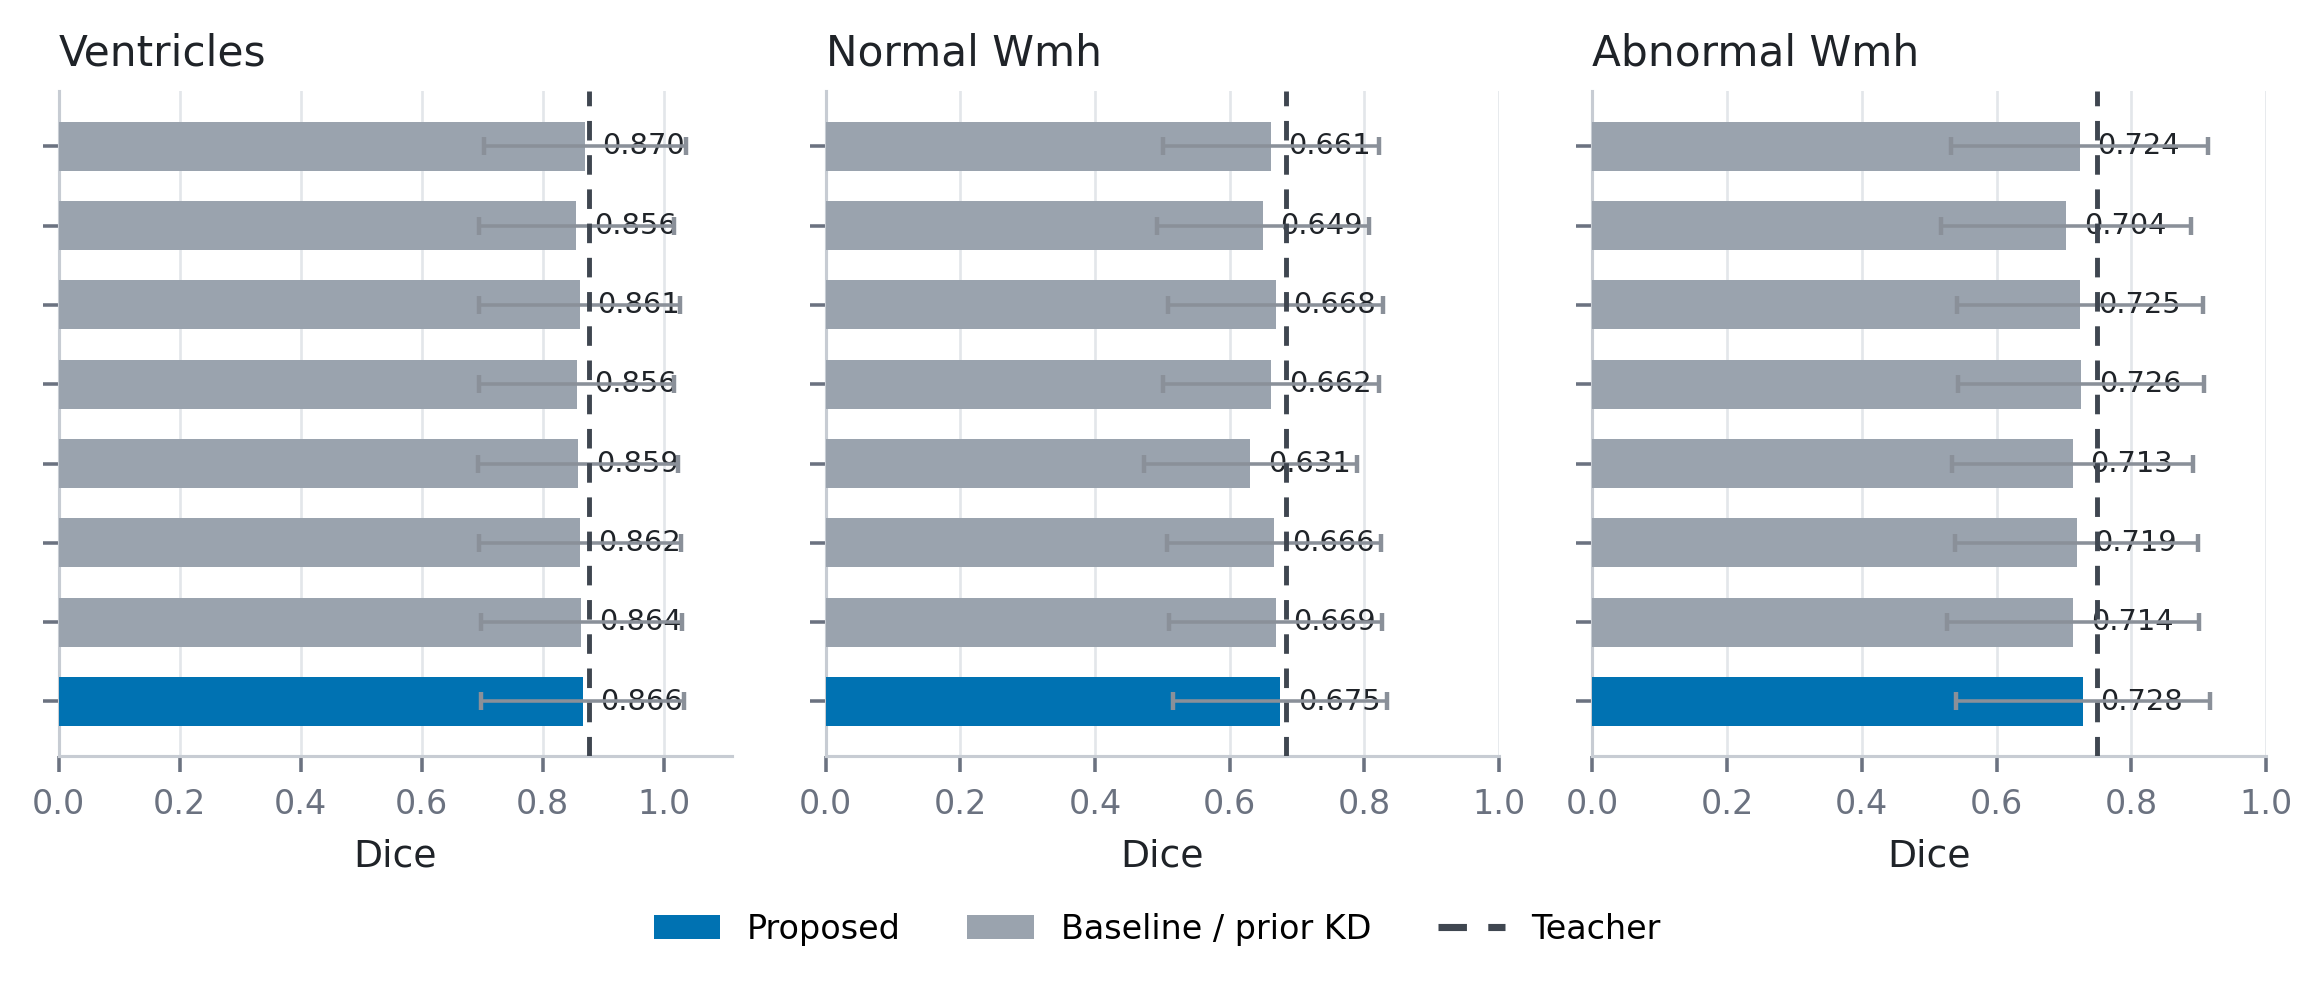

wrote /kaggle/working/msdistill_out/figures/fig_paired_delta.png


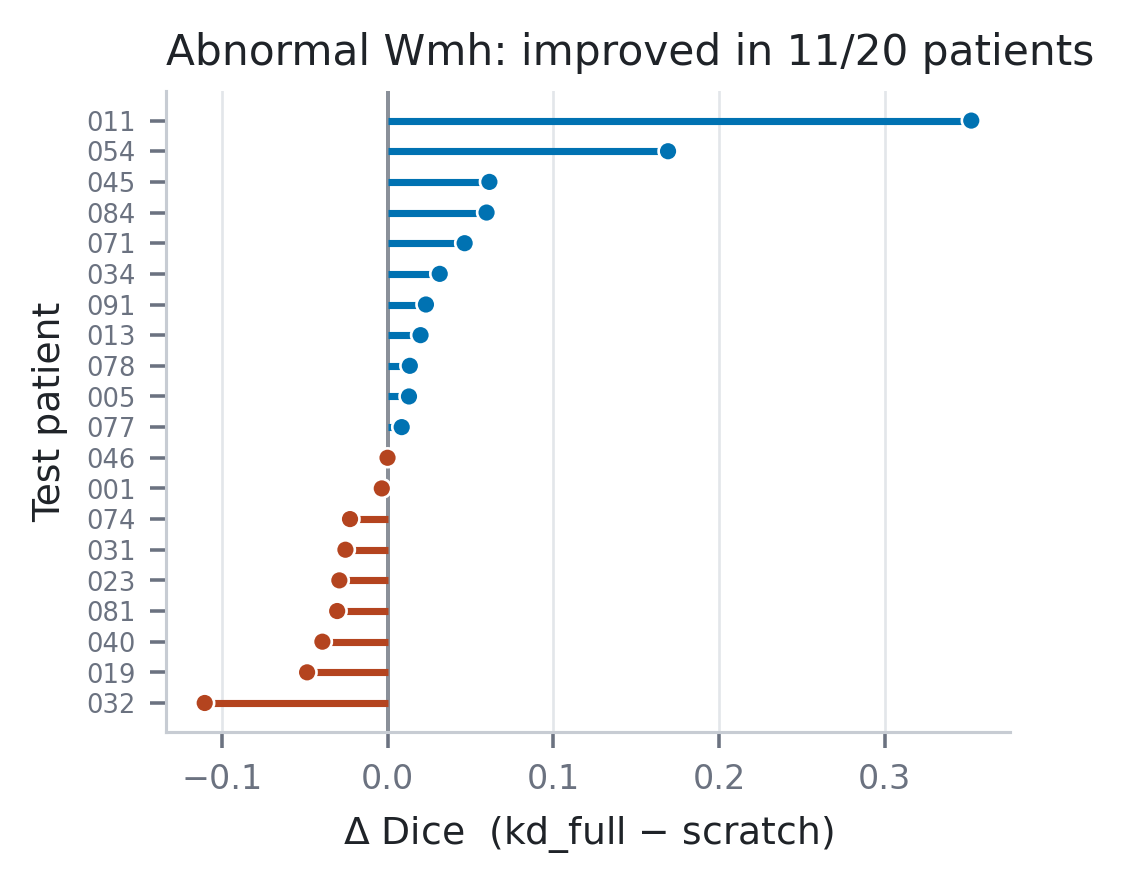

wrote /kaggle/working/msdistill_out/figures/fig_accuracy_vs_cost.png


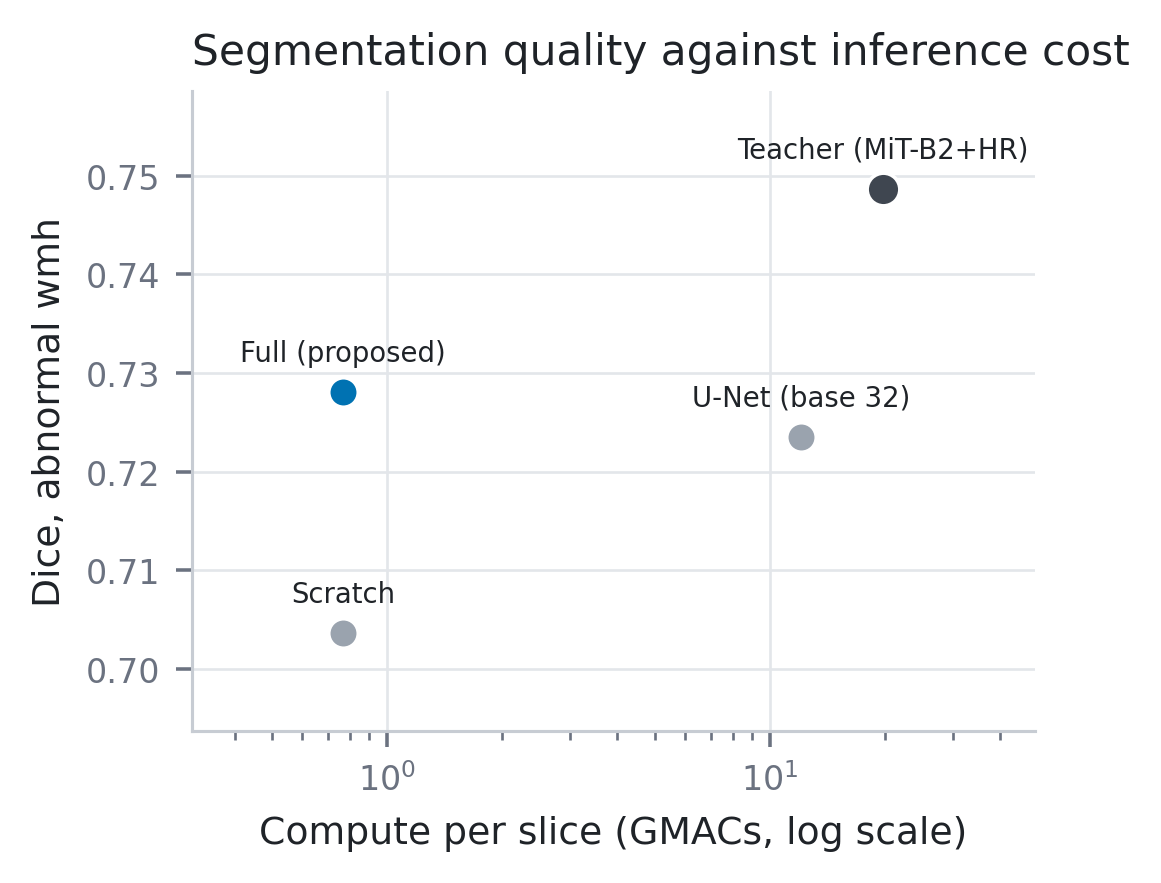

wrote /kaggle/working/msdistill_out/figures/fig_qualitative.png


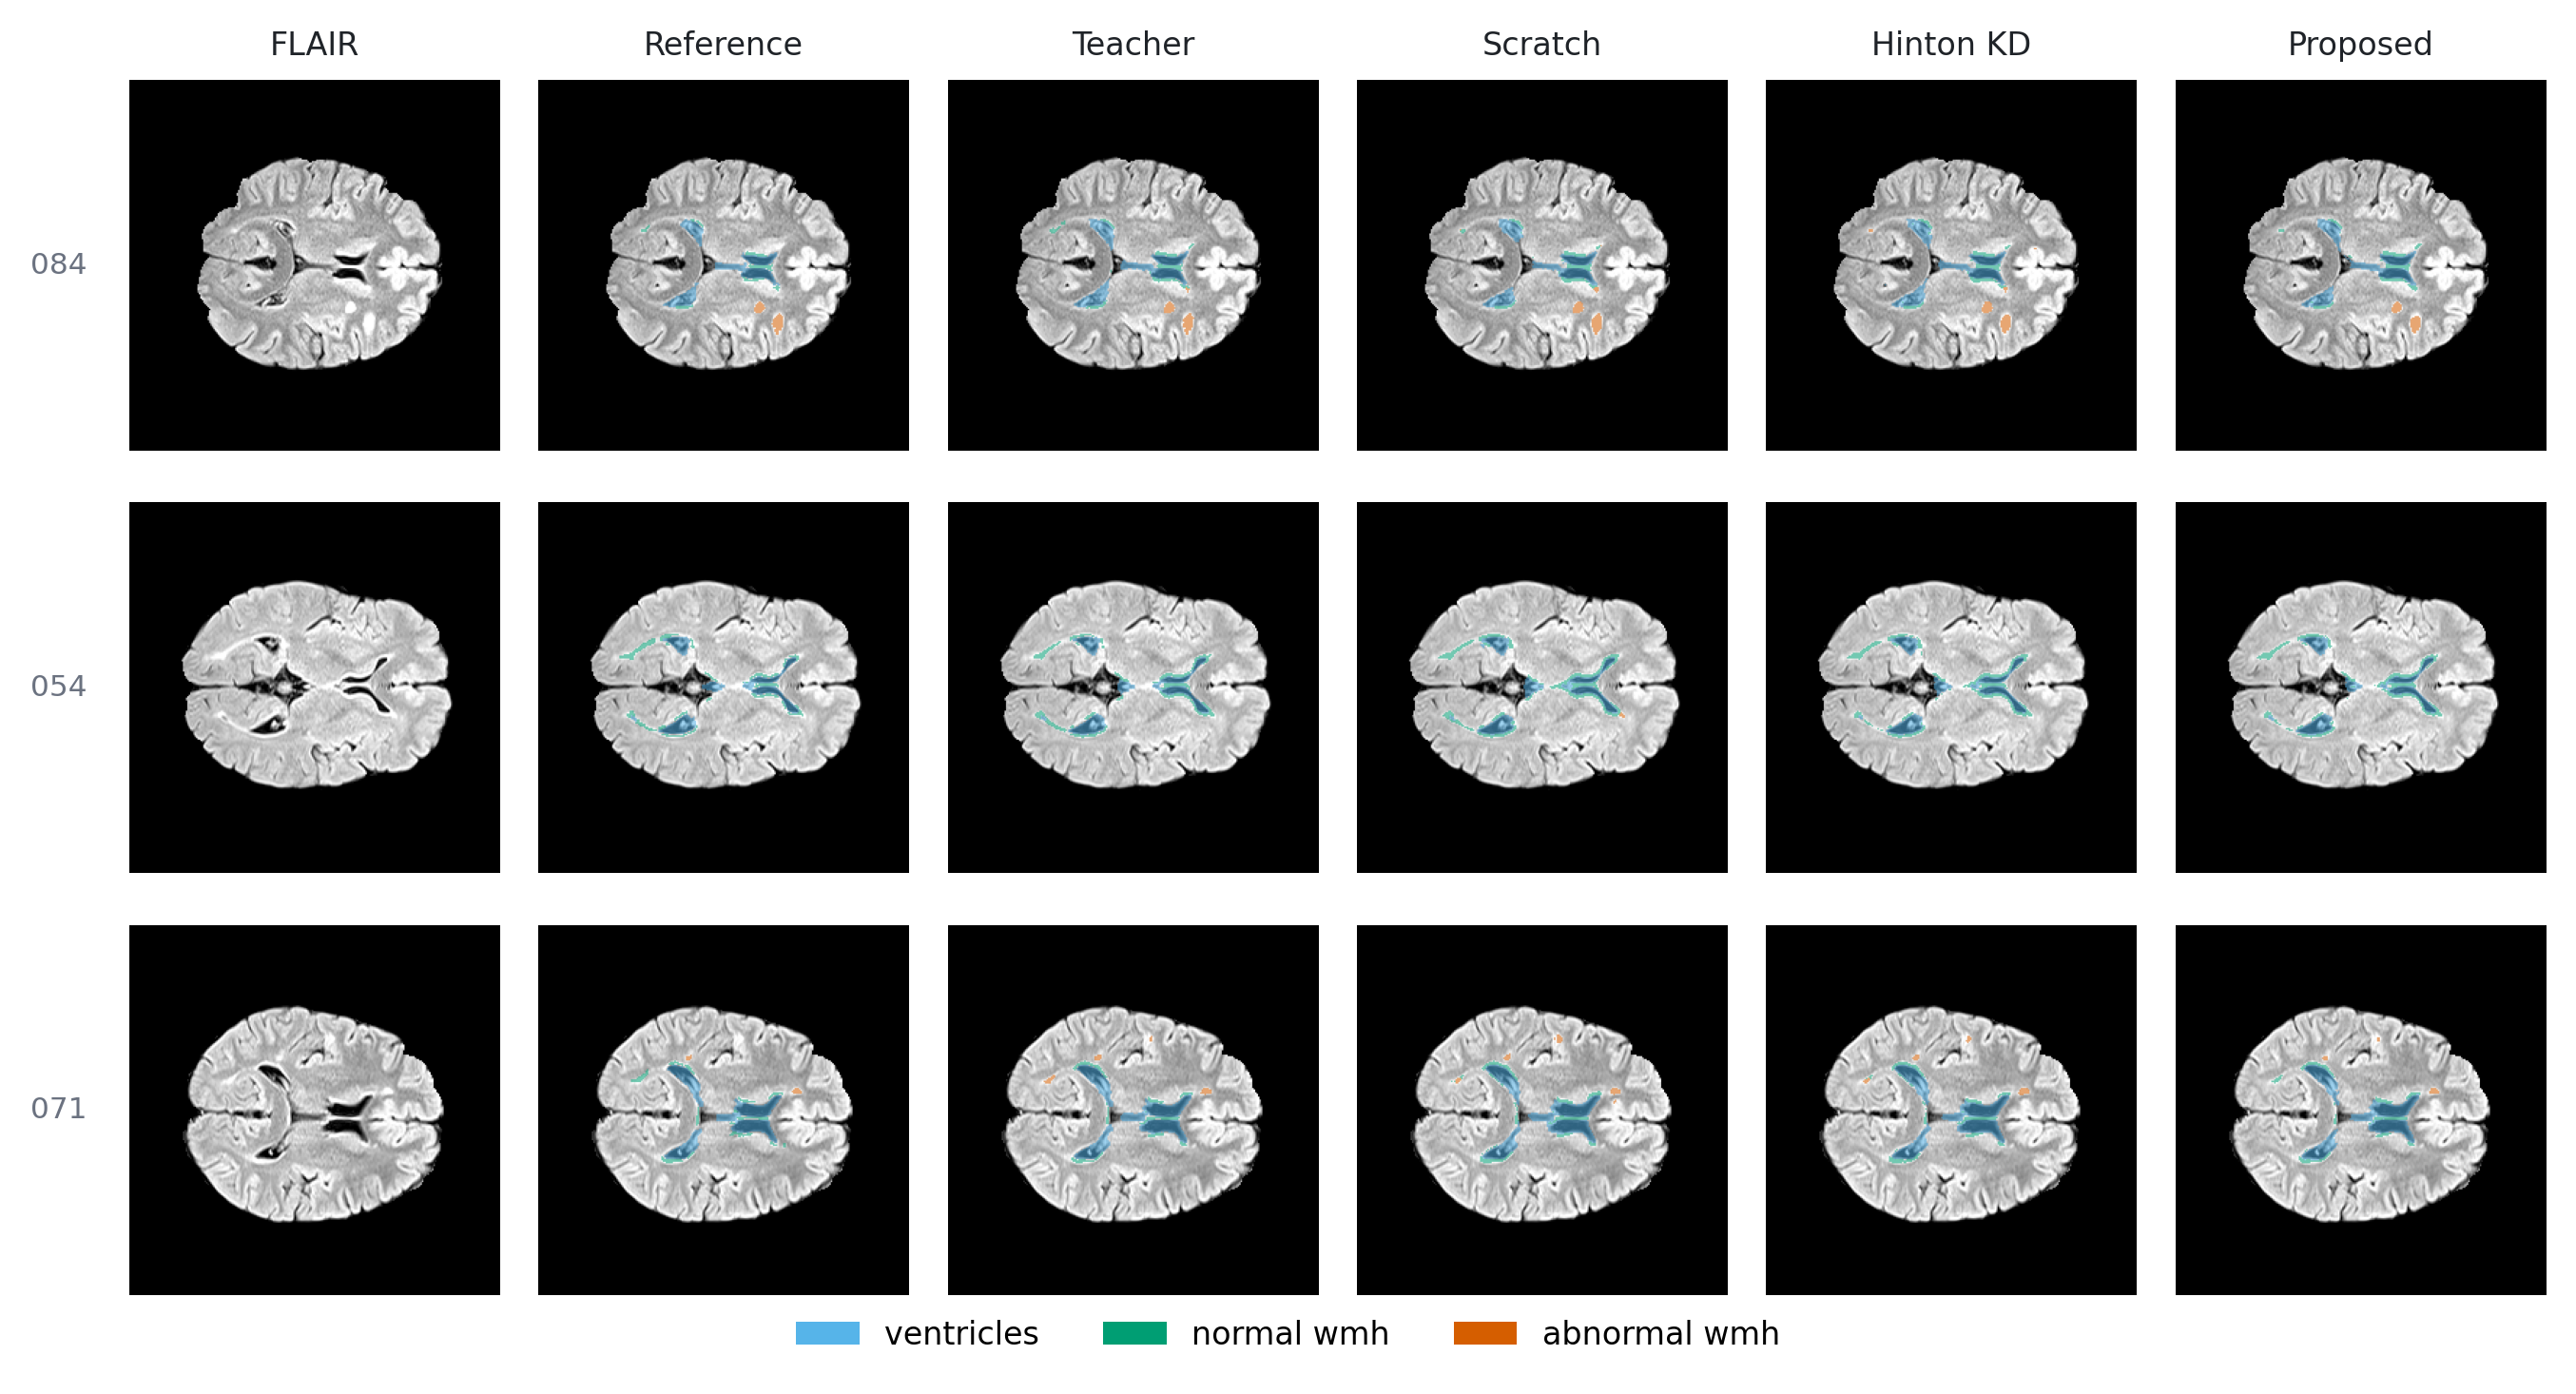

In [29]:
cost_by_key = {"teacher": efficiency_reports[0], "unet32": efficiency_reports[1]}
for v in variants:
    if v.key != "unet32":
        cost_by_key[v.key] = efficiency_reports[-1]   # every student shares one architecture

figures = [
    plot_ablation_bars(evaluations, ordered_keys, cfg,
                       os.path.join(cfg.figures_dir, "fig_ablation.png")),
    plot_paired_differences(evaluations, "kd_full", "scratch", primary_class,
                            os.path.join(cfg.figures_dir, "fig_paired_delta.png")),
    plot_accuracy_vs_cost(
        {k: evaluations[k] for k in ("teacher", "unet32", "scratch", "kd_full")
         if k in evaluations},
        cost_by_key, cfg,
        os.path.join(cfg.figures_dir, "fig_accuracy_vs_cost.png")),
    plot_qualitative(
        cache, predictions, qualitative_patients,
        [cache.n_slices(p) // 2 for p in qualitative_patients],
        [("teacher", "Teacher"), ("scratch", "Scratch"),
         ("kd_vanilla", "Hinton KD"), ("kd_full", "Proposed")],
        cfg, os.path.join(cfg.figures_dir, "fig_qualitative.png")),
]

for path in figures:
    print("wrote", path)
    display(__import__("IPython").display.Image(filename=path))

## Zip everything

In [31]:
!zip -r Run.zip /kaggle/working/msdistill_out

  adding: kaggle/working/msdistill_out/ (stored 0%)
  adding: kaggle/working/msdistill_out/results/ (stored 0%)
  adding: kaggle/working/msdistill_out/results/teacher_cv.json (deflated 77%)
  adding: kaggle/working/msdistill_out/results/RESULTS.md (deflated 58%)
  adding: kaggle/working/msdistill_out/results/kd_full_cv.json (deflated 77%)
  adding: kaggle/working/msdistill_out/results/unet32_cv.json (deflated 77%)
  adding: kaggle/working/msdistill_out/results/kd_fitnets_cv.json (deflated 78%)
  adding: kaggle/working/msdistill_out/results/kd_region_cwd_cv.json (deflated 77%)
  adding: kaggle/working/msdistill_out/results/kd_region_cv.json (deflated 78%)
  adding: kaggle/working/msdistill_out/results/test_evaluations.json (deflated 83%)
  adding: kaggle/working/msdistill_out/results/kd_vanilla_cv.json (deflated 79%)
  adding: kaggle/working/msdistill_out/results/kd_cwd_cv.json (deflated 78%)
  adding: kaggle/working/msdistill_out/results/config.json (deflated 64%)
  adding: kaggle/work

## 10. Seed variance (optional)

A difference smaller than the seed-to-seed spread is not a finding. The student
is cheap enough to repeat, so the headline comparison is checked against
independent initializations. Skip this cell if the GPU budget is exhausted — the
main results do not depend on it, but the paper is stronger with it.


In [ ]:
RUN_SEED_STUDY = True   # set False to skip

per_seed = {}
if RUN_SEED_STUDY and len(cfg.student_seeds) > 1:
    seed_variants = select_variants(list(SEED_STUDY_KEYS))
    for seed in cfg.student_seeds:
        if seed == cfg.seed:
            results_for_seed = {v.key: student_results[v.key] for v in seed_variants}
        else:
            results_for_seed = run_student_stage(cfg, seed_variants, fold_splits, cache,
                                                 teachers_by_fold, DEVICE, seed=seed)
        for v in seed_variants:
            models = load_ensemble(student_builder(v.base_channels),
                                   [r["checkpoint"] for r in results_for_seed[v.key]],
                                   DEVICE, cfg)
            ev = evaluate_ensemble(models, cache, test_patients, cfg, DEVICE,
                                   f"{v.key}_s{seed}", v.label, count_parameters(models[0]),
                                   compute_boundary=False)
            per_seed.setdefault(v.key, {})[seed] = ev.dice(primary_class)

    write_table(seed_variance_table(per_seed, cfg),
                os.path.join(cfg.tables_dir, "table_seeds.tex"))

    spreads = []
    for key, values in per_seed.items():
        vals = [v for v in values.values() if not np.isnan(v)]
        sd = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
        spreads.append(sd)
        print(f"{key:<12} " + "  ".join(f"seed{s}={v:.3f}" for s, v in values.items())
              + f"   sd={sd:.4f}")

    # This number is the interpretability floor for the whole results section:
    # a difference between objectives smaller than the spread across seeds of a
    # single objective is not evidence of anything.
    floor = max(spreads) if spreads else 0.0
    gain = (evaluations["kd_full"].dice(primary_class)
            - evaluations["scratch"].dice(primary_class))
    print(f"\nseed-to-seed spread (worst variant): {floor:.4f} Dice")
    print(f"proposed-minus-baseline gain on {primary_class}: {gain:+.4f} Dice")
    print("-> " + ("gain exceeds the seed floor; interpret it"
                   if abs(gain) > floor else
                   "gain is WITHIN the seed floor; report it as not interpretable"))

  eval scratch_s42:   0%|          | 0/20 [00:00<?, ?it/s]

  eval kd_vanilla_s42:   0%|          | 0/20 [00:00<?, ?it/s]

  eval kd_full_s42:   0%|          | 0/20 [00:00<?, ?it/s]

  resuming fold 0 from epoch 20

=== Students | fold 0 | seed 1337 | 3 variants | train=53 val=27 ===
    scratch, kd_vanilla, kd_full


students f0:   0%|          | 0/40 [00:00<?, ?ep/s]

...

  train:   0%|          | 0/294 [00:00<?, ?it/s]

  train:   0%|          | 0/294 [00:00<?, ?it/s]

  train:   0%|          | 0/294 [00:00<?, ?it/s]

  train:   0%|          | 0/294 [00:00<?, ?it/s]

  train:   0%|          | 0/294 [00:00<?, ?it/s]

---

## 11. What to copy into the paper

| Artefact | Destination |
|---|---|
| `tables/results_macros.tex` | `\input` at the top of `main.tex`; every number in the prose is a macro from here |
| `tables/table_*.tex` | `\input` at each table position |
| `figures/fig_*.png` | `paper/figures/` |
| `results/RESULTS.md` | the repository README |
| `results/test_evaluations.json` | archived per-patient scores, for reproducibility |

### Reading the outcome honestly

Three results are possible and the paper has a defensible framing for each.

**The distilled student beats the scratch student significantly.** The headline
claim holds; report the ladder to show which component earned it.

**Only some components help.** Report that. An ablation whose rows are all
positive is less credible than one that identifies a component contributing
nothing — and the negative row is itself a finding about dense-prediction
distillation under extreme class imbalance.

**The student matches or beats the teacher.** This is common with small cohorts
and a high-capacity teacher, and it does not invalidate the work: the efficiency
result stands on its own, and the finding becomes "at this data scale, teacher
capacity is not the binding constraint" — which is worth reporting, provided the
paper says so plainly rather than burying it.
